# Lección 9.1 · Verosimilitud de genotipos: de una columna de bases a un genotipo con confianza

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/juvenalyosa/bioinformatica-practica/blob/main/modulo-09-variantes/9.1_verosimilitud_genotipos.ipynb) [![Copiloto: Claude](https://img.shields.io/badge/Copiloto-Claude-D97757?logo=claude&logoColor=white)](https://claude.ai) [![Licencia: MIT](https://img.shields.io/badge/Licencia-MIT-2a78d6.svg)](https://github.com/juvenalyosa/bioinformatica-practica/blob/main/LICENSE)

**Módulo 9 — Detección de variantes** · Bioinformática Práctica (Maestría)

👤 **Juvenal Yosa, PhD** · ✉️ [juvenal.yosa@gmail.com](mailto:juvenal.yosa@gmail.com) · 🤖 Copiloto: **Claude** (Anthropic)

| ⏱️ Duración | 📶 Nivel | 🧰 Requisitos |
|---|---|---|
| ~4 horas | Intermedio–avanzado | Lecciones 6.2 (calidades Phred), 7.2–7.3 (alineamiento, MAPQ, pileup) y 4.3 (EM/HMM); probabilidad básica |

---

## 🎯 Objetivos de aprendizaje

Al terminar esta clase usted podrá:

1. **Distinguir** los tipos de variación genética (SNV, MNV, *indels*, variantes estructurales y CNV) y decir cuáles
   se ven en una **columna de bases** (*pileup*) y cuáles no.
2. **Derivar**, desde la calidad Phred, la probabilidad de observar una base dado el alelo verdadero y dado un
   genotipo diploide $G=\{a_1,a_2\}$, y con ella la **verosimilitud** $L(G)=P(D\mid G)$ de una columna.
3. **Convertir** verosimilitudes en el vector **PL** de un VCF y **reconocer** la forma general de Li (2011) para
   cualquier ploidía $m$, incluida la **haploide** ($m=1$) de una bacteria.
4. **Construir** la distribución *a priori* a partir de la heterocigosidad $\theta$, **calcular** la posterior con el
   teorema de Bayes y, a partir de ella, **QUAL** y **GQ**, sabiendo por qué dos convenciones de GQ dan números distintos.
5. **Cuantificar** cuánta profundidad hace falta para genotipar un heterocigoto y **explicar** por qué la
   distribución *a priori* domina a baja cobertura.
6. **Explicar** la calidad de alineamiento de la base (**BAQ**) y cómo propaga la incertidumbre del alineamiento.
7. **Implementar** la **llamada conjunta** de varias muestras con el algoritmo **EM** para la frecuencia alélica $\psi$.
8. **Aplicar** el modelo a columnas **reales** del clon del experimento de evolución a largo plazo de Lenski (LTEE),
   separando mutaciones verdaderas de un racimo de falsas SNV sobre genes repetidos, y **situar** a GATK
   HaplotypeCaller y DeepVariant respecto de este modelo.

## 🗺️ Mapa de la clase

1. ¿Qué es una variante?
2. La columna de bases: el *pileup* (la columna 8, nuestro ejemplo de toda la clase)
3. El modelo de error de una base
4. La verosimilitud de un genotipo (ejemplo resuelto de la columna 8) y la forma de Li para cualquier ploidía
5. De verosimilitudes a PL
6. La distribución *a priori* y la heterocigosidad $\theta$
7. La posterior, QUAL y GQ (🎛️ explorador interactivo de una columna, 🎛️ mapa de decisiones)
8. Un caso clínico: el genotipo de un paciente, lectura a lectura (🎬 animación)
9. BAQ: cuando el error no es de la base sino del alineamiento
10. Llamada conjunta de varias muestras con EM (🎬 animación)
11. Datos reales: columnas haploides del clon del LTEE (🎛️ interactivo)
12. Más allá de la columna: HaplotypeCaller y DeepVariant
13. Ejercicios, resumen y lecturas

> 📖 **Compañero del libro.** Esta lección acompaña la sección «Verosimilitud de genotipos» del capítulo 9 del libro
> *Bioinformática Práctica*. Usamos exactamente sus símbolos ($D$, $G$, $L(G)$, $\varepsilon$, $\theta$, $\psi$, PL,
> QUAL, GQ) y reproducimos con código sus ejemplos resueltos, cifra por cifra; pero el notebook se puede seguir sin
> el libro.

In [1]:
# ⚙️ Configuración del entorno (ejecute esta celda primero)
# Bioinformática Práctica · Juvenal Yosa, PhD · Copiloto: Claude
import os, sys, urllib.request

try:
    import google.colab  # noqa: F401
    IN_COLAB = True
except ImportError:
    IN_COLAB = False

# Descarga el estilo gráfico del curso (en Colab) o lo toma del repositorio (local)
STYLE_URL = "https://raw.githubusercontent.com/juvenalyosa/bioinformatica-practica/main/utils/estilo_curso.py"
if os.path.exists("../utils/estilo_curso.py"):
    sys.path.insert(0, "../utils")
elif not os.path.exists("estilo_curso.py"):
    urllib.request.urlretrieve(STYLE_URL, "estilo_curso.py")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import estilo_curso as ec

ec.set_style()
print("Entorno listo ✔  |  Colab:", IN_COLAB)

import math, gzip, collections, itertools
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots
from matplotlib.patches import FancyArrow, Rectangle, FancyBboxPatch
from scipy import stats

RAW = "https://raw.githubusercontent.com/juvenalyosa/bioinformatica-practica/main"

def course_file(name):
    """Devuelve la ruta local de un archivo del curso: 1) copia en ../data; 2) descarga desde el repositorio
    en GitHub (se guarda en el directorio actual)."""
    local = os.path.join("..", "data", name)
    if os.path.exists(local):
        return local
    if not os.path.exists(name):
        try:
            urllib.request.urlretrieve(f"{RAW}/data/{name}", name)
        except Exception as err:
            raise RuntimeError(f"No se pudo obtener {name}: {err}")
    return name

# pysam: la interfaz de Python a htslib/samtools (en Colab se instala con pip)
try:
    import pysam
except ImportError:
    if IN_COLAB:
        %pip install -q pysam
    try:
        import pysam
    except ImportError:
        pysam = None
print("pysam:", pysam.__version__ if pysam else "no disponible (usaremos la tabla precalculada del curso)")

GENO_COLORS = {"RR": ec.ORANGE, "RA": ec.BLUE, "AA": ec.VIOLET}   # los mismos colores que el libro

Entorno listo ✔  |  Colab: False


pysam: 0.24.1


## 1. ¿Qué es una variante?

Piense en dos ejemplares impresos de la misma novela. Si los compara línea por línea encontrará, de vez en cuando,
una letra cambiada, una palabra de más o de menos y, muy rara vez, un párrafo entero repetido o cambiado de lugar.
Nadie diría que uno de los dos ejemplares es "el correcto": simplemente uno de ellos se usa como **patrón** para
describir las diferencias del otro.

Con los genomas pasa lo mismo. Una **variante** es cualquier diferencia entre la secuencia de un individuo y una
**secuencia de referencia**. La referencia no es un genoma "normal" ni "sano": es un **sistema de coordenadas
acordado**. Decir que un paciente porta el alelo de referencia en una posición sólo significa que coincide con esa
convención. Las variantes se clasifican por su **tamaño**, porque cada escala deja una huella distinta en los datos:

| Tipo | Qué es | Dónde se ve |
|---|---|---|
| **SNV** (*single nucleotide variant*) | una base cambiada por otra (SNP si es frecuente en la población) | en la columna de bases |
| **MNV** (*multi-nucleotide variant*) | varias sustituciones contiguas en el mismo haplotipo (pueden caer en el mismo codón) | en varias columnas vecinas, en las mismas lecturas |
| ***Indel*** | inserción o deleción de 1 a unas decenas de bases | en la columna, si el alineador abrió un hueco |
| **SV** (variante estructural) | reordenamientos de más de ~50 pb: deleciones, inserciones, inversiones, translocaciones | en la *geometría* de los alineamientos: profundidad, pares y lecturas partidas |
| **CNV** (*copy number variant*) | segmento presente en un número de copias distinto de dos | sobre todo en la profundidad de cobertura |

Las cifras dan la escala del problema en humanos: un genoma típico difiere de la referencia en **4.1 a 5.0
millones** de sitios, y el Proyecto 1000 Genomas catalogó **84.7 millones de SNP** frente a **3.6 millones de
*indels*** cortos; en cambio, cada genoma lleva sólo **2 100–2 500 variantes estructurales**, que sin embargo abarcan
unos **20 millones de bases** (Auton et al., 2015). Esta lección trata las variantes **pequeñas** (SNV e *indels*),
que son las que resuelven los llamadores basados en columnas de lecturas.

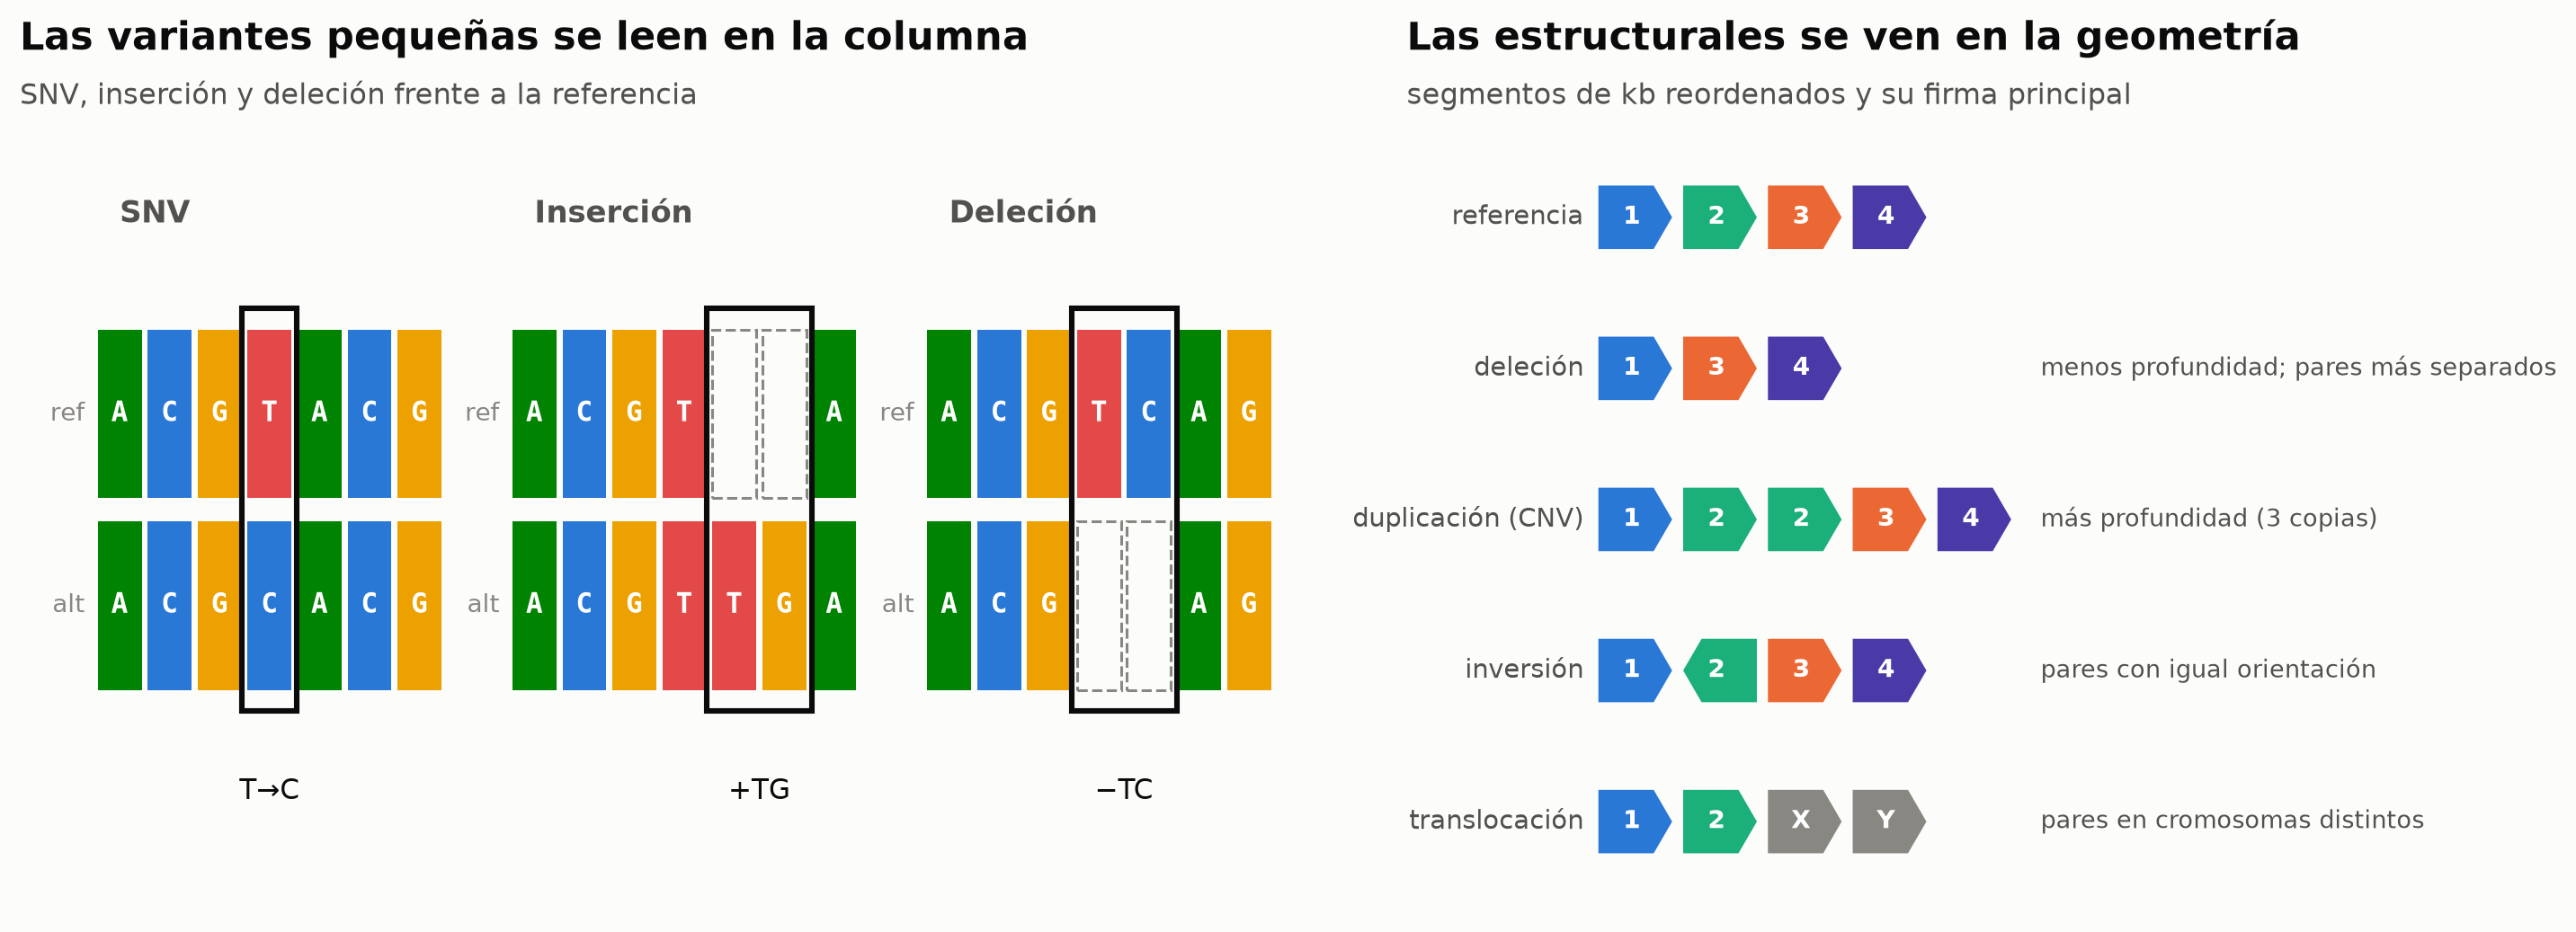

In [2]:
def draw_base(ax, x, y, b, alpha=1.0, size=0.44):
    """Dibuja una base como un cuadrado coloreado con su letra (convención de colores del curso)."""
    if b == "-":
        ax.add_patch(Rectangle((x - size, y - size), 2 * size, 2 * size, fill=False, ec=ec.MUTED, ls="--", lw=1))
        return
    ax.add_patch(Rectangle((x - size, y - size), 2 * size, 2 * size, color=ec.NUC_COLORS[b], alpha=alpha, lw=0))
    ax.text(x, y, b, ha="center", va="center", fontsize=10, fontweight="bold", family="monospace",
            color="white" if alpha > 0.55 else ec.INK)

fig, (axa, axb) = plt.subplots(1, 2, figsize=(13, 4.6), gridspec_kw=dict(width_ratios=[1.25, 1]))
# (a) variantes pequeñas
cases = [("SNV", "ACGTACG", "ACGCACG", (3, 3), "T→C"),
         ("Inserción", "ACGT--A", "ACGTTGA", (4, 5), "+TG"),
         ("Deleción", "ACGTCAG", "ACG--AG", (3, 4), "−TC")]
for c, (name, r, a, (i0, i1), lab) in enumerate(cases):
    x0 = c * 8.3
    axa.text(x0, 3.0, name, fontsize=11, fontweight="bold", color=ec.INK_2)
    axa.text(x0 - 0.7, 2, "ref", ha="right", va="center", fontsize=9, color=ec.MUTED)
    axa.text(x0 - 0.7, 1, "alt", ha="right", va="center", fontsize=9, color=ec.MUTED)
    for i, (br, ba) in enumerate(zip(r, a)):
        draw_base(axa, x0 + i, 2, br); draw_base(axa, x0 + i, 1, ba)
    axa.add_patch(Rectangle((x0 + i0 - 0.55, 0.45), i1 - i0 + 1.1, 2.1, fill=False, ec=ec.INK, lw=2))
    axa.text(x0 + (i0 + i1) / 2, 0.1, lab, ha="center", va="top", fontsize=10, color=ec.INK)
axa.set_xlim(-2, 24); axa.set_ylim(-0.6, 3.5); axa.axis("off")
ec.title(axa, "Las variantes pequeñas se leen en la columna", "SNV, inserción y deleción frente a la referencia")
# (b) variantes estructurales
rows = [("referencia", [1, 2, 3, 4], ""), ("deleción", [1, 3, 4], "menos profundidad; pares más separados"),
        ("duplicación (CNV)", [1, 2, 2, 3, 4], "más profundidad (3 copias)"),
        ("inversión", [1, -2, 3, 4], "pares con igual orientación"),
        ("translocación", [1, 2, "X", "Y"], "pares en cromosomas distintos")]
seg_col = {1: ec.BLUE, 2: ec.AQUA, 3: ec.ORANGE, 4: ec.VIOLET, "X": ec.MUTED, "Y": ec.MUTED}
for r_i, (name, segs, sig) in enumerate(rows):
    y = -r_i
    axb.text(-0.2, y, name, ha="right", va="center", fontsize=9.5, color=ec.INK_2)
    for s_i, s in enumerate(segs):
        key = abs(s) if isinstance(s, int) else s
        rev = isinstance(s, int) and s < 0
        x = s_i * 1.15
        axb.add_patch(FancyArrow(x + (1.0 if rev else 0), y, (-1.0 if rev else 1.0), 0, width=0.42,
                                 head_width=0.42, head_length=0.25, length_includes_head=True,
                                 color=seg_col[key], lw=0))
        axb.text(x + 0.45, y, str(key), ha="center", va="center", color="white", fontsize=9, fontweight="bold")
    axb.text(6.0, y, sig, ha="left", va="center", fontsize=8.8, color=ec.INK_2)
axb.set_xlim(-2.6, 11.5); axb.set_ylim(-4.6, 0.6); axb.axis("off")
ec.title(axb, "Las estructurales se ven en la geometría", "segmentos de kb reordenados y su firma principal")
plt.show()

> 🔎 **Qué observamos.** Una SNV o un *indel* corto cabe **dentro** de una lectura de 150 pb: basta mirar la columna.
> Una deleción de 5 kb no cabe: ninguna lectura "ve" la deleción entera, pero la profundidad cae, los pares de
> lecturas aparecen más separados de lo esperado y algunas lecturas quedan partidas en dos. Por eso las SV exigen
> herramientas propias (Alkan, Coe y Eichler, 2011), y por eso esta lección se concentra en la columna.

## 2. La columna de bases: el *pileup*

Un juez debe decidir de qué color era el coche que huyó de un accidente. Declaran seis testigos: tres dicen "azul"
y tres dicen "verde". No todos merecen la misma confianza: dos de los que dicen "verde" estaban cerca y a plena luz,
el tercero lo vio de noche y de lejos. El juez sensato **no cuenta votos**: pondera cada testimonio por la
fiabilidad del testigo y se pregunta qué hipótesis explica mejor el **conjunto** de declaraciones. Quizá la mejor
explicación sea sorprendente: que había **dos** coches, uno azul y otro verde. Y antes de oír a nadie ya sabe algo:
en su ciudad los coches azules son mucho más comunes que los verdes.

Ese es, casi palabra por palabra, el problema del llamado de variantes:

* cada **lectura** que cubre una posición es un testigo;
* su **calidad Phred** mide su fiabilidad;
* los "dos coches" son los **dos cromosomas homólogos** de un organismo diploide;
* lo que el juez sabía de antemano es la **distribución *a priori***.

Una vez alineadas las lecturas (Módulo 7), cada posición de la referencia queda cubierta por una **columna** de
bases, cada una con su calidad. Esa columna se llama ***pileup*** (apilamiento) y es el dato bruto del llamado de
variantes; el formato nació con SAMtools y su sucesor `mpileup` sigue siendo el centro de `bcftools`
(Danecek et al., 2021). Dibujemos el *pileup* de juguete que usaremos durante toda la clase: seis lecturas sobre 15
posiciones.

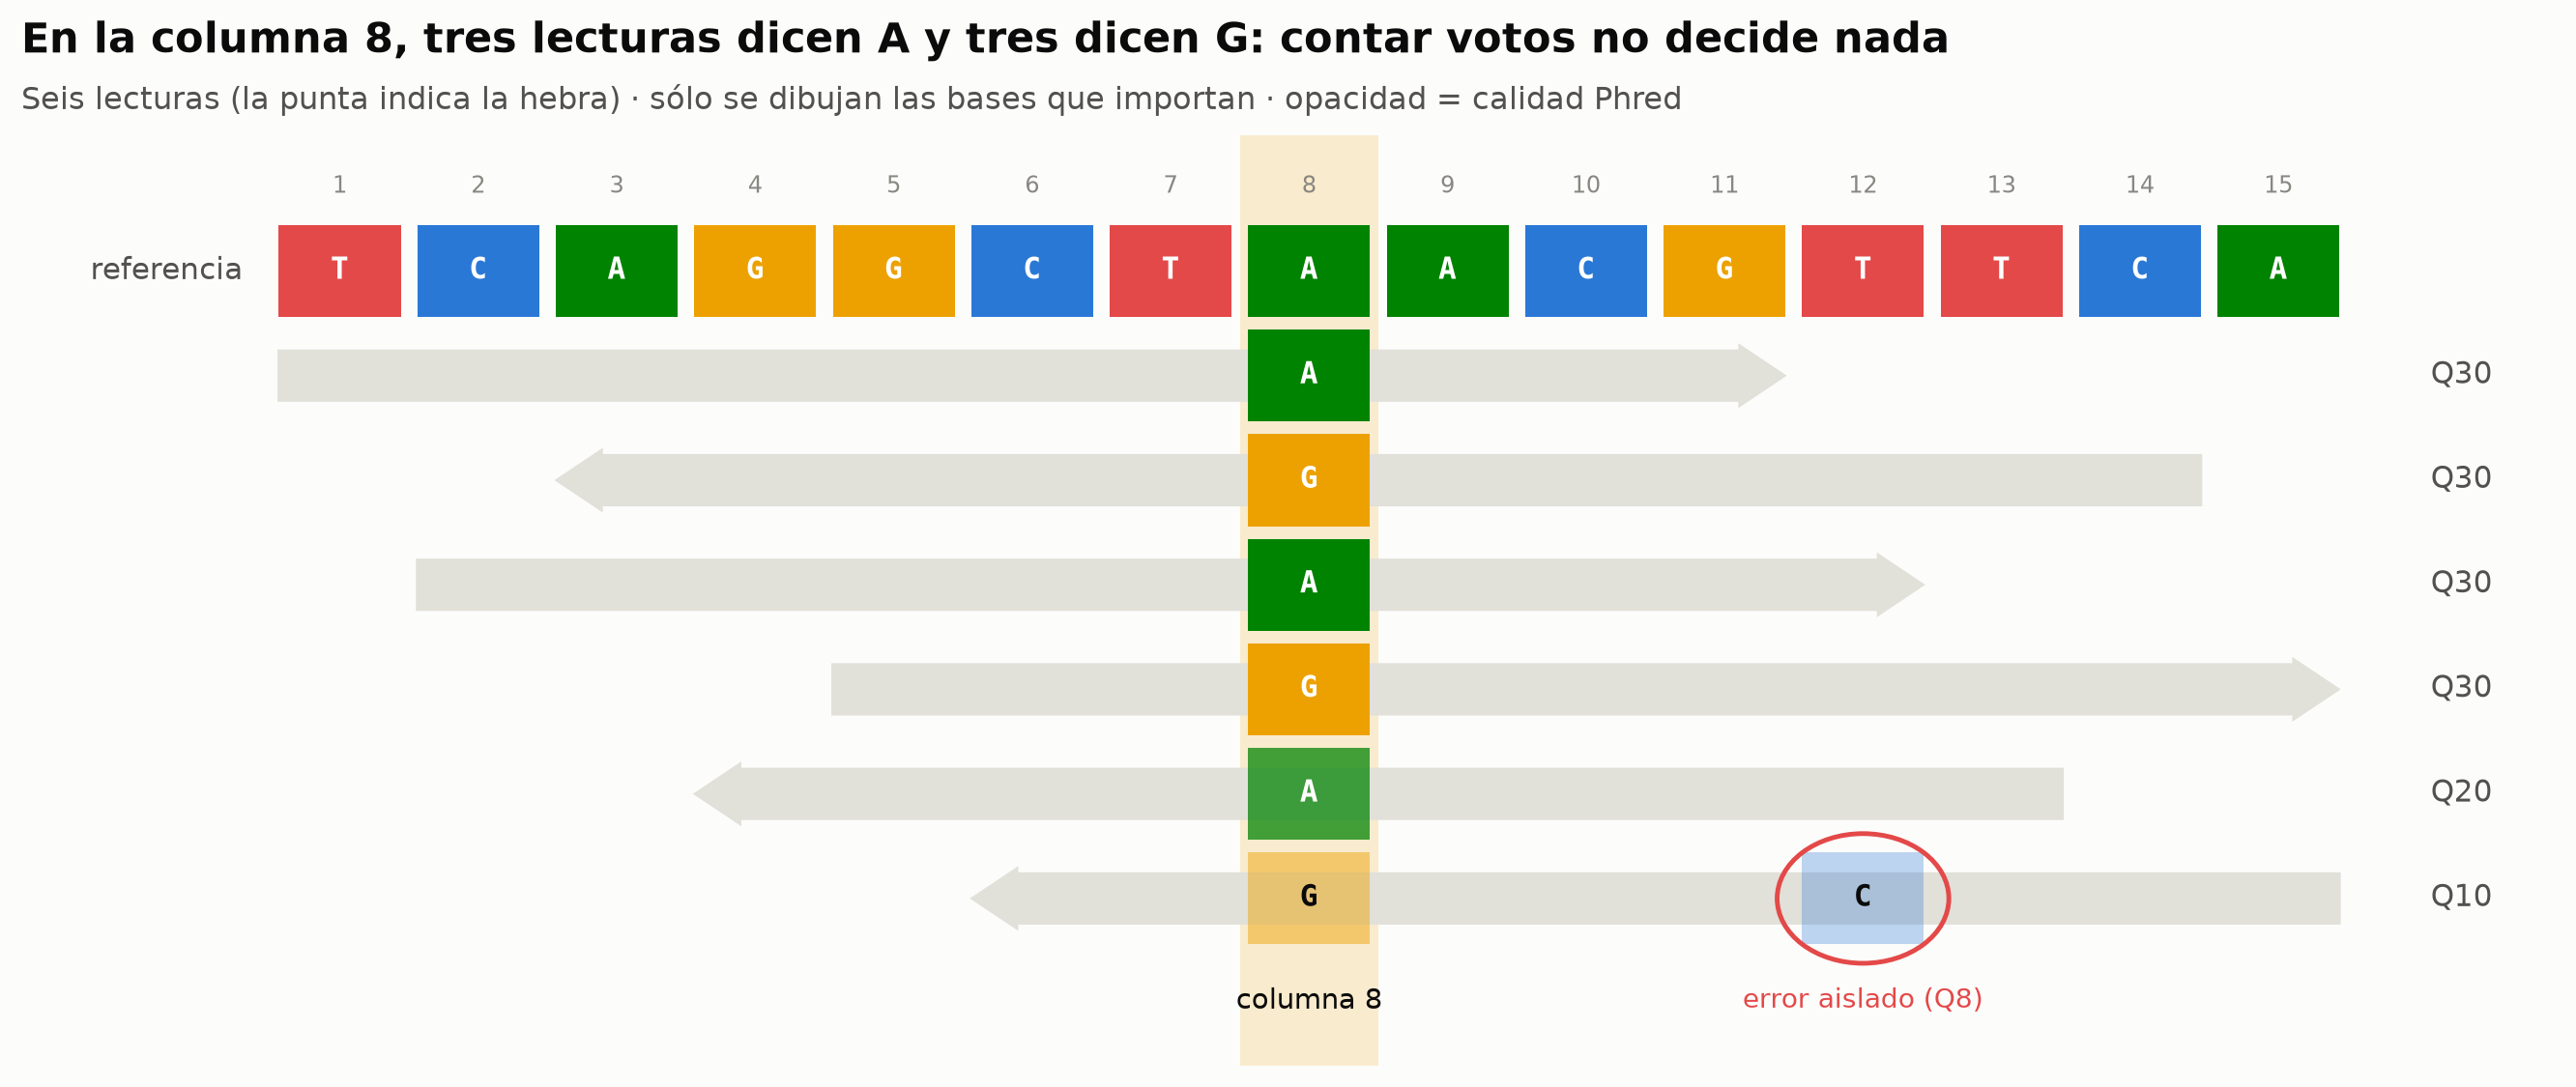

Columna 8 (base, Q): [('A', 30), ('A', 30), ('A', 20), ('G', 30), ('G', 30), ('G', 10)]


In [3]:
D8 = [("A", 30), ("A", 30), ("A", 20), ("G", 30), ("G", 30), ("G", 10)]   # la columna 8 del libro
REF15 = "TCAGGCTAACGTTCA"                  # referencia, posiciones 1..15
# lecturas: (inicio, fin, base en la columna 8, calidad, hebra)
TOY_READS = [(1, 11, "A", 30, "+"), (3, 14, "G", 30, "-"), (2, 12, "A", 30, "+"),
             (5, 15, "G", 30, "+"), (4, 13, "A", 20, "-"), (6, 15, "G", 10, "-")]

fig, ax = plt.subplots(figsize=(12, 5.0))
ax.axvspan(7.5, 8.5, color=ec.YELLOW, alpha=0.18, lw=0)
for i, b in enumerate(REF15, start=1):
    draw_base(ax, i, 0, b)
    ax.text(i, 0.75, str(i), ha="center", fontsize=8, color=ec.MUTED)
ax.text(0.3, 0, "referencia", ha="right", va="center", fontsize=10, color=ec.INK_2)
for y, (s, e, b, q, strand) in enumerate(TOY_READS, start=1):
    ax.add_patch(FancyArrow(s - 0.45 if strand == "+" else e + 0.45, -y, (e - s + 0.9) * (1 if strand == "+" else -1), 0,
                            width=0.5, head_width=0.62, head_length=0.35, length_includes_head=True,
                            color=ec.GRID, lw=0))
    draw_base(ax, 8, -y, b, alpha=0.2 + 0.8 * (q / 30))    # la opacidad codifica la calidad
    ax.text(16.1, -y, f"Q{q}", va="center", fontsize=10, color=ec.INK_2)
draw_base(ax, 12, -6, "C", alpha=0.3)
ax.add_patch(plt.Circle((12, -6), 0.62, fill=False, ec=ec.RED, lw=1.6))
ax.text(12, -6.85, "error aislado (Q8)", ha="center", va="top", fontsize=9, color=ec.RED)
ax.text(8, -6.85, "columna 8", ha="center", va="top", fontsize=9.5, color=ec.INK)
ax.set_xlim(-1.3, 17); ax.set_ylim(-7.6, 1.3); ax.axis("off")
ec.title(ax, "En la columna 8, tres lecturas dicen A y tres dicen G: contar votos no decide nada",
         "Seis lecturas (la punta indica la hebra) · sólo se dibujan las bases que importan · opacidad = calidad Phred")
plt.show()

print("Columna 8 (base, Q):", D8)

> 🔎 **Qué observamos.** La mitad de las lecturas apoya la base de la referencia (`A`) y la otra mitad una base
> alternativa (`G`). ¿Es el individuo heterocigoto `A/G`? ¿Podría ser homocigoto `A/A` y las tres `G` errores de
> secuenciación? ¿Y qué hacemos con la `G` de calidad 10, que tiene un 10 % de probabilidad de ser un error? La `C`
> aislada de la columna 12 es un error típico que un buen modelo debe ignorar. "Tres contra tres" no responde
> nada: **necesitamos un modelo**.

> 🤔 **Antes de seguir, prediga.** Si en vez de tres `G` hubiera **una sola** `G` de Q30 entre veinte `A`, ¿diría
> usted que el individuo es heterocigoto? ¿Y si fueran tres `G` de veinte? Anote sus respuestas; en la sección 7 las
> contrastaremos con la posterior.

## 3. El modelo de error de una base

### La idea en palabras simples

Empecemos por la unidad mínima: **una** base leída. Un secuenciador es como un mecanógrafo muy bueno que, de vez en
cuando, pulsa la tecla equivocada; la calidad Phred $Q$ es su propia estimación de cuánto se equivocó en esa letra.
Recuerde de la Lección 6.2 que

$$
\varepsilon = 10^{-Q/10}: \qquad Q10 \to \varepsilon = 0.1,\quad Q20 \to 0.01,\quad Q30 \to 0.001 .
$$

Si la base verdadera de la molécula es $a$, la máquina lee $a$ con probabilidad $1-\varepsilon$; si se equivoca,
lee alguna de las otras tres bases. El supuesto más simple es que las tres son igual de probables:

$$
P(b \mid a) =
\begin{cases}
1-\varepsilon & \text{si } b = a,\\[2pt]
\varepsilon/3 & \text{si } b \neq a,
\end{cases}
\qquad \varepsilon = 10^{-Q/10}. \tag{09-pbase}
$$

| Símbolo | Significado |
|---|---|
| $b$ | base observada en la lectura (`A`, `C`, `G` o `T`) |
| $a$ | base verdadera en el cromosoma del que proviene la lectura |
| $Q,\ \varepsilon$ | calidad Phred de la base y su probabilidad de error |

**Ejemplo a mano.** Una `G` con Q30 ($\varepsilon=0.001$): si la base verdadera es `G`, $P = 0.999$; si es `A`,
$P = 0.001/3 = 0.00033$. Leer `G` cuando hay una `A` es unas **3 000 veces** menos probable que leerla cuando hay una `G`.

### Dos cromosomas: la ley de la probabilidad total

En un diploide, la lectura pudo provenir de **cualquiera de los dos** cromosomas homólogos. Un **genotipo** es el par
no ordenado de alelos $G=\{a_1,a_2\}$; para un sitio bialélico con alelo de referencia $R$ y alternativo $A$ hay tres:
$RR$ (homocigoto de referencia, `0/0` en VCF), $RA$ (heterocigoto, `0/1`) y $AA$ (homocigoto alternativo, `1/1`).
Si la biblioteca muestrea ambos cromosomas por igual,

$$
P(b \mid G=\{a_1,a_2\}) = \tfrac12\,P(b\mid a_1) + \tfrac12\,P(b\mid a_2). \tag{09-pbaseG}
$$

| Símbolo | Significado |
|---|---|
| $G$ | genotipo diploide candidato |
| $a_1,\ a_2$ | alelos de los dos cromosomas homólogos |
| $\tfrac12$ | probabilidad de que la lectura provenga de cada cromosoma (muestreo equilibrado) |

Para un homocigoto ($a_1=a_2$) la ecuación se reduce a la 09-pbase. Para un heterocigoto $\{R,A\}$, una base que
coincida con cualquiera de los dos alelos tiene probabilidad
$\tfrac12(1-\varepsilon)+\tfrac12\,\varepsilon/3 = \tfrac12 - \varepsilon/3 \approx \tfrac12$:
**en un heterocigoto, ver $R$ o ver $A$ es lanzar una moneda, y la calidad casi no importa.** En cambio, para un
homocigoto, ver el alelo "equivocado" cuesta un factor $\varepsilon/3$ (1/3 000 para Q30). Toda la capacidad
discriminatoria del modelo nace de esa **asimetría**.

In [4]:
def p_base(b, a, eps):
    """P(b | a), ecuación 09-pbase: acierto 1−ε; error repartido por igual entre las otras 3 bases."""
    return 1 - eps if b == a else eps / 3

def p_base_geno(b, g, q):
    """P(b | G={a1,a2}), ecuación 09-pbaseG, con ε = 10^(−Q/10)."""
    eps = 10 ** (-q / 10)
    return 0.5 * p_base(b, g[0], eps) + 0.5 * p_base(b, g[1], eps)

R, A = "A", "G"                                   # referencia y alternativo de la columna 8
GENO = {"RR": (R, R), "RA": (R, A), "AA": (A, A)}
for q in (10, 20, 30):
    print(f"Q{q}: ver G →  P|RR = {p_base_geno('G', GENO['RR'], q):.5f}   "
          f"P|RA = {p_base_geno('G', GENO['RA'], q):.5f}   P|AA = {p_base_geno('G', GENO['AA'], q):.5f}")

Q10: ver G →  P|RR = 0.03333   P|RA = 0.46667   P|AA = 0.90000
Q20: ver G →  P|RR = 0.00333   P|RA = 0.49667   P|AA = 0.99000
Q30: ver G →  P|RR = 0.00033   P|RA = 0.49967   P|AA = 0.99900


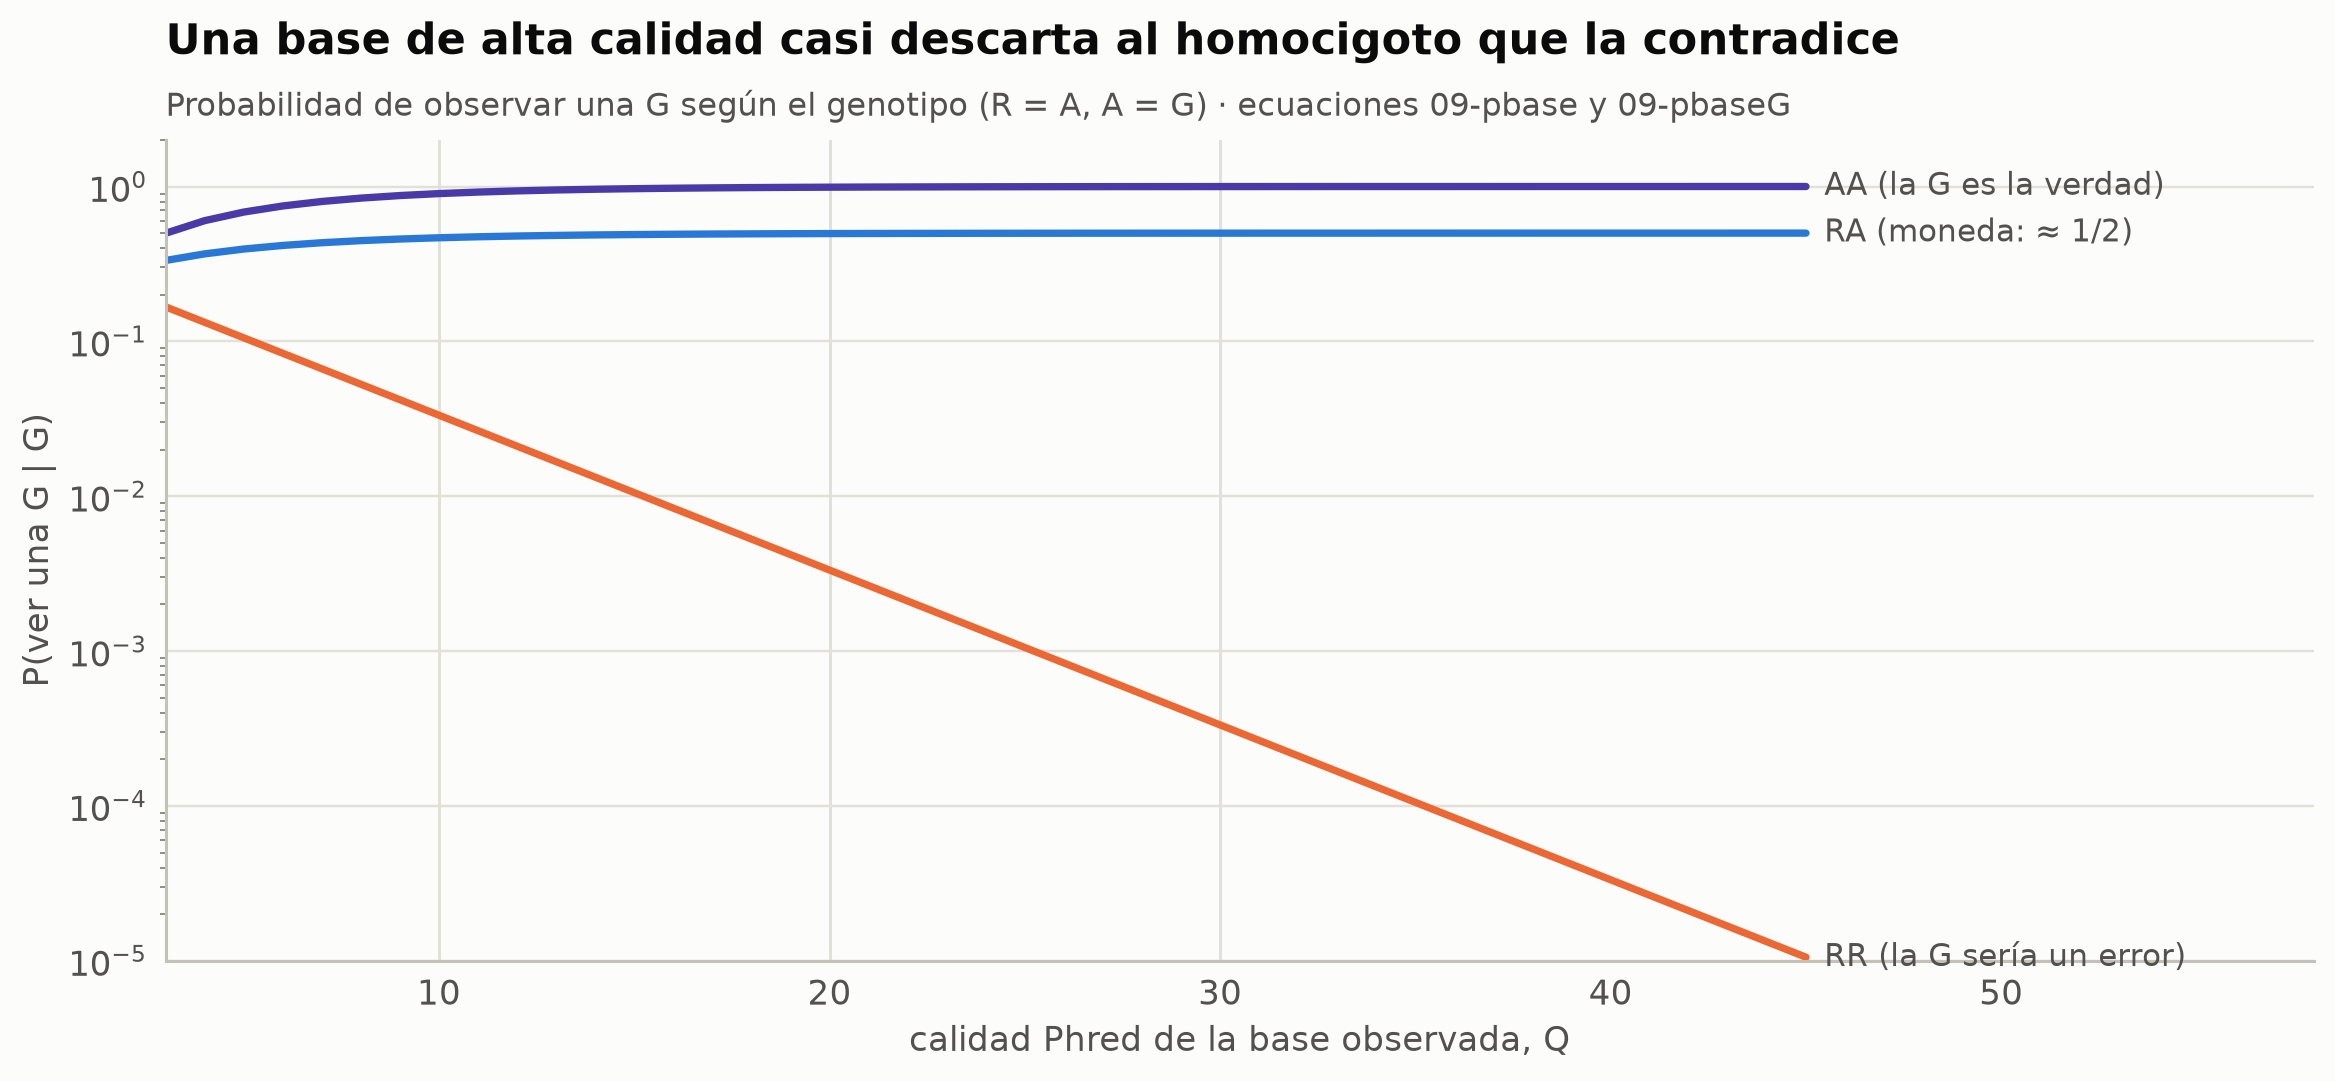

In [5]:
Q = np.arange(3, 46)
fig, ax = plt.subplots(figsize=(10.5, 4.8))
for g, lab in (("RR", "RR (la G sería un error)"), ("RA", "RA (moneda: ≈ 1/2)"), ("AA", "AA (la G es la verdad)")):
    y = [p_base_geno("G", GENO[g], q) for q in Q]
    ax.plot(Q, y, color=GENO_COLORS[g], lw=2.4)
    ec.label_end(ax, Q[-1], y[-1], lab)
ax.set_yscale("log"); ax.set_xlim(3, 58); ax.set_ylim(1e-5, 2)
ax.set_xlabel("calidad Phred de la base observada, Q"); ax.set_ylabel("P(ver una G | G)")
for q in (10, 20, 30):
    ax.axvline(q, color=ec.GRID, lw=1, zorder=0)
ec.title(ax, "Una base de alta calidad casi descarta al homocigoto que la contradice",
         "Probabilidad de observar una G según el genotipo (R = A, A = G) · ecuaciones 09-pbase y 09-pbaseG")
plt.show()

> 🔎 **Qué observamos.** Las curvas de $RA$ y $AA$ son casi planas: bajo esas hipótesis ver una `G` es lo esperable,
> sea cual sea la calidad. La curva de $RR$ baja una década cada 10 unidades de $Q$: una `G` de Q10 apenas molesta
> a la hipótesis $RR$ (0.033), una de Q40 la hunde (0.000033). **Las bases malas pesan poco, las buenas pesan mucho**,
> como los testigos del juez.

> ✅ **Compruebe su comprensión.** ¿Por qué el modelo reparte $\varepsilon$ entre **tres** bases y no entre una?
> *(Porque un error puede producir cualquiera de las otras tres letras; si las tratamos por igual, cada una recibe
> $\varepsilon/3$. Más adelante veremos una versión estrictamente bialélica que usa $\varepsilon$.)*

## 4. La verosimilitud de un genotipo

### De una base a la columna entera

Una columna contiene $n$ lecturas con bases $D=(b_1,\dots,b_n)$ y calidades $(Q_1,\dots,Q_n)$. Si los errores de
lecturas distintas son **independientes**, y cada lectura proviene de un cromosoma elegido al azar
independientemente de las demás, la probabilidad de toda la columna es el **producto** de las probabilidades
individuales (igual que la probabilidad de sacar tres caras seguidas es $\tfrac12\cdot\tfrac12\cdot\tfrac12$):

$$
L(G) \;=\; P(D \mid G) \;=\; \prod_{i=1}^{n}\Bigl[\tfrac12\,P(b_i\mid a_1) + \tfrac12\,P(b_i\mid a_2)\Bigr],
\qquad \varepsilon_i = 10^{-Q_i/10}. \tag{09-lik}
$$

| Símbolo | Significado |
|---|---|
| $D$ | datos: las $n$ bases de la columna con sus calidades |
| $L(G)$ | verosimilitud del genotipo $G$: probabilidad de observar $D$ **si** $G$ fuera el verdadero |
| $n$ | profundidad de la columna (lecturas que la cubren tras los filtros de calidad) |

Subrayemos lo que la ecuación **no** es: **no es la probabilidad del genotipo**. Es la probabilidad de los datos
bajo cada hipótesis. Compararla entre genotipos dice cuál explica mejor lo observado; para la probabilidad de cada
genotipo hará falta Bayes (sección 7).

### ✍️ Ejemplo resuelto: las verosimilitudes de la columna 8

La columna es `A`(Q30), `A`(Q30), `A`(Q20), `G`(Q30), `G`(Q30), `G`(Q10), con $R=$`A` y $A=$`G`. Cada lectura aporta:

| Lectura | $\varepsilon$ | $P(b\mid RR)$ | $P(b\mid RA)$ | $P(b\mid AA)$ |
|---|---|---|---|---|
| `A`, Q30 (×2) | 0.001 | 0.999 | 0.49967 | 0.00033 |
| `A`, Q20 | 0.01 | 0.990 | 0.49667 | 0.00333 |
| `G`, Q30 (×2) | 0.001 | 0.00033 | 0.49967 | 0.999 |
| `G`, Q10 | 0.1 | 0.03333 | 0.46667 | 0.900 |

Multiplicando las seis filas (las marcadas ×2 cuentan dos veces):

$$
L(RR)=3.66\times10^{-9},\qquad L(RA)=1.44\times10^{-2},\qquad L(AA)=3.33\times10^{-10}.
$$

El heterocigoto explica los datos unos **siete órdenes de magnitud** mejor que cualquiera de los homocigotos.
Comprobémoslo con código.

In [6]:
def lik(reads, g):
    """L(G) = P(D | G), ecuación 09-lik. reads = [(base, Q), ...]; g = (a1, a2)."""
    L = 1.0
    for b, q in reads:
        L *= p_base_geno(b, g, q)
    return L

def log10_lik(reads, g):
    """log10 L(G): la misma cuenta en logaritmos (imprescindible con columnas profundas)."""
    return sum(math.log10(p_base_geno(b, g, q)) for b, q in reads)

rows = []
for b, q in [("A", 30), ("A", 20), ("G", 30), ("G", 10)]:
    rows.append({"lectura": f"{b}, Q{q}", "ε": 10 ** (-q / 10),
                 **{f"P(b|{g})": p_base_geno(b, GENO[g], q) for g in GENO}})
display(pd.DataFrame(rows).style.format({"ε": "{:g}", "P(b|RR)": "{:.5f}", "P(b|RA)": "{:.5f}", "P(b|AA)": "{:.5f}"})
        .hide(axis="index"))

L8 = {g: lik(D8, GENO[g]) for g in GENO}
LL8 = {g: log10_lik(D8, GENO[g]) for g in GENO}
for g in GENO:
    print(f"L({g}) = {L8[g]:.3e}    log10 L = {LL8[g]:.3f}")
assert f"{L8['RR']:.2e}" == "3.66e-09" and f"{L8['RA']:.2e}" == "1.44e-02" and f"{L8['AA']:.2e}" == "3.33e-10"

lectura,ε,P(b|RR),P(b|RA),P(b|AA)
"A, Q30",0.001,0.99900,0.49967,0.00033
"A, Q20",0.01,0.99000,0.49667,0.00333
"G, Q30",0.001,0.00033,0.49967,0.99900
"G, Q10",0.1,0.03333,0.46667,0.90000


L(RR) = 3.659e-09    log10 L = -8.437
L(RA) = 1.445e-02    log10 L = -1.840
L(AA) = 3.327e-10    log10 L = -9.478


> 🔎 **Qué observamos.** Coinciden las tres cifras del libro: $3.66\times10^{-9}$, $1.44\times10^{-2}$ y
> $3.33\times10^{-10}$. Fíjese en la `G` de Q10: bajo $RR$ contribuye con 0.033, un factor pequeño pero no
> catastrófico; si hubiera tenido Q30 habría contribuido con 0.00033. Las bases de baja calidad **pesan menos**.

### La forma de Li para cualquier ploidía (y el puente hacia las bacterias)

Heng Li (2011) escribe el mismo modelo de forma compacta para un sitio bialélico y una **ploidía $m$ cualquiera**
(útil en poliploides, mezclas de ADN, *pools*… y organismos **haploides**). Sea $g\in\{0,\dots,m\}$ el número de
copias del alelo de **referencia** en el genotipo, y ordenemos las lecturas para que las $l$ primeras muestren la
referencia y las $n-l$ restantes el alternativo:

$$
L(g) = \frac{1}{m^{n}}\prod_{j=1}^{l}\Bigl[(m-g)\,\varepsilon_j + g\,(1-\varepsilon_j)\Bigr]
\prod_{j=l+1}^{n}\Bigl[(m-g)(1-\varepsilon_j) + g\,\varepsilon_j\Bigr]. \tag{09-li}
$$

| Símbolo | Significado |
|---|---|
| $m$ | ploidía (2 en diploides, **1 en bacterias** como *E. coli*) |
| $g$ | número de copias del alelo de referencia en el genotipo ($0\le g\le m$) |
| $l$ | número de lecturas que muestran el alelo de referencia |
| $\varepsilon_j$ | probabilidad de error de la base de la lectura $j$ |

Cada corchete es la 09-pbaseG generalizada: la lectura proviene de una de las $m$ copias (factor $1/m$), de las
cuales $g$ llevan la referencia. Hay una diferencia sutil: aquí un error convierte una base en **el otro alelo** con
probabilidad $\varepsilon$ (no $\varepsilon/3$), porque el modelo es estrictamente bialélico. Las dos versiones dan
resultados muy parecidos; lo importante es **no mezclarlas en un mismo cálculo**.

**Con $m=1$ el conjunto de genotipos colapsa a dos:** $g=1$ (la bacteria lleva $R$) o $g=0$ (lleva $A$). Ya no
existe "heterocigoto": una columna mitad `A` y mitad `G` en un clon haploide **no tiene** una explicación biológica
limpia y apunta a un artefacto o a una mezcla de células. Lo aprovecharemos con los datos reales de la sección 11.

In [7]:
def lik_li(eps_ref, eps_alt, g, m):
    """L(g) de Li (2011), ecuación 09-li. eps_ref / eps_alt: probabilidades de error de las lecturas que muestran
    la referencia / el alternativo. g = copias de la REFERENCIA; m = ploidía."""
    n = len(eps_ref) + len(eps_alt)
    L = 1.0 / m ** n
    for e in eps_ref:
        L *= (m - g) * e + g * (1 - e)
    for e in eps_alt:
        L *= (m - g) * (1 - e) + g * e
    return L

eps = lambda qs: [10 ** (-q / 10) for q in qs]
e_ref, e_alt = eps([30, 30, 20]), eps([30, 30, 10])
print("Columna 8 con el modelo bialélico de Li:")
for m in (2, 1):
    Ls = {g: lik_li(e_ref, e_alt, g, m) for g in range(m, -1, -1)}
    names = {2: {2: "RR", 1: "RA", 0: "AA"}, 1: {1: "R", 0: "A"}}[m]
    print(f"  m = {m}: " + "   ".join(f"L({names[g]}) = {v:.3e}" for g, v in Ls.items()))

Columna 8 con el modelo bialélico de Li:
  m = 2: L(RR) = 9.880e-08   L(RA) = 1.562e-02   L(AA) = 8.982e-09
  m = 1: L(R) = 9.880e-08   L(A) = 8.982e-09


> 🔎 **Qué observamos.** Con $m=2$, el modelo bialélico da $L(RA)=1.56\times10^{-2}$ (frente a $1.44\times10^{-2}$ del
> modelo de cuatro bases). Los homocigotos quedan algo más cerca ($9.9\times10^{-8}$ y $9.0\times10^{-9}$, porque aquí
> un error cuesta $\varepsilon$ y no $\varepsilon/3$), pero siguen cinco órdenes de magnitud por debajo: la conclusión
> no cambia. Con $m=1$ sólo quedan dos hipótesis, $R$ y $A$, con **las mismas** verosimilitudes diminutas que los
> homocigotos diploides: **ninguna** explica bien la columna. En un organismo haploide, tres `A` y tres `G` de buena
> calidad son un **síntoma** (mezcla de células, contaminación o lecturas mal colocadas), no un genotipo.

### Evidencia que se acumula lectura a lectura

¿Qué pasa con las verosimilitudes cuando llegan más lecturas? Simulamos, como el libro, 40 lecturas Q30 de un
heterocigoto verdadero (semilla 909) y seguimos $\log_{10}L(G)-\max_{G'}\log_{10}L(G')$.

bases: GAAAGGAAGGGGGGAGAGAAAAAGAGGAAAGAGGAGGGGA
n = 10: [-14.3746, 0.0, -14.3746]   n = 40: [-60.975, 0.0, -54.0216]


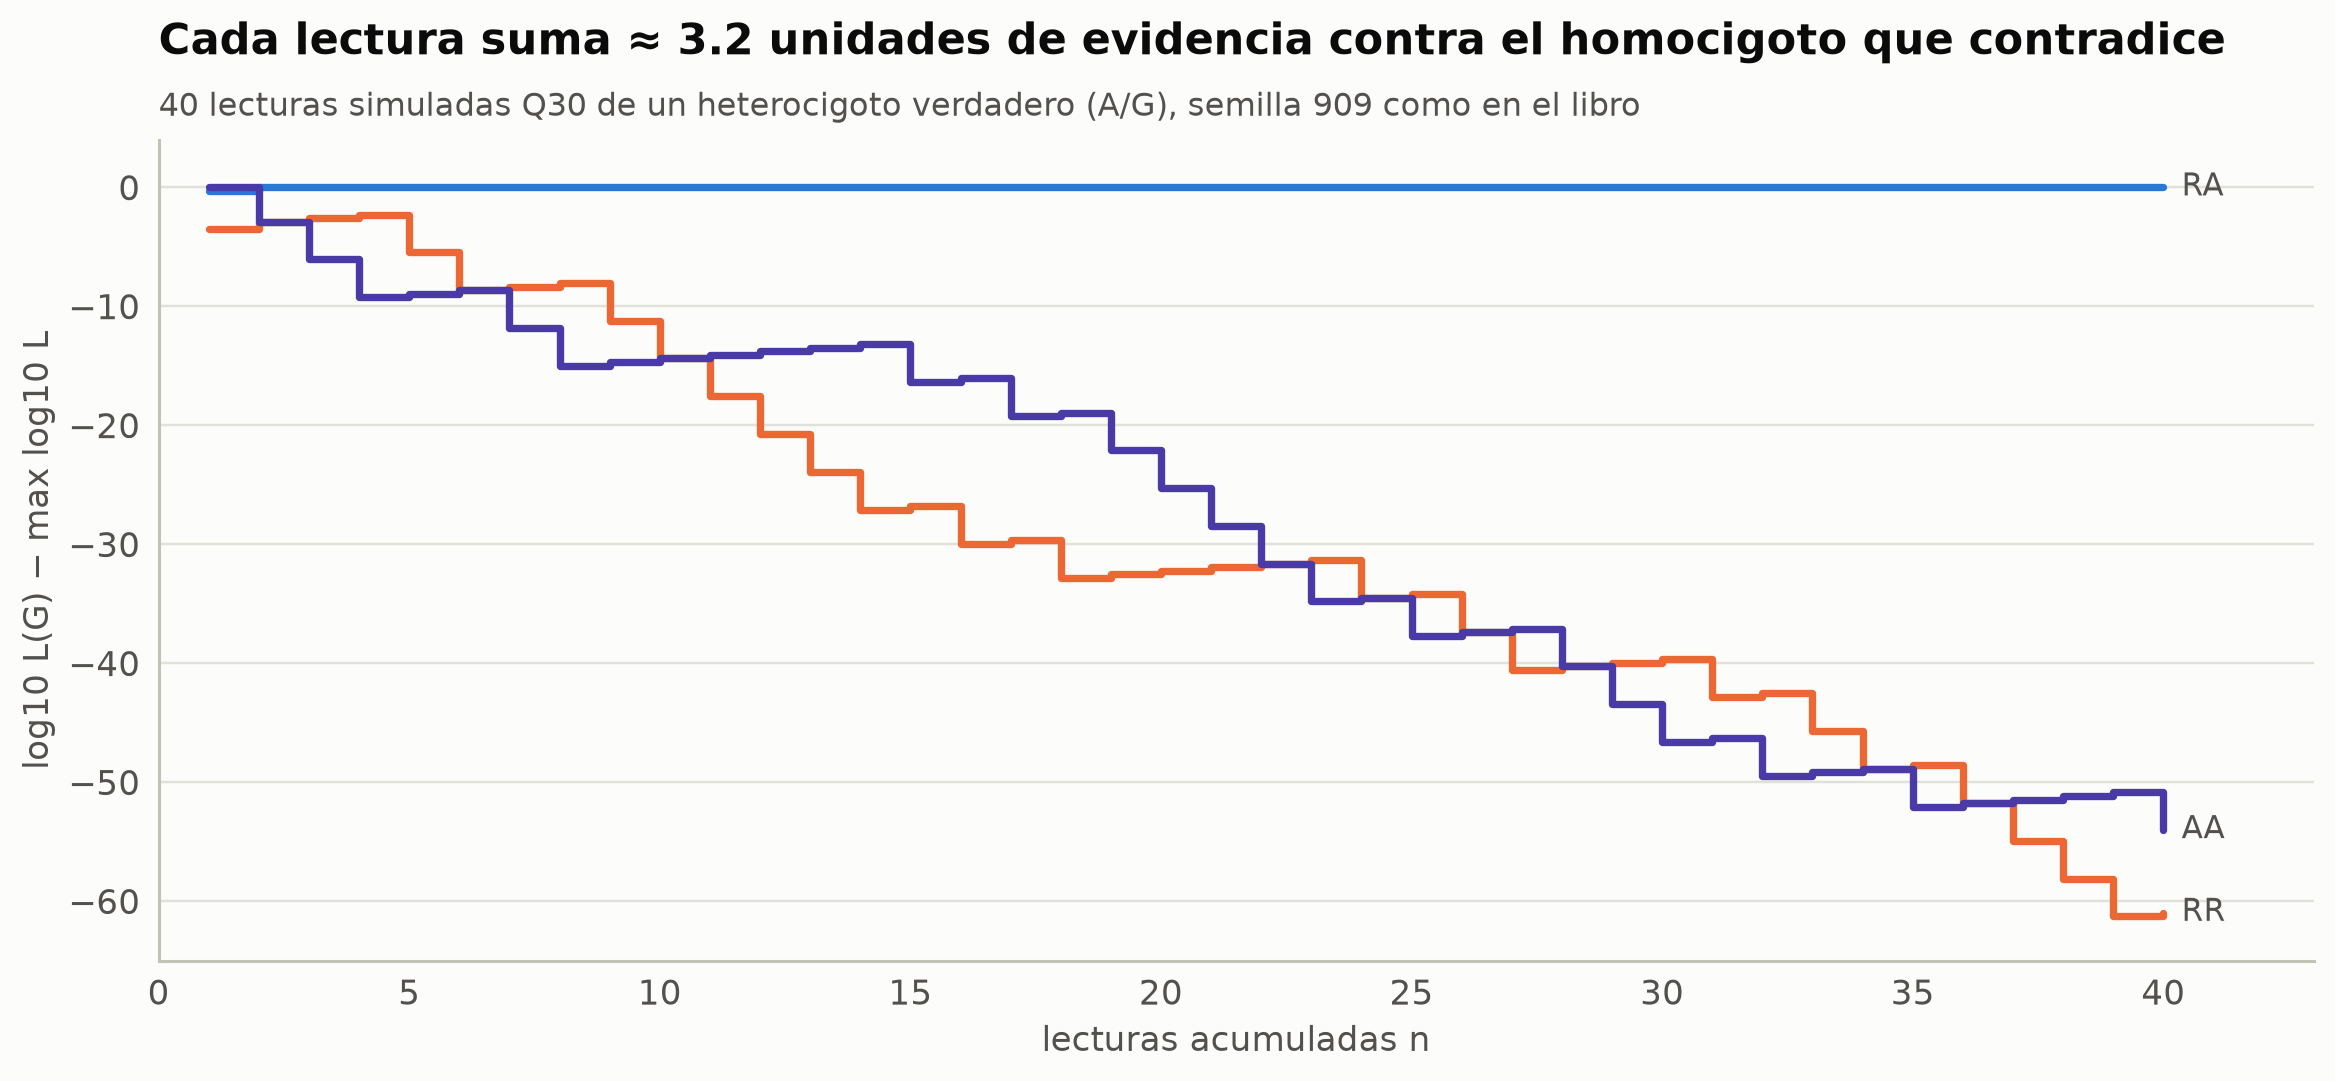

In [8]:
rng_book = np.random.default_rng(909)     # misma semilla y mismo orden de sorteos que el libro
q, e = 30, 1e-3
acc_reads = []
for i in range(40):
    allele = R if rng_book.random() < 0.5 else A
    if rng_book.random() < e:
        allele = rng_book.choice([x for x in "ACGT" if x != allele])
    acc_reads.append((str(allele), q))
bases40 = "".join(b for b, _ in acc_reads)
acc = []
for n in range(1, 41):
    l = {g: log10_lik(acc_reads[:n], GENO[g]) for g in GENO}
    mx = max(l.values())
    acc.append({"n": n, **{g: l[g] - mx for g in GENO}})
acc = pd.DataFrame(acc)
print("bases:", bases40)
print("n = 10:", acc.loc[9, ["RR", "RA", "AA"]].round(4).tolist(), "  n = 40:", acc.loc[39, ["RR", "RA", "AA"]].round(4).tolist())
assert bases40 == "GAAAGGAAGGGGGGAGAGAAAAAGAGGAAAGAGGAGGGGA"

fig, ax = plt.subplots(figsize=(10.5, 4.8))
for g in GENO:
    ax.step(acc["n"], acc[g], where="post", color=GENO_COLORS[g], lw=2.4)
    ec.label_end(ax, 40, acc[g].iloc[-1], g)
ax.set_xlim(0, 43); ax.set_ylim(-65, 4)
ax.set_xlabel("lecturas acumuladas n"); ax.set_ylabel("log10 L(G) − max log10 L")
ec.title(ax, "Cada lectura suma ≈ 3.2 unidades de evidencia contra el homocigoto que contradice",
         "40 lecturas simuladas Q30 de un heterocigoto verdadero (A/G), semilla 909 como en el libro")
plt.show()

> 🔎 **Qué observamos.** Con pocas lecturas los tres genotipos están cerca; luego $RR$ y $AA$ se hunden casi en línea
> recta. Cada `G` resta a $RR$ unas $\log_{10}(1/2)-\log_{10}(\varepsilon/3)\approx 3.2$ unidades (y cada `A` lo
> mismo a $AA$). Con $n=10$ (5 `G`), ambos homocigotos están 14.4 unidades por debajo; con $n=40$, a −61.0 y −54.0.

## 5. De verosimilitudes a PL

Las verosimilitudes son números diminutos: con 30 lecturas, $L(RR)$ puede valer $10^{-90}$, más pequeño de lo que un
ordenador guarda cómodamente. Por eso los programas trabajan con **logaritmos** y, siguiendo la tradición Phred, en
una escala de "decibanes" normalizada:

$$
\mathrm{PL}(G) = -10\log_{10}\frac{L(G)}{\max_{G'} L(G')}, \tag{09-pl}
$$

redondeado al entero más próximo. El genotipo más verosímil tiene $\mathrm{PL}=0$ y los demás, valores positivos.

| Símbolo | Significado |
|---|---|
| $\mathrm{PL}(G)$ | cuántos "decibanes" peor explica los datos $G$ que el mejor genotipo |
| $\max_{G'}L(G')$ | verosimilitud del genotipo que mejor explica los datos |

**A mano, para la columna 8:** $\log_{10}L = (-8.437;\ -1.840;\ -9.478)$, el máximo es $-1.840$, y
$\mathrm{PL} = \big(10\,(8.437-1.840),\ 0,\ 10\,(9.478-1.840)\big) = (66,\ 0,\ 76)$ en el orden $RR, RA, AA$ del VCF.
Un PL de 66 significa que $RR$ es $10^{6.6}\approx 4\times10^6$ veces menos verosímil que $RA$. En un VCF este
vector aparece en `FORMAT/PL` y es la información mínima que conviene guardar para recalcular genotipos después.

In [9]:
def pl_vector(ll):
    """PL (ecuación 09-pl) a partir de un diccionario de log10-verosimilitudes."""
    mx = max(ll.values())
    return {g: round(-10 * (v - mx)) for g, v in ll.items()}

print("log10 L =", {g: round(v, 3) for g, v in LL8.items()})
print("PL      =", pl_vector(LL8))
assert list(pl_vector(LL8).values()) == [66, 0, 76]

log10 L = {'RR': -8.437, 'RA': -1.84, 'AA': -9.478}
PL      = {'RR': 66, 'RA': 0, 'AA': 76}


> ✅ **Compruebe su comprensión.** Si una base cambiara de Q30 a Q40, ¿el PL de $RR$ subiría o bajaría? *(Subiría: la
> `G` sería aún menos compatible con $RR$; cada `G` de Q40 aporta $10\log_{10}\frac{0.5}{0.00033/10}\approx 42$ en
> vez de ≈ 32.)*

## 6. La distribución *a priori* y la heterocigosidad $\theta$

### Lo que sabemos antes de mirar

Si un amigo le dice que vio "un animal con rayas" en un parque de Bogotá, usted pensará antes en un gato atigrado
que en una cebra, aunque ambas explicaciones encajen con la descripción. No es terquedad: es usar lo que ya sabe
sobre la frecuencia de gatos y cebras en la ciudad.

En genómica, lo que sabemos de antemano es contundente: en la inmensa mayoría de las posiciones un individuo es
**idéntico** a la referencia. En humanos, dos cromosomas homólogos difieren en aproximadamente **una de cada mil
bases**. Suponer que los tres genotipos son igual de probables antes de ver las lecturas llevaría a declarar
variantes en cualquier lugar donde unos pocos errores coincidan.

### De la genética de poblaciones a una fórmula

Sea $\theta$ la **heterocigosidad** esperada por sitio: la probabilidad de que dos cromosomas tomados al azar
difieran en una posición. Bajo el modelo neutral de sitios infinitos, el número esperado de sitios en los que el
alelo derivado aparece en exactamente $i$ de $k$ cromosomas muestreados es $\theta/i$. Con $k=2$ (los dos cromosomas
de un diploide) el alternativo aparece una vez (heterocigoto) con probabilidad $\theta$ y dos veces (homocigoto
alternativo) con probabilidad $\theta/2$ (Nielsen et al., 2011; Li, 2011):

$$
P(RA) = \theta,\qquad P(AA) = \frac{\theta}{2},\qquad P(RR) = 1-\frac{3\theta}{2}. \tag{09-prior}
$$

| Símbolo | Significado |
|---|---|
| $\theta$ | heterocigosidad (tasa de mutación escalada) por sitio; del orden de $10^{-3}$ en humanos |
| $P(G)$ | probabilidad *a priori* del genotipo, antes de ver las lecturas |

**A mano:** con $\theta=10^{-3}$, $P(RR)=0.9985$, $P(RA)=0.001$ y $P(AA)=0.0005$.

> 🎓 **Para profundizar: de dónde sale $\theta/i$.** En una población de tamaño efectivo $N_e$ con tasa de mutación
> $\mu$ por sitio y generación se define $\theta = 4N_e\mu$. En la genealogía coalescente de $k$ cromosomas, la
> longitud total esperada de las ramas que sostienen exactamente $i$ hojas es $4N_e/i$ generaciones, así que el
> número esperado de mutaciones que aparecen en exactamente $i$ copias es $\mu\cdot4N_e/i=\theta/i$: el **espectro de
> frecuencias neutral**. Con $k=2$ sólo hay $i\in\{1,2\}$, con probabilidades $\theta$ y $\theta/2$ cuando
> $\theta\ll1$.

> 🦠 **Extensión haploide (propia de este notebook, no del libro).** Con un solo cromosoma ($k=1$ en el mismo
> razonamiento) sólo hay dos genotipos y usaremos $P(A)=\theta$, $P(R)=1-\theta$. Es la forma más simple coherente
> con la anterior; la usaremos con las bacterias de la sección 11.

In [10]:
def priors(theta):
    """Distribución a priori diploide, ecuación 09-prior."""
    return {"RR": 1 - 1.5 * theta, "RA": theta, "AA": theta / 2}

print("θ = 1e-3 →", priors(1e-3))
print("θ = 1e-4 →", priors(1e-4))

θ = 1e-3 → {'RR': 0.9985, 'RA': 0.001, 'AA': 0.0005}
θ = 1e-4 → {'RR': 0.99985, 'RA': 0.0001, 'AA': 5e-05}


## 7. La posterior, QUAL y GQ

### Bayes: combinar lo que sabíamos con lo que vemos

Con verosimilitud y *a priori*, el teorema de Bayes da la probabilidad de cada genotipo **a la luz de los datos**:

$$
P(G\mid D) = \frac{P(D\mid G)\,P(G)}{\displaystyle\sum_{G'\in\{RR,RA,AA\}} P(D\mid G')\,P(G')}. \tag{09-post}
$$

| Símbolo | Significado |
|---|---|
| $P(G\mid D)$ | probabilidad posterior del genotipo $G$ dados los datos |
| $P(D\mid G)$ | verosimilitud (09-lik) |
| $P(G)$ | distribución *a priori* (09-prior) |

El genotipo informado es el de máxima posterior, $\hat G=\arg\max_G P(G\mid D)$. Dos preguntas distintas se
responden con **dos números distintos** del VCF:

$$
\mathrm{QUAL} = -10\log_{10} P(G=RR \mid D),\qquad
\mathrm{GQ} = -10\log_{10}\bigl[1 - P(\hat G\mid D)\bigr]. \tag{09-qual}
$$

| Símbolo | Significado |
|---|---|
| QUAL | calidad del **sitio**: probabilidad, en escala Phred, de que **no** haya variante |
| GQ | calidad del **genotipo**: probabilidad, en escala Phred, de que el genotipo informado sea incorrecto |
| $\hat G$ | genotipo de máxima posterior |

QUAL responde "¿hay aquí una variante?"; GQ responde "¿es $RA$ o $AA$ (o $RR$)?". Los programas difieren en los
detalles: la especificación VCF define GQ **condicionado** a que el sitio sea variable (Danecek et al., 2011); GATK la
aproxima como la diferencia entre los dos PL más pequeños, es decir, **sin** *a priori* (DePristo et al., 2011). La
ecuación 09-qual usa una tercera versión, **incondicional** (sobre todos los genotipos, sin condicionar a que el sitio
sea variable), que es la que calcularemos a mano. Conviene saber cuál usa el programa antes de fijar umbrales.

### ✍️ Ejemplo resuelto: posterior, QUAL y GQ de la columna 8

Con $\theta=10^{-3}$:

$$
\begin{aligned}
P(D\mid RR)P(RR) &= 3.66\times10^{-9}\times0.9985 = 3.65\times10^{-9},\\
P(D\mid RA)P(RA) &= 1.44\times10^{-2}\times0.001 = 1.44\times10^{-5},\\
P(D\mid AA)P(AA) &= 3.33\times10^{-10}\times0.0005 = 1.66\times10^{-13}.
\end{aligned}
$$

Normalizando, $P(RA\mid D)=0.99975$, $P(RR\mid D)=2.5\times10^{-4}$ y $P(AA\mid D)\approx10^{-8}$. Por lo tanto
$\mathrm{QUAL} = -10\log_{10}(2.5\times10^{-4}) \approx 36$ y $\mathrm{GQ} = -10\log_{10}(1-0.99975)\approx 36$.
Coinciden porque la alternativa más probable a $RA$ es precisamente $RR$. La versión "sin *a priori*" de GQ (diferencia
de los dos PL más pequeños) daría $66-0=66$. La diferencia de 30 unidades es exactamente
$-10\log_{10}(0.001/0.9985)\approx30$: **la distribución *a priori* exige tres órdenes de magnitud adicionales de
evidencia antes de creer en una variante.**

A continuación, la función `llamar` del libro, tal cual, y su salida.

In [11]:
# genotipos.py (código del libro, capítulo 9)
def log10_lik_book(bases, quals, a1, a2):
    """log10 P(D | G={a1,a2}) con el modelo de 4 bases."""
    s = 0.0
    for b, q in zip(bases, quals):
        e = 10 ** (-q / 10)
        p = lambda a: 1 - e if b == a else e / 3
        s += math.log10(0.5 * p(a1) + 0.5 * p(a2))
    return s

def llamar(bases, quals, ref, alt, theta=1e-3):
    G = {"0/0": (ref, ref), "0/1": (ref, alt), "1/1": (alt, alt)}
    prior = {"0/0": 1 - 1.5 * theta, "0/1": theta, "1/1": theta / 2}
    ll = {g: log10_lik_book(bases, quals, *a) for g, a in G.items()}
    m = max(ll.values())
    pl = {g: round(-10 * (v - m)) for g, v in ll.items()}
    num = {g: 10 ** (ll[g] - m) * prior[g] for g in G}
    z = sum(num.values())
    post = {g: v / z for g, v in num.items()}
    gt = max(post, key=post.get)
    qual = -10 * math.log10(max(post["0/0"], 1e-30))
    gq = -10 * math.log10(max(1 - post[gt], 1e-30))
    return gt, pl, round(qual, 1), round(gq, 1)

res = llamar("AAAGGG", [30, 30, 20, 30, 30, 10], "A", "G")
print(res)
assert res == ("0/1", {"0/0": 66, "0/1": 0, "1/1": 76}, 36.0, 36.0)

('0/1', {'0/0': 66, '0/1': 0, '1/1': 76}, 36.0, 36.0)


In [12]:
def call_site(reads, theta=1e-3, genos=GENO, prior=None):
    """Llamada completa de una columna: log10 L, PL, posterior, genotipo, QUAL y GQ (ecs. 09-lik a 09-qual).
    reads = [(base, Q), ...]. Trabaja en logaritmos para no desbordar con columnas profundas."""
    prior = prior or priors(theta)
    ll = {g: log10_lik(reads, genos[g]) for g in genos}
    lp = {g: ll[g] + math.log10(prior[g]) for g in genos}          # log10 [P(D|G) P(G)]

    def log10_sum(vals):                                           # log10(Σ 10^v) sin desbordar
        m = max(vals)
        return m + math.log10(sum(10 ** (v - m) for v in vals))

    lz = log10_sum(list(lp.values()))
    post = {g: 10 ** (lp[g] - lz) for g in genos}
    gt = max(post, key=post.get)
    ref_g = next(iter(genos))                      # el primer genotipo es el de referencia (RR o R)
    # 1 − P(Ĝ|D) se calcula como la suma de las demás posteriores, en logaritmos, para no perder precisión
    return dict(ll=ll, pl=pl_vector(ll), post=post, gt=gt,
                qual=-10 * (lp[ref_g] - lz),
                gq=-10 * (log10_sum([lp[g] for g in genos if g != gt]) - lz))

c8 = call_site(D8)
print("posterior:", {g: f"{v:.5g}" for g, v in c8["post"].items()})
print(f"QUAL = {c8['qual']:.2f}   GQ = {c8['gq']:.2f}   GQ «sin a priori» (2.º PL − 1.º) = "
      f"{sorted(c8['pl'].values())[1] - sorted(c8['pl'].values())[0]}")
print(f"Diferencia debida a la a priori: −10·log10(0.001/0.9985) = {-10 * math.log10(0.001 / 0.9985):.2f}")

posterior: {'RR': '0.00025284', 'RA': '0.99975', 'AA': '1.151e-08'}
QUAL = 35.97   GQ = 35.97   GQ «sin a priori» (2.º PL − 1.º) = 66
Diferencia debida a la a priori: −10·log10(0.001/0.9985) = 29.99


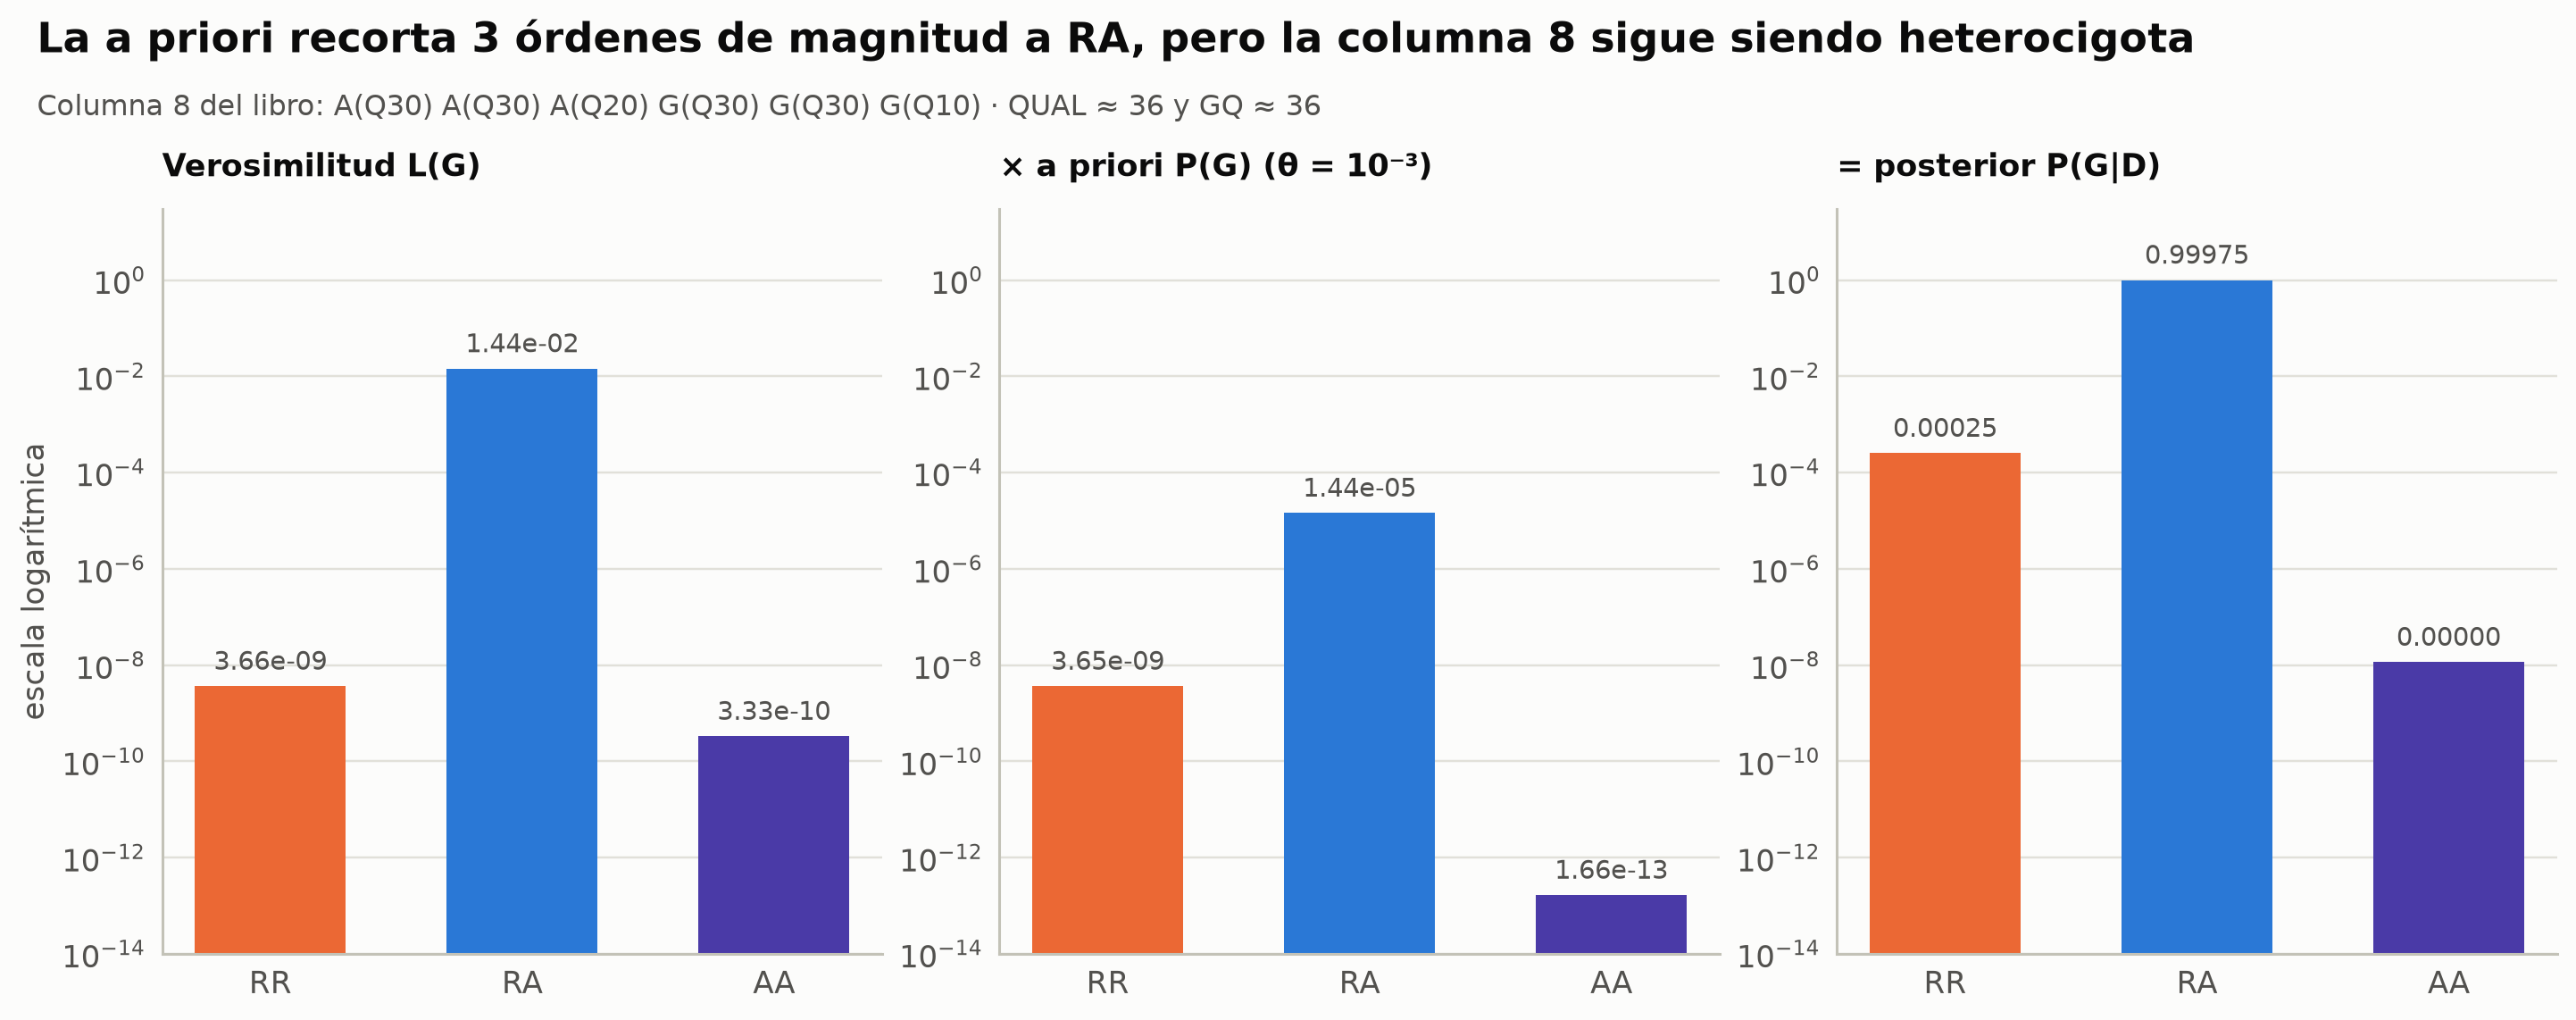

In [13]:
fig, axs = plt.subplots(1, 3, figsize=(13, 4.4))
steps = [("Verosimilitud L(G)", {g: L8[g] for g in GENO}, "{:.2e}"),
         ("× a priori P(G) (θ = 10⁻³)", {g: L8[g] * priors(1e-3)[g] for g in GENO}, "{:.2e}"),
         ("= posterior P(G|D)", c8["post"], "{:.5f}")]
for ax, (ttl, vals, fmt) in zip(axs, steps):
    y = [vals[g] for g in GENO]
    ax.bar(list(GENO), y, color=[GENO_COLORS[g] for g in GENO], width=0.6)
    ax.set_yscale("log"); ax.set_ylim(1e-14, 30)
    for i, v in enumerate(y):
        ax.text(i, v * 2.2, fmt.format(v), ha="center", fontsize=9.5, color=ec.INK_2)
    ax.set_title(ttl, loc="left", fontsize=11.5)
axs[0].set_ylabel("escala logarítmica")
ec.fig_title(fig, "La a priori recorta 3 órdenes de magnitud a RA, pero la columna 8 sigue siendo heterocigota",
             "Columna 8 del libro: A(Q30) A(Q30) A(Q20) G(Q30) G(Q30) G(Q10) · QUAL ≈ 36 y GQ ≈ 36")
plt.show()

> 🔎 **Qué observamos.** De izquierda a derecha, Bayes en tres pasos. La *a priori* sube a $RR$ (×0.9985) y baja a
> $RA$ (×0.001), pero siete órdenes de magnitud de ventaja en la verosimilitud no se borran con tres: la posterior
> queda $P(RA\mid D)=0.99975$. Las cifras coinciden con el ejemplo del libro.

### Cuando la *a priori* manda: baja profundidad

Con sólo **dos** lecturas de Q30, una `A` y una `G`, los datos favorecen al heterocigoto (PL = (29, 0, 29)); pero con
$\theta=10^{-3}$ la posterior es $P(RR\mid D)=0.571$ y el genotipo informado sería **$RR$**. Una lectura alternativa
aporta un factor $\approx(1/2)/(\varepsilon/3)=1\,500$ a favor del heterocigoto, insuficiente frente a la razón
*a priori* $0.9985/0.001\approx1\,000$ multiplicada por el factor $\approx2$ de la lectura de referencia.

In [14]:
for reads in ([("G", 30)], [("A", 30), ("G", 30)], [("G", 30), ("G", 30)]):
    c = call_site(reads)
    print(f"{' '.join(b + str(q) for b, q in reads):<10} PL = {tuple(c['pl'].values())}   posterior = "
          + ", ".join(f"{g}: {v:.4f}" for g, v in c["post"].items()) + f"   → {c['gt']}")

G30        PL = (35, 3, 0)   posterior = RR: 0.2499, RA: 0.3751, AA: 0.3750   → RA
A30 G30    PL = (29, 0, 29)   posterior = RR: 0.5710, RA: 0.4287, AA: 0.0003   → RR
G30 G30    PL = (70, 6, 0)   posterior = RR: 0.0001, RA: 0.3334, AA: 0.6664   → AA


> 🤔 **Antes de ejecutar, prediga.** Para un heterocigoto verdadero secuenciado con $n$ lecturas Q30, ¿con qué $n$
> cree que el llamador acierta el 99 % de las veces? Piense en dos fuentes de fallo: los **errores** de secuenciación
> y el **azar del muestreo** (que por pura mala suerte casi todas las lecturas vengan del mismo cromosoma).

Además del error de secuenciación está el **error de muestreo**: con $n$ lecturas, la probabilidad de no ver alguno
de los dos alelos es $2\cdot(1/2)^n$, que vale 0.125 con $n=4$ y 0.002 con $n=10$. Promediando sobre el número de
lecturas alternativas $k\sim\mathrm{Binomial}(n, \approx\tfrac12)$ calculamos la probabilidad de que el genotipo de
máxima posterior sea $RA$.

 n   uniforme   θ=1e-3   θ=1e-4
 4   0.8750   0.6247   0.6247
 6   0.9687   0.8747   0.8747
10   0.9980   0.9882   0.9441
20   1.0000   0.9998   0.9998


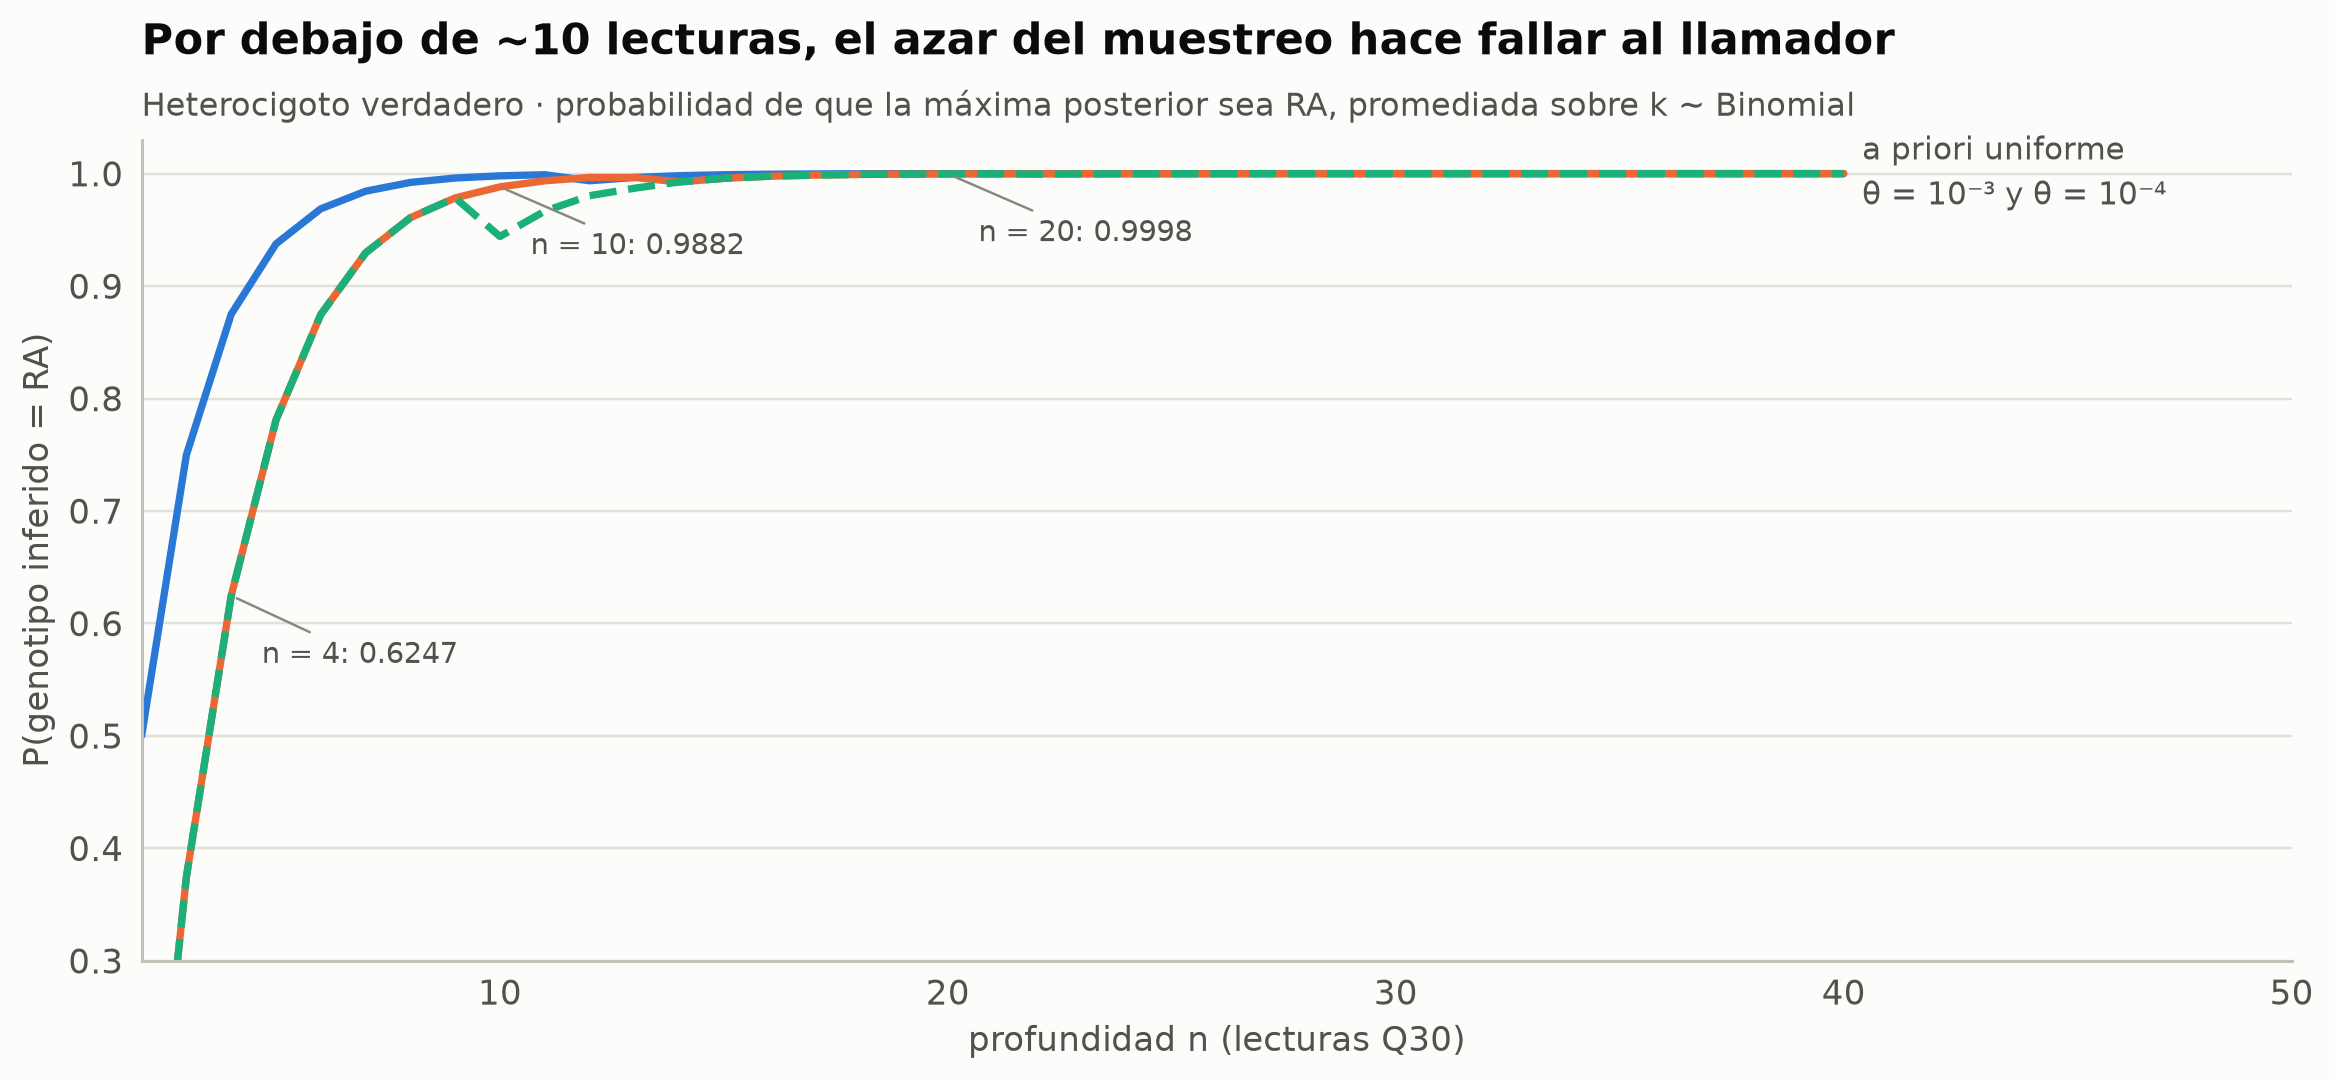

In [15]:
def p_call_het(n, theta, q=30):
    """P(genotipo de máxima posterior = RA | heterocigoto verdadero, n lecturas de calidad q),
    promediando sobre k ~ Binomial(n, p_alt)."""
    e = 10 ** (-q / 10)
    palt = 0.5 * (1 - e) + 0.5 * e / 3
    pr = priors(theta) if theta else {"RR": 1, "RA": 1, "AA": 1}
    tot = 0.0
    for k in range(n + 1):
        rr = [(A, q)] * k + [(R, q)] * (n - k)
        l = {g: log10_lik(rr, GENO[g]) + math.log10(pr[g]) for g in GENO}
        if max(l, key=l.get) == "RA":
            tot += stats.binom.pmf(k, n, palt)
    return tot

ns = np.arange(2, 41)
curves = {"a priori uniforme": [p_call_het(n, 0) for n in ns],
          "θ = 10⁻³": [p_call_het(n, 1e-3) for n in ns],
          "θ = 10⁻⁴": [p_call_het(n, 1e-4) for n in ns]}
print(" n   uniforme   θ=1e-3   θ=1e-4")
for n in (4, 6, 10, 20):
    print(f"{n:>2}   " + "   ".join(f"{curves[c][n - 2]:.4f}" for c in curves))

fig, ax = plt.subplots(figsize=(10.5, 4.8))
for (lab, y), col, ls in zip(curves.items(), [ec.BLUE, ec.ORANGE, ec.AQUA], ["-", "-", "--"]):
    ax.plot(ns, y, color=col, lw=2.4, ls=ls)
ec.label_end(ax, 40, curves["a priori uniforme"][-1] + 0.02, "a priori uniforme")
ec.label_end(ax, 40, curves["θ = 10⁻³"][-1] - 0.02, "θ = 10⁻³ y θ = 10⁻⁴")
for n in (4, 10, 20):
    v = curves["θ = 10⁻³"][n - 2]
    ax.annotate(f"n = {n}: {v:.4f}", (n, v), xytext=(10, -22), textcoords="offset points", fontsize=9.5,
                color=ec.INK_2, arrowprops=dict(arrowstyle="-", color=ec.MUTED, lw=0.8))
ax.set_xlim(2, 50); ax.set_ylim(0.3, 1.03)
ax.set_xlabel("profundidad n (lecturas Q30)"); ax.set_ylabel("P(genotipo inferido = RA)")
ec.title(ax, "Por debajo de ~10 lecturas, el azar del muestreo hace fallar al llamador",
         "Heterocigoto verdadero · probabilidad de que la máxima posterior sea RA, promediada sobre k ~ Binomial")
plt.show()

> 🔎 **Qué observamos.** Con $\theta=10^{-3}$, la probabilidad de acertar el heterocigoto es **0.62** con 4 lecturas,
> **0.87** con 6, **0.988** con 10 y **0.9998** con 20 (las cifras del libro). De ahí la regla práctica de que el
> genotipado individual fiable exige unas **15–20×**. Una *a priori* más escéptica ($\theta=10^{-4}$) coincide con la
> de $10^{-3}$ en casi todas las profundidades (la decisión cambia sólo en contados valores de $k$; con $n=10$ baja a
> 0.944): es un modelo discreto, con escalones. Y los estudios de **baja** cobertura necesitan otra estrategia, la
> llamada conjunta de la sección 10.

### La posterior en función de las lecturas alternativas

Fijemos $n=20$ lecturas Q30 y variemos cuántas muestran el alelo alternativo, $k$.

 k     RR     RA     AA gt
 2 0.9914 0.0086 0.0000 RR
 3 0.0372 0.9628 0.0000 RA
18 0.0000 0.9452 0.0548 RA
19 0.0000 0.0057 0.9943 AA


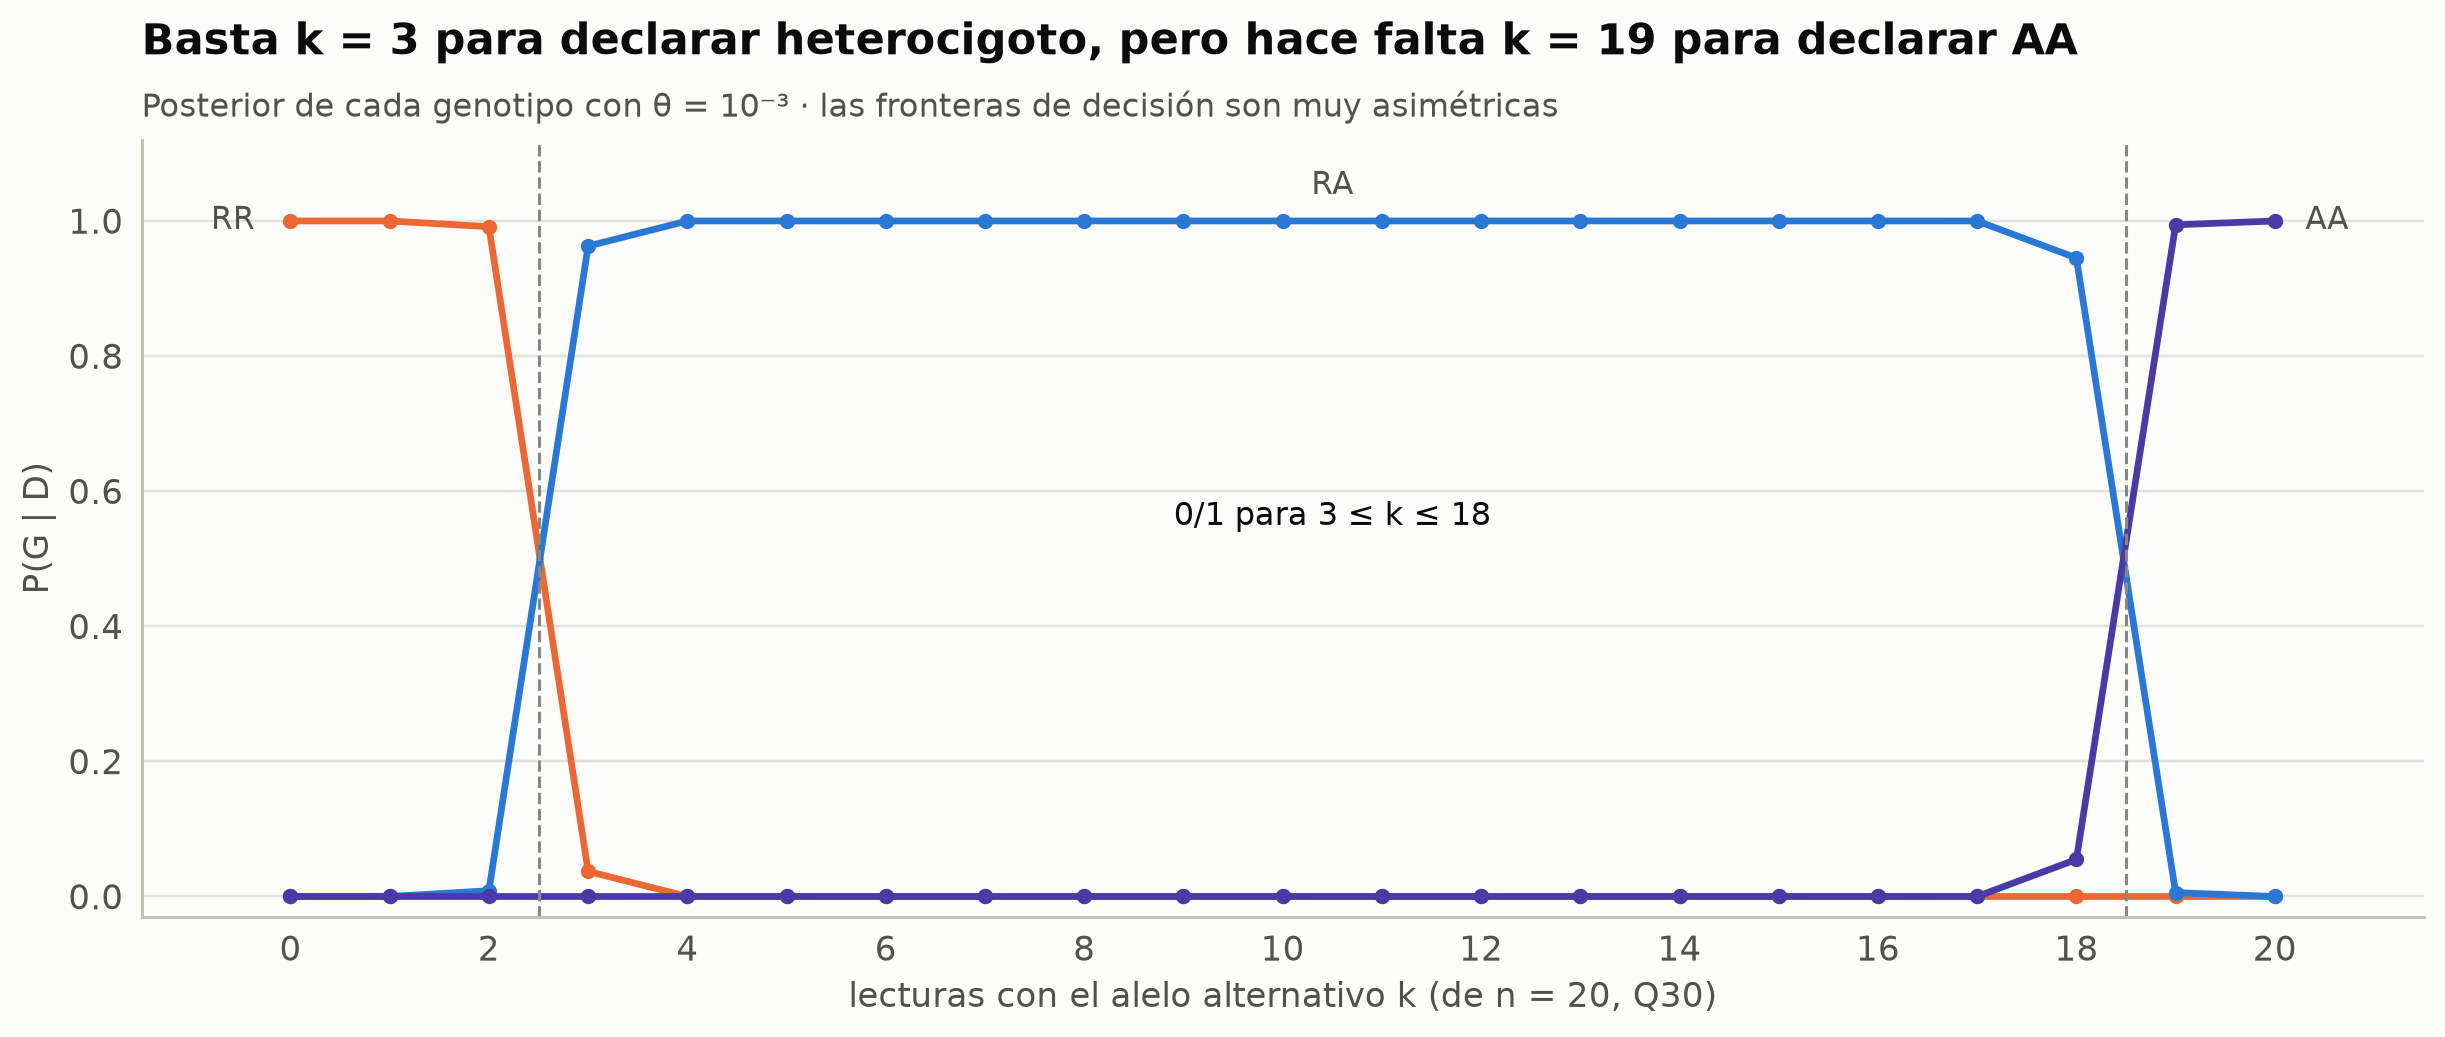

In [16]:
n20 = 20
postk = []
for k in range(n20 + 1):
    c = call_site([(A, 30)] * k + [(R, 30)] * (n20 - k))
    postk.append({"k": k, **c["post"], "gt": c["gt"]})
postk = pd.DataFrame(postk)
print(postk.loc[[2, 3, 18, 19], ["k", "RR", "RA", "AA", "gt"]].round(4).to_string(index=False))

fig, ax = plt.subplots(figsize=(11, 4.6))
for g in GENO:
    ax.plot(postk["k"], postk[g], "-o", ms=4, color=GENO_COLORS[g], lw=2.2)
ec.label_end(ax, 20, 1.0, "AA", dx=10); ec.label_end(ax, 0, 1.0, "RR", dx=-26)
ax.text(10.5, 1.04, "RA", color=ec.INK_2, fontsize=10, ha="center")
for x in (2.5, 18.5):
    ax.axvline(x, color=ec.MUTED, ls="--", lw=1)
ax.text(10.5, 0.55, "0/1 para 3 ≤ k ≤ 18", ha="center", fontsize=10.5, color=ec.INK)
ax.set_xticks(range(0, 21, 2)); ax.set_xlim(-1.5, 21.5); ax.set_ylim(-0.03, 1.12)
ax.set_xlabel("lecturas con el alelo alternativo k (de n = 20, Q30)"); ax.set_ylabel("P(G | D)")
ec.title(ax, "Basta k = 3 para declarar heterocigoto, pero hace falta k = 19 para declarar AA",
         "Posterior de cada genotipo con θ = 10⁻³ · las fronteras de decisión son muy asimétricas")
plt.show()

> 🔎 **Qué observamos.** Con 3 lecturas alternativas de 20, $P(RA\mid D)=0.96$; con 2, la posterior de $RR$ es todavía
> 0.99: la *a priori* desplaza la frontera izquierda hacia la derecha. A la derecha hacen falta **19** para declarar
> $AA$, porque bajo $RA$ ver 18 `G` de 20 es unas nueve veces más plausible que, bajo $AA$, ver dos errores de Q30.
> Compare con su predicción de la sección 2: una `G` de 20 no basta; tres, sí.

### 🎛️ Explorador interactivo de una columna

Mueva el deslizador para cambiar $k$ (lecturas alternativas de $n=20$). Cada genotipo tiene tres barras, una por
calidad de base (Q10, Q20, Q30), para ver cómo la calidad cambia el veredicto. Pase el ratón por las barras: verá el
vector PL completo, la posterior, QUAL, GQ y el genotipo llamado.

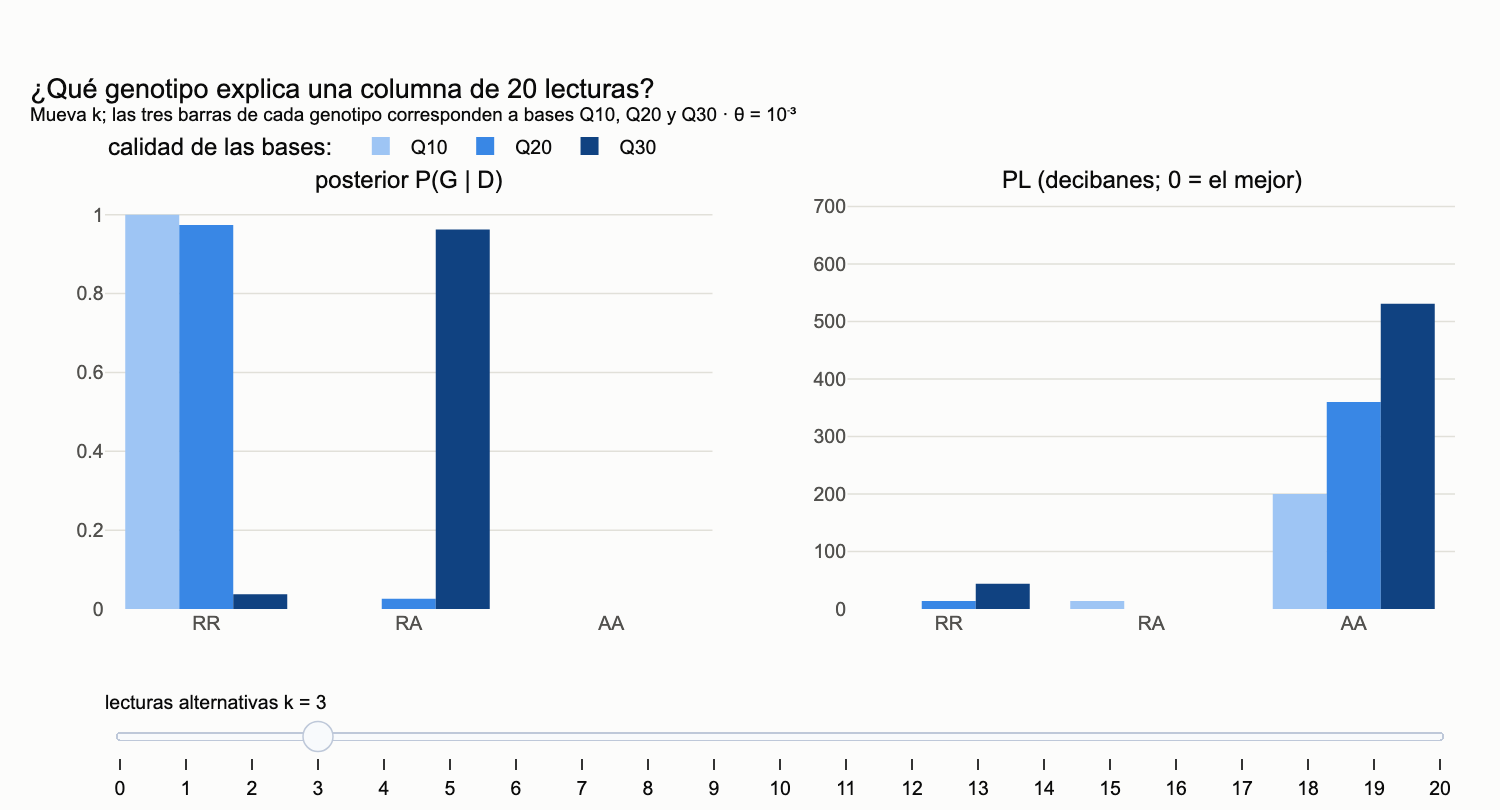

In [17]:
QS, N_EXP = (10, 20, 30), 20
Q_COL = {10: "#9ec5f4", 20: "#3987e5", 30: "#104281"}
fig = make_subplots(rows=1, cols=2, subplot_titles=("posterior P(G | D)", "PL (decibanes; 0 = el mejor)"),
                    horizontal_spacing=0.1)
n_tr = 0
for k in range(N_EXP + 1):
    for q in QS:
        c = call_site([(A, q)] * k + [(R, q)] * (N_EXP - k))
        pl_txt = "(" + ", ".join(str(c["pl"][g]) for g in GENO) + ")"
        hover = [f"<b>{g}</b> · bases Q{q} · k = {k} de {N_EXP}<br>P({g}|D) = {c['post'][g]:.4g}"
                 f"<br>PL = {pl_txt}<br>QUAL = {c['qual']:.1f} · GQ = {c['gq']:.1f}"
                 f"<br>genotipo llamado: <b>{c['gt']}</b>" for g in GENO]
        vis = k == 3
        fig.add_trace(go.Bar(x=list(GENO), y=[c["post"][g] for g in GENO], name=f"Q{q}", marker_color=Q_COL[q],
                             hovertext=hover, hoverinfo="text", visible=vis, legendgroup=f"Q{q}", showlegend=True),
                      row=1, col=1)
        fig.add_trace(go.Bar(x=list(GENO), y=[c["pl"][g] for g in GENO], name=f"Q{q}", marker_color=Q_COL[q],
                             hovertext=hover, hoverinfo="text", visible=vis, legendgroup=f"Q{q}", showlegend=False),
                      row=1, col=2)
        n_tr += 2
per_k = 2 * len(QS)
steps = []
for k in range(N_EXP + 1):
    vis = [False] * n_tr
    vis[k * per_k:(k + 1) * per_k] = [True] * per_k
    steps.append(dict(method="update", args=[{"visible": vis}], label=str(k)))
fig.update_layout(sliders=[dict(active=3, steps=steps, currentvalue=dict(prefix="lecturas alternativas k = "),
                                pad=dict(t=50))],
                  barmode="group", height=540, margin=dict(t=130, l=70, r=30, b=60),
                  title="¿Qué genotipo explica una columna de 20 lecturas?<br><sup>Mueva k; las tres barras de cada "
                        "genotipo corresponden a bases Q10, Q20 y Q30 · θ = 10⁻³</sup>",
                  legend=dict(orientation="h", yanchor="bottom", y=1.06, x=0, title="calidad de las bases: "))
fig.update_yaxes(range=[0, 1.05], row=1, col=1); fig.update_yaxes(range=[0, 720], row=1, col=2)
fig.show()

> 🔎 **Qué observamos.** Con bases Q30, $k=3$ ya da $RA$; con Q20 hacen falta $k=4$ y con **Q10**, $k=7$: siete `G`
> de baja calidad todavía podrían ser errores. En el otro extremo pasa al revés: con Q10 el llamador declara $AA$ ya
> con $k=17$ (tres `A` de Q10 se explican como errores), con Q20 desde $k=18$ y con Q30 sólo desde $k=19$. Los PL de
> Q10 son siempre mucho menores: **la calidad de las bases fija cuánta evidencia aporta cada lectura**.

### 🎛️ Mapa de decisiones: profundidad frente a lecturas alternativas

Ahora barremos las dos variables a la vez ($n$ de 1 a 40, $k$ de 0 a $n$, bases Q30, $\theta=10^{-3}$). El color es
el genotipo llamado y la intensidad, su GQ. Pase el ratón por cualquier celda.

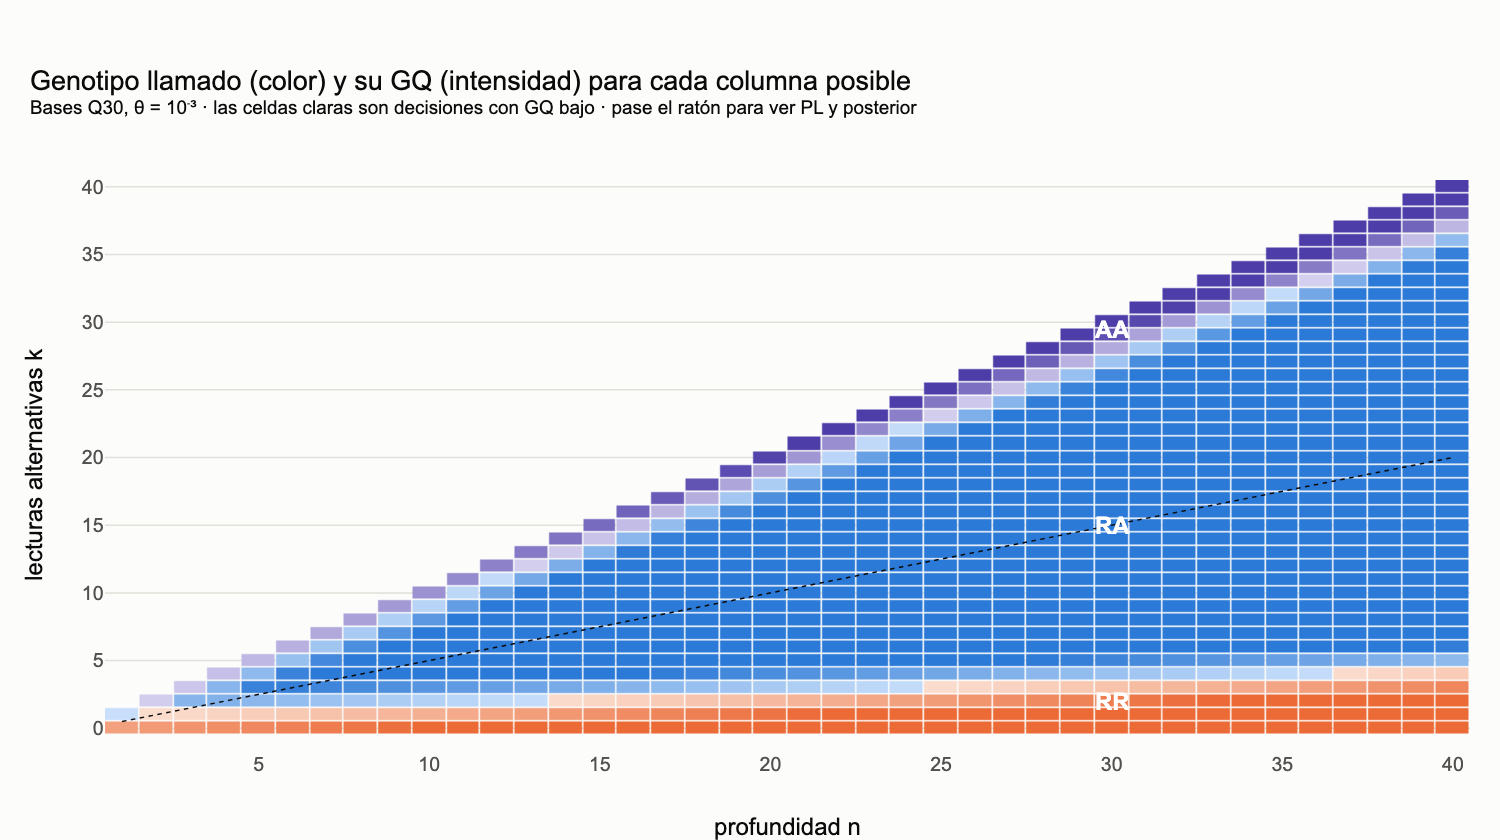

In [18]:
NMAX = 40
z = np.full((NMAX + 1, NMAX), np.nan); hov = [["" for _ in range(NMAX)] for _ in range(NMAX + 1)]
code = {"RR": 0, "RA": 1, "AA": 2}
for n in range(1, NMAX + 1):
    for k in range(n + 1):
        c = call_site([(A, 30)] * k + [(R, 30)] * (n - k))
        gq = min(c["gq"], 99)
        z[k, n - 1] = code[c["gt"]] + min(gq, 60) / 61       # parte entera = genotipo; decimal = GQ
        hov[k][n - 1] = (f"n = {n}, k = {k} (fracción alt. {k / n:.2f})<br>PL = ("
                         + ", ".join(str(c['pl'][g]) for g in GENO) + ")<br>"
                         + "<br>".join(f"P({g}|D) = {c['post'][g]:.3g}" for g in GENO)
                         + f"<br>QUAL = {min(c['qual'], 999):.0f} · GQ = {gq:.0f}<br><b>llamado: {c['gt']}</b>")
cs = [[0, "#fbe3d6"], [0.333, ec.ORANGE], [0.3334, "#cde2fb"], [0.666, ec.BLUE], [0.6667, "#ddd8f3"], [1, ec.VIOLET]]
fig = go.Figure(go.Heatmap(z=z, x=np.arange(1, NMAX + 1), y=np.arange(NMAX + 1), colorscale=cs, zmin=0, zmax=3,
                           hovertext=hov, hoverinfo="text", showscale=False, xgap=1, ygap=1))
fig.add_trace(go.Scatter(x=[1, NMAX], y=[0.5, NMAX / 2], mode="lines", line=dict(color=ec.INK, dash="dot", width=1),
                         name="k = n/2 (heterocigoto ideal)", hoverinfo="skip"))
for txt, x, y in (("RR", 30, 2), ("RA", 30, 15), ("AA", 30, 29.5)):
    fig.add_annotation(x=x, y=y, text=f"<b>{txt}</b>", showarrow=False, font=dict(size=16, color="white"))
fig.update_layout(height=560, xaxis_title="profundidad n", yaxis_title="lecturas alternativas k",
                  title="Genotipo llamado (color) y su GQ (intensidad) para cada columna posible<br><sup>Bases Q30, "
                        "θ = 10⁻³ · las celdas claras son decisiones con GQ bajo · pase el ratón para ver PL y posterior</sup>",
                  legend=dict(orientation="h", yanchor="bottom", y=1.02, x=0), margin=dict(t=120, l=70, r=20, b=60))
fig.show()

> 🔎 **Qué observamos.** La franja azul ($RA$) es ancha y ocupa casi todo el triángulo: basta una fracción alélica
> modesta, si la profundidad acompaña. Pero en la esquina de baja profundidad ($n\le5$) las celdas son claras (GQ
> bajo) y muchas columnas con una sola lectura alternativa se llaman $RR$. La frontera inferior **crece despacio** con
> $n$: con Q30 bastan 2 lecturas alternativas coincidentes si $n=10$, 3 si $n=20$ y 5 si $n=40$ (y unas 10 con
> $n=100$). Unas pocas lecturas alternativas de alta calidad ya son difíciles de explicar como errores, pero la
> *a priori* $RA$ exige una fracción mínima que no desaparece al subir la profundidad.

> ✅ **Compruebe su comprensión.** En un VCF ve `QUAL=60` y, para la única muestra, `GT=1/1:GQ=5`. ¿Hay
> contradicción? *(No: QUAL dice que casi seguro hay variante —la posterior de $RR$ es $10^{-6}$—; GQ dice que no está
> claro si es $RA$ o $AA$. Ocurre con pocas lecturas, todas alternativas.)*

## 8. Un caso clínico: el genotipo de un paciente, lectura a lectura

Un laboratorio de genética secuencia un **panel de genes** a una paciente con sospecha de una enfermedad
hereditaria autosómica dominante. En la posición que interesa (un sitio **simulado**, sin coordenadas reales), la
paciente es en realidad **heterocigota**: uno de sus cromosomas lleva el alelo `G` y el otro el de referencia `A`.
El informe dependerá de algo tan prosaico como **cuántas lecturas** cubrieron ese exón: los paneles de captura no
cubren todas las regiones por igual y hay exones que quedan a 5× mientras otros llegan a 300×.

Simulamos las lecturas que llegan a esa columna (alelo al azar con probabilidad ½, calidades típicas de Illumina
agrupadas en 37, 25 y 12, semilla fija) y recalculamos la posterior **después de cada lectura**, como si pudiéramos
detener el secuenciador en cualquier momento.

In [19]:
rng_pt = np.random.default_rng(97)
patient = []
for i in range(30):
    b = "G" if rng_pt.random() < 0.5 else "A"
    q = int(rng_pt.choice([37, 37, 37, 37, 25, 25, 12]))
    patient.append((b, q))
traj = []
for n in range(1, len(patient) + 1):
    c = call_site(patient[:n])
    traj.append({"n": n, "base": patient[n - 1][0], "Q": patient[n - 1][1], **c["post"], "gt": c["gt"],
                 "PL": tuple(c["pl"].values()), "QUAL": c["qual"], "GQ": c["gq"]})
traj = pd.DataFrame(traj)
first_ra = int(traj.loc[traj["gt"] == "RA", "n"].min())
print("lecturas:", " ".join(f"{b}{q}" for b, q in patient))
print(f"El llamado pasa a RA con la lectura n = {first_ra}; con n = 20: GQ = {traj.loc[19, 'GQ']:.0f}")
traj.loc[[0, 3, 4, 5, 7, 14, 29], ["n", "base", "Q", "RR", "RA", "AA", "gt", "PL", "QUAL", "GQ"]].round(4)

lecturas: A37 A37 A25 A37 G12 G37 A37 G12 G25 G25 A12 G37 A12 G37 A12 G37 G37 A25 G12 G37 A37 G37 A25 A12 A37 A37 A37 G25 A12 A25
El llamado pasa a RA con la lectura n = 6; con n = 20: GQ = 219


,n,base,Q,RR,RA,AA,gt,PL,QUAL,GQ
0,1,A,37,0.9995,0.0005,0.0,RR,"(0, 3, 42)",0.0022,33.0054
3,4,A,37,0.9999,0.0001,0.0,RR,"(0, 12, 155)",0.0003,42.0295
4,5,G,12,0.9986,0.0014,0.0,RR,"(2, 0, 140)",0.0062,28.4611
5,6,G,37,0.0853,0.9147,0.0,RA,"(40, 0, 137)",10.6924,10.6924
7,8,G,12,0.0081,0.9919,0.0,RA,"(51, 0, 173)",20.9051,20.9051
14,15,A,12,0.0000,1.0000,0.0,RA,"(173, 0, 202)",143.1522,143.1522
29,30,A,25,0.0000,1.0000,0.0,RA,"(342, 0, 446)",311.6346,311.6346


### 🎬 La posterior de la paciente, lectura a lectura

Arriba, la columna de la paciente crece (la opacidad de cada cuadro es su calidad). Abajo a la izquierda, la
posterior actual de $RR$, $RA$ y $AA$; a la derecha, su evolución con la profundidad.

![La posterior de RR/RA/AA de una paciente heterocigota (simulada) al añadir lecturas una a una: con 4 lecturas el informe diría 0/0; con 6 ya dice 0/1 y el GQ crece con la profundidad](https://raw.githubusercontent.com/juvenalyosa/bioinformatica-practica/main/assets/modulo-09-variantes/9.1_paciente_posterior.gif)

*La posterior de RR/RA/AA de una paciente heterocigota (simulada) al añadir lecturas una a una: con 4 lecturas el informe diría 0/0; con 6 ya dice 0/1 y el GQ crece con la profundidad*

In [20]:
fig = plt.figure(figsize=(12, 6.0))
fig.get_layout_engine().set(rect=(0, 0, 1, 0.88))
gs = fig.add_gridspec(2, 2, height_ratios=[0.35, 2], width_ratios=[1, 2.3], hspace=0.12)
ax_c = fig.add_subplot(gs[0, :]); ax_b = fig.add_subplot(gs[1, 0]); ax_t = fig.add_subplot(gs[1, 1])
ax_c.set_xlim(0, 31); ax_c.set_ylim(-0.8, 0.8); ax_c.axis("off")
cells = []
for i, (b, q) in enumerate(patient):
    r = Rectangle((i + 0.55, -0.42), 0.9, 0.84, color=ec.NUC_COLORS[b], alpha=0.25 + 0.75 * q / 37, visible=False)
    t = ax_c.text(i + 1, 0, b, ha="center", va="center", fontsize=10, fontweight="bold", color="white", visible=False)
    ax_c.add_patch(r); cells.append((r, t))
bars = ax_b.bar(list(GENO), [0, 0, 0], color=[GENO_COLORS[g] for g in GENO], width=0.6)
btxt = [ax_b.text(i, 0, "", ha="center", va="bottom", fontsize=10, color=ec.INK_2) for i in range(3)]
ax_b.set_ylim(0, 1.15); ax_b.set_ylabel("P(G | D)")
lines = {g: ax_t.plot([], [], "-o", ms=3, lw=2.2, color=GENO_COLORS[g], label=g)[0] for g in GENO}
ax_t.set_xlim(0.5, 30.5); ax_t.set_ylim(-0.03, 1.05); ax_t.set_xlabel("profundidad n"); ax_t.set_ylabel("P(G | D)")
ax_t.legend(loc="center right", frameon=False)
info = fig.text(0.01, 0.905, "", fontsize=10.5, family="monospace", color=ec.INK, va="top")
fig.text(0.01, 0.99, "Con pocas lecturas, la a priori manda; con suficientes, los datos",
         fontsize=15, fontweight="bold", color=ec.INK, va="top")
fig.text(0.01, 0.95, "Paciente heterocigota (simulada) · θ = 10⁻³ · calidades 37/25/12", fontsize=10.5,
         color=ec.INK_2, va="top")

def update(f):
    n = min(f + 1, len(patient))
    for i, (r, t) in enumerate(cells):
        r.set_visible(i < n); t.set_visible(i < n)
    row = traj.iloc[n - 1]
    for i, g in enumerate(GENO):
        bars[i].set_height(row[g]); btxt[i].set_position((i, row[g] + 0.02)); btxt[i].set_text(f"{row[g]:.3f}")
        lines[g].set_data(traj["n"][:n], traj[g][:n])
    info.set_text(f"n = {n:>2} · última lectura {row['base']}(Q{row['Q']}) · PL = {row['PL']} · "
                  f"QUAL = {min(row['QUAL'], 999):5.1f} · GQ = {min(row['GQ'], 999):5.1f} · llamado: {row['gt']}")
    return []

fig.canvas.draw()
with plt.rc_context({"savefig.bbox": None}):
    anim_html = ec.animate(fig, update, frames=len(patient) + 4, interval=450, name="9.1_paciente_posterior")
anim_html

▶️ Ejecute esta celda para ver la animación con controles (la vista previa GIF está en la celda de texto de arriba).

> 🔎 **Qué observamos.** Las cuatro primeras lecturas muestran la referencia: con esa cobertura el informe diría
> `0/0` con mucha confianza, y sería un **falso negativo**. La primera `G` no basta (la *a priori* pesa 1 000 a 1); la
> segunda, sí. A partir de ahí $RA$ se estabiliza y el GQ crece casi linealmente con la profundidad. Por eso los
> laboratorios clínicos informan la **cobertura mínima** del panel y confirman por otra técnica (por ejemplo, Sanger)
> las regiones que quedaron por debajo del umbral.

> ✅ **Compruebe su comprensión.** Si en el sitio de la paciente la cobertura final fuera 5× con las lecturas
> `A A A A G`, ¿qué genotipo y qué GQ informaría el modelo? ¿Qué le diría usted al médico? *(Mire la fila n = 5 de
> la tabla: se llama $RR$ con GQ ≈ 28, que parece seguro. Pero el PL es (2, 0, 140): **los datos** prefieren
> ligeramente $RA$, y toda la confianza en $RR$ viene de la *a priori*. Un GQ alto no protege de la baja cobertura;
> lo honesto es informar "no concluyente por cobertura insuficiente".)*

## 9. BAQ: cuando el error no es de la base sino del alineamiento

El modelo de la ecuación 09-lik supone que cada base está **bien alineada**. Cerca de un *indel* esto falla con
frecuencia: si una lectura termina poco después de una deleción, al alineador le puede "salir más barato" colocar
dos o tres desapareamientos que abrir un hueco (Módulo 7). Esas bases **mal alineadas**, con calidades Phred
altísimas, aparecen en el *pileup* como **SNV falsas agrupadas junto al *indel***.

Imagine que copia un texto y se salta una palabra, pero sólo le queda una línea: en vez de dejar el hueco, sigue
escribiendo y las últimas letras quedan desplazadas. Cada letra está "bien escrita" (alta calidad), pero **en el
sitio equivocado**. La calidad Phred mide lo primero, no lo segundo.

Li (2011b) propuso la **calidad de alineamiento de la base** (BAQ): para cada lectura se realinea localmente contra
la referencia con un **HMM de pares** (el modelo de tres estados emparentado con Gotoh, Módulo 3) y se calcula, con
el algoritmo de avance-retroceso, la probabilidad posterior $p_i$ de que la base $i$ esté alineada con la posición
que le asignó el alineador. La calidad efectiva de la base pasa a ser

$$
Q_i^{\text{ef}} = \min\bigl(Q_i,\ \mathrm{BAQ}_i\bigr),\qquad \mathrm{BAQ}_i = -10\log_{10}(1-p_i). \tag{09-baq}
$$

| Símbolo | Significado |
|---|---|
| $Q_i$ | calidad Phred original de la base $i$ (error de lectura) |
| $p_i$ | probabilidad posterior, según el HMM de pares, de que la base esté bien alineada |
| $\mathrm{BAQ}_i$ | probabilidad de mal alineamiento en escala Phred |

**A mano.** Si el HMM dice que una base de Q37 está bien colocada con $p_i=0.6$, entonces
$\mathrm{BAQ}_i=-10\log_{10}0.4=4.0$ y $Q^{\text{ef}}_i=\min(37, 4.0)=4.0$: la base pasa de "casi infalible" a
"poco más que una moneda". Lejos de los *indels*, $p_i\approx1$ y la calidad no cambia.

### Un experimento de juguete

No programaremos el HMM de pares completo; en su lugar tomamos una versión mínima con **dos alineamientos
candidatos** para el final de una lectura: (1) sin hueco, con un desapareamiento de Q37 en la última base, y (2) con
una deleción de 2 pb justo antes, que hace coincidir esa base. Con una probabilidad de abrir un hueco
$\delta=10^{-4}$ (valor ilustrativo), la posterior de que la base esté donde la puso el alineador es
$p = \frac{P(\text{aln 1})}{P(\text{aln 1}) + P(\text{aln 2})}$. Después aplicamos BAQ a una columna de 30 lecturas en la
que 8 de ellas terminan justo ahí y muestran esa `G` falsa.

P(aln 1) ∝ ε/3 = 6.65e-05 · P(aln 2) ∝ δ(1−ε) = 1.00e-04
p_i = 0.399 → BAQ = 2.21 → Q_ef = min(37, 2.21) = 2.21
sin BAQ: llamado RA · QUAL = 213.9 · PL = (244, 0, 829)
con BAQ: llamado RR · QUAL = 0.0 · PL = (0, 55, 899)


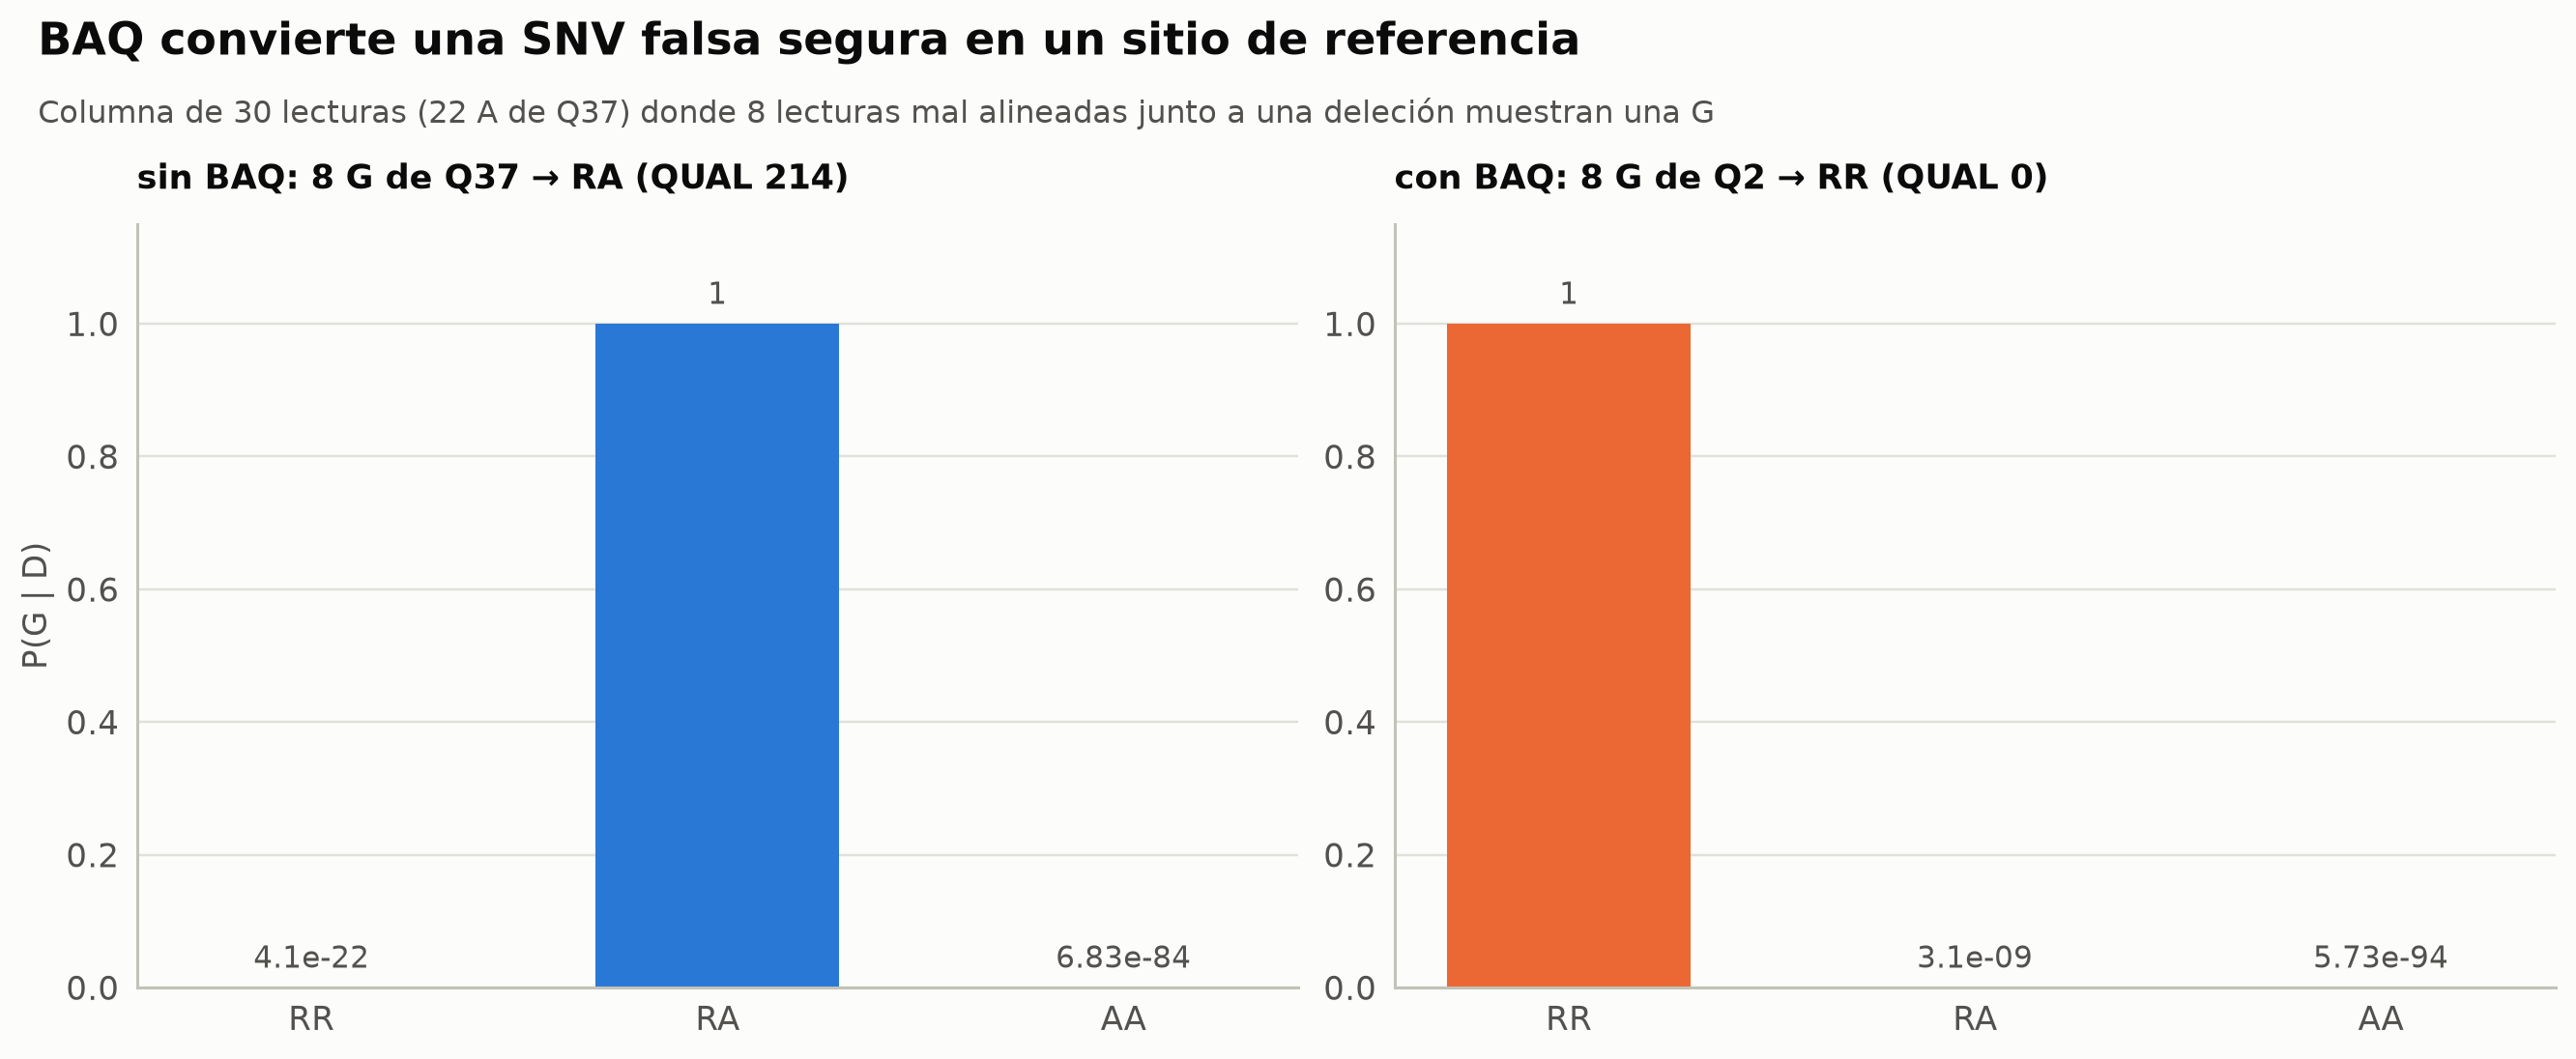

In [21]:
q_hi = 37
e_hi = 10 ** (-q_hi / 10)
delta = 1e-4                                  # probabilidad ilustrativa de abrir un hueco
p_aln1 = e_hi / 3                             # aln 1: la última base es un desapareamiento
p_aln2 = delta * (1 - e_hi)                   # aln 2: un hueco y la base coincide
p_i = p_aln1 / (p_aln1 + p_aln2)
baq = -10 * math.log10(1 - p_i)
q_ef = min(q_hi, baq)
print(f"P(aln 1) ∝ ε/3 = {p_aln1:.2e} · P(aln 2) ∝ δ(1−ε) = {p_aln2:.2e}")
print(f"p_i = {p_i:.3f} → BAQ = {baq:.2f} → Q_ef = min({q_hi}, {baq:.2f}) = {q_ef:.2f}")

col_raw = [(R, 37)] * 22 + [(A, 37)] * 8        # 8 lecturas terminan tras la deleción y muestran la G falsa
col_baq = [(R, 37)] * 22 + [(A, round(q_ef))] * 8
c_raw, c_baq = call_site(col_raw), call_site(col_baq)
for lab, c in (("sin BAQ", c_raw), ("con BAQ", c_baq)):
    print(f"{lab}: llamado {c['gt']} · QUAL = {min(c['qual'], 999):.1f} · PL = {tuple(c['pl'].values())}")

fig, axs = plt.subplots(1, 2, figsize=(12, 4.2))
for ax, (lab, c) in zip(axs, (("sin BAQ: 8 G de Q37", c_raw), (f"con BAQ: 8 G de Q{round(q_ef)}", c_baq))):
    y = [c["post"][g] for g in GENO]
    ax.bar(list(GENO), y, color=[GENO_COLORS[g] for g in GENO], width=0.6)
    for i, v in enumerate(y):
        ax.text(i, v + 0.03, f"{v:.3g}", ha="center", fontsize=10, color=ec.INK_2)
    ax.set_ylim(0, 1.15); ax.set_title(f"{lab} → {c['gt']} (QUAL {min(c['qual'], 999):.0f})", loc="left", fontsize=11.5)
axs[0].set_ylabel("P(G | D)")
ec.fig_title(fig, "BAQ convierte una SNV falsa segura en un sitio de referencia",
             "Columna de 30 lecturas (22 A de Q37) donde 8 lecturas mal alineadas junto a una deleción muestran una G")
plt.show()

> 🔎 **Qué observamos.** Sin BAQ, ocho `G` de Q37 son una evidencia aplastante de heterocigoto: el llamador
> declararía una SNV con QUAL altísimo junto a cada deleción. Con BAQ esas bases valen $Q\approx2$ y ocho de ellas no
> compensan 22 lecturas de referencia: el sitio vuelve a $RR$. Es un ejemplo elegante de **propagar** una fuente de
> incertidumbre (el alineamiento) a la etapa siguiente en vez de ignorarla. Un efecto parecido se consigue con la
> **calidad de mapeo** (MAPQ, Módulo 7): las lecturas con MAPQ bajo, que podrían pertenecer a otra copia de una
> repetición, se descartan o se ponderan a la baja. En la sección 11 veremos un caso real en el que ni siquiera eso
> basta.

## 10. Llamada conjunta de varias muestras

### La idea: la población como testigo adicional

Cuando se secuencian muchos individuos de una población a **baja** cobertura (un estudio de 1 000 personas a 4×
cuesta mucho menos que 250 a 16×), cada muestra por separado es casi ciega. Pero la **frecuencia del alelo
alternativo en la población**, $\psi$, es un parámetro **compartido**: si varias muestras muestran indicios débiles
de la misma variante, la evidencia se acumula. Es como un profesor que duda si una respuesta rara de un alumno es
un error de copia, hasta que ve que un tercio de la clase escribió lo mismo.

Bajo equilibrio de **Hardy-Weinberg**, la *a priori* del genotipo de cada individuo depende de $\psi$:
$P(RR)=(1-\psi)^2$, $P(RA)=2\psi(1-\psi)$, $P(AA)=\psi^2$. Li (2011) estima $\psi$ por máxima verosimilitud con el
**algoritmo EM** (el mismo esquema de la Lección 4.3). Si $h\in\{0,1,2\}$ cuenta las copias del alelo alternativo y
$N$ es el número de muestras, cada iteración actualiza

$$
\psi^{(t+1)} = \frac{1}{2N}\sum_{s=1}^{N}\ \sum_{h=0}^{2} h\;
\frac{P(D_s\mid h)\,P(h\mid\psi^{(t)})}{\sum_{h'}P(D_s\mid h')\,P(h'\mid\psi^{(t)})}. \tag{09-em}
$$

| Símbolo | Significado |
|---|---|
| $\psi$ | frecuencia del alelo alternativo en la población muestreada |
| $D_s$ | lecturas de la muestra $s$ en el sitio |
| $h$ | copias del alelo alternativo en el genotipo (0, 1 o 2) |
| $P(h\mid\psi)$ | probabilidad de Hardy-Weinberg del genotipo con $h$ copias |
| $N$ | número de muestras analizadas conjuntamente |

La lectura es muy intuitiva: el **paso E** calcula, para cada muestra, el número **esperado** de copias alternativas
dados sus datos y la frecuencia actual (la fracción es una posterior, como en la sección 7); el **paso M** promedia
esos números sobre los $2N$ cromosomas. Cada iteración no puede disminuir la verosimilitud conjunta.

**A mano, la primera iteración para M1** (1 lectura alternativa de 3, Q20, modelo bialélico 09-li, $\psi^{(0)}=0.5$):
la fracción alternativa esperada por lectura es $f_h = \tfrac h2(1-\varepsilon)+(1-\tfrac h2)\varepsilon$, o sea
$f_0=0.01$, $f_1=0.5$, $f_2=0.99$; $P(D\mid h)=f_h(1-f_h)^2$ da $0.0098$, $0.125$, $0.000099$; con la *a priori*
$(0.25, 0.5, 0.25)$ las posteriores son $(0.038, 0.962, 0.0004)$ y M1 aporta $\approx0.96$ copias esperadas.

### ✍️ Ejemplo resuelto: ocho muestras de baja cobertura

Ocho individuos a 2–5× muestran (lecturas alternativas, profundidad) $=(1,3),(2,4),(0,3),(3,5),(1,2),(0,4),(2,3),(0,2)$,
todas con Q20. Partimos de $\psi^{(0)}=0.5$.

In [22]:
SAMPLES = {"M1": (1, 3), "M2": (2, 4), "M3": (0, 3), "M4": (3, 5),
           "M5": (1, 2), "M6": (0, 4), "M7": (2, 3), "M8": (0, 2)}      # (lecturas alt, profundidad), Q20
e20 = 10 ** (-20 / 10)

def lik_bial(k, n, h, e):
    """P(D | h) con el modelo bialélico de Li (h copias ALTERNATIVAS de 2):
    cada lectura muestra el alternativo con probabilidad f_h = h/2 (1−e) + (1 − h/2) e."""
    f = h / 2 * (1 - e) + (1 - h / 2) * e
    return f ** k * (1 - f) ** (n - k)

Lg = {s: np.array([lik_bial(k, n, h, e20) for h in (0, 1, 2)]) for s, (k, n) in SAMPLES.items()}
H = np.array([0, 1, 2])

def hw(psi):
    return np.array([(1 - psi) ** 2, 2 * psi * (1 - psi), psi ** 2])

def em(psi0, tol=1e-10, max_it=200):
    """EM de la ecuación 09-em. Devuelve la lista [ψ0, ψ1, ...] y las posteriores de cada iteración."""
    psi, hist, posts = psi0, [psi0], []
    for _ in range(max_it):
        pri = hw(psi)
        post = {s: Lg[s] * pri / (Lg[s] * pri).sum() for s in SAMPLES}      # paso E
        posts.append(post)
        new = sum((post[s] * H).sum() for s in SAMPLES) / (2 * len(SAMPLES))  # paso M
        hist.append(new)
        if abs(new - psi) < tol:
            break
        psi = new
    return hist, posts

hist, posts = em(0.5)
psi_hat = hist[-1]
print("ψ por iteración:", [round(float(x), 4) for x in hist[:6]], "…")
print(f"iteraciones = {len(hist) - 1} · ψ̂ = {psi_hat:.4f}")

prior_ind = np.array([1 - 1.5e-3, 1e-3, 0.5e-3])                            # ecuación 09-prior, θ = 1e-3
rows = []
for s in SAMPLES:
    ind = Lg[s] * prior_ind / (Lg[s] * prior_ind).sum()
    joint = Lg[s] * hw(psi_hat) / (Lg[s] * hw(psi_hat)).sum()
    rows.append({"muestra": s, "alt/prof.": "{}/{}".format(*SAMPLES[s]),
                 "sola P(RR)": ind[0], "sola P(RA)": ind[1], "conjunta P(RR)": joint[0], "conjunta P(RA)": joint[1],
                 "conjunta P(AA)": joint[2]})
tab_em = pd.DataFrame(rows)
display(tab_em.style.format({c: "{:.3f}" for c in tab_em.columns[2:]}).hide(axis="index"))
assert len(hist) - 1 == 12 and round(psi_hat, 3) == 0.331

ψ por iteración: [0.5, 0.3537, 0.3336, 0.331, 0.3307, 0.3306] …
iteraciones = 12 · ψ̂ = 0.3306


muestra,alt/prof.,sola P(RR),sola P(RA),conjunta P(RR),conjunta P(RA),conjunta P(AA)
M1,1/3,0.987,0.013,0.074,0.926,0.000
M2,2/4,0.610,0.390,0.002,0.998,0.000
M3,0/3,1.000,0.000,0.887,0.113,0.000
M4,3/5,0.030,0.968,0.000,0.999,0.001
M5,1/2,0.975,0.025,0.038,0.953,0.009
M6,0/4,1.000,0.000,0.940,0.060,0.000
M7,2/3,0.432,0.546,0.001,0.980,0.019
M8,0/2,1.000,0.000,0.799,0.201,0.000


> 🔎 **Qué observamos.** El EM produce $0.354,\ 0.334,\ 0.331,\dots$ y converge en **12 iteraciones** a
> $\hat\psi=0.331$, como en el libro. Mire la muestra **M1**, con una lectura alternativa de tres: analizada sola, con
> la *a priori* 09-prior y $\theta=10^{-3}$, su posterior es $P(RR)=0.987$ y se la declararía homocigota de
> referencia. Analizada con las demás, cuya evidencia colectiva establece que la variante es común, pasa a
> $P(RA)=0.926$. **La muestra no cambió; cambió lo que sabemos de la población.**

### 🎬 El EM en acción

A la izquierda, la estimación de $\psi$ en cada iteración; a la derecha, la posterior (apilada $RR$/$RA$/$AA$) de
cada muestra en esa iteración.

![Iteraciones del EM de la frecuencia alélica ψ para las ocho muestras de baja cobertura: ψ pasa de 0.5 a 0.331 y las posteriores de cada muestra se ajustan a la frecuencia poblacional](https://raw.githubusercontent.com/juvenalyosa/bioinformatica-practica/main/assets/modulo-09-variantes/9.1_em_frecuencia.gif)

*Iteraciones del EM de la frecuencia alélica ψ para las ocho muestras de baja cobertura: ψ pasa de 0.5 a 0.331 y las posteriores de cada muestra se ajustan a la frecuencia poblacional*

In [23]:
names = list(SAMPLES)
fig, (ax_p, ax_s) = plt.subplots(1, 2, figsize=(12.5, 5.2), gridspec_kw=dict(width_ratios=[1, 1.5]))
fig.get_layout_engine().set(rect=(0, 0, 1, 0.88))
ax_p.set_xlim(-0.5, 12.5); ax_p.set_ylim(0.3, 0.52)
ax_p.axhline(psi_hat, color=ec.MUTED, ls="--", lw=1)
ax_p.text(12.4, psi_hat - 0.006, f"ψ̂ = {psi_hat:.3f}", ha="right", va="top", fontsize=10, color=ec.INK_2)
ax_p.set_xlabel("iteración t"); ax_p.set_ylabel("ψ(t)")
line_p, = ax_p.plot([], [], "-o", color=ec.BLUE, lw=2.2, ms=5)
x = np.arange(len(names))
stack = {g: ax_s.bar(x, np.zeros(len(names)), color=GENO_COLORS[g], width=0.65, label=g) for g in GENO}
ax_s.set_xticks(x, [f"{s}\n{SAMPLES[s][0]}/{SAMPLES[s][1]}" for s in names]); ax_s.set_ylim(0, 1)
ax_s.set_ylabel("P(genotipo | D, ψ)"); ax_s.legend(ncol=3, loc="upper center", bbox_to_anchor=(0.5, 1.13), frameon=False)
status = fig.text(0.01, 0.905, "", fontsize=11, family="monospace", color=ec.INK, va="top")
fig.text(0.01, 0.99, "La frecuencia poblacional se aprende de todas las muestras a la vez",
         fontsize=15, fontweight="bold", color=ec.INK, va="top")
fig.text(0.01, 0.95, "EM de la ecuación 09-em · 8 muestras a 2–5×, bases Q20 · ψ(0) = 0.5", fontsize=10.5,
         color=ec.INK_2, va="top")

def update(f):
    t = min(f, len(posts) - 1)
    line_p.set_data(range(t + 1), hist[:t + 1])
    post = posts[t]
    bottom = np.zeros(len(names))
    for j, g in enumerate(GENO):
        h = np.array([post[s][j] for s in names])
        for rect, hh, bb in zip(stack[g], h, bottom):
            rect.set_height(hh); rect.set_y(bb)
        bottom += h
    status.set_text(f"iteración t = {t:>2} · ψ(t) = {hist[t]:.4f} · M1: P(RA) = {post['M1'][1]:.3f}")
    return []

fig.canvas.draw()
with plt.rc_context({"savefig.bbox": None}):
    anim_html = ec.animate(fig, update, frames=len(posts) + 5, interval=600, name="9.1_em_frecuencia")
anim_html

▶️ Ejecute esta celda para ver la animación con controles (la vista previa GIF está en la celda de texto de arriba).

> 🔎 **Qué observamos.** El mayor salto ocurre en la primera iteración (de 0.5 a 0.354); después, los cambios son de
> milésimas. Las muestras sin lecturas alternativas (M3, M6, M8) conservan una posterior de $RA$ no despreciable:
> con 2–4 lecturas, **no ver** el alelo alternativo es compatible con ser heterocigoto ($2\cdot(1/2)^n$ de nuevo).

¿Depende el resultado del punto de partida? Probemos varios $\psi^{(0)}$.

ψ(0) = 0.02 → ψ̂ = 0.3306 en 13 iteraciones
ψ(0) = 0.2  → ψ̂ = 0.3306 en 12 iteraciones
ψ(0) = 0.5  → ψ̂ = 0.3306 en 12 iteraciones
ψ(0) = 0.8  → ψ̂ = 0.3306 en 12 iteraciones
ψ(0) = 0.98 → ψ̂ = 0.3306 en 13 iteraciones


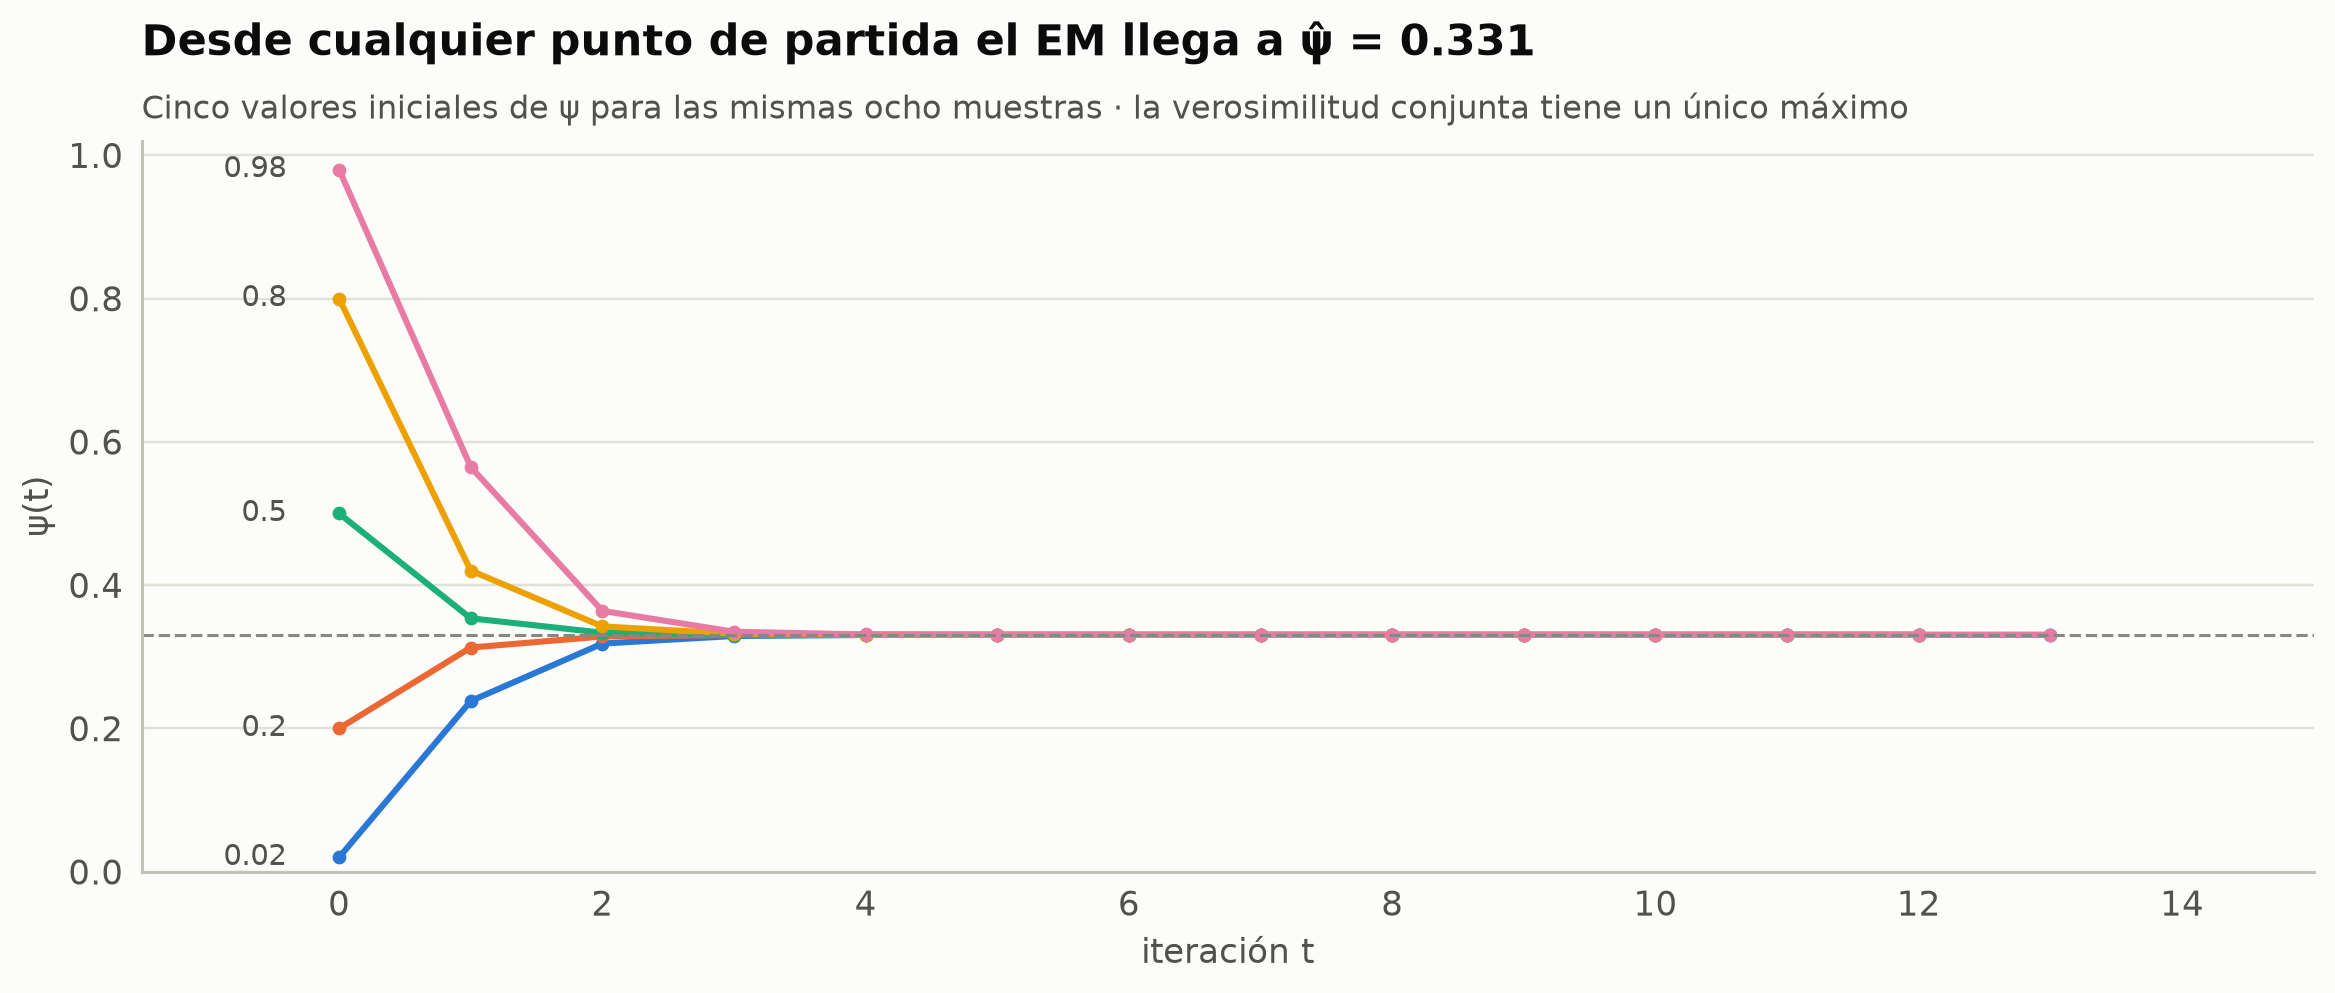

In [24]:
fig, ax = plt.subplots(figsize=(10.5, 4.4))
for p0, col in zip((0.02, 0.2, 0.5, 0.8, 0.98), ec.CATEGORICAL):
    h, _ = em(p0)
    ax.plot(range(len(h)), h, "-o", ms=3.5, lw=2, color=col)
    print(f"ψ(0) = {p0:<4} → ψ̂ = {h[-1]:.4f} en {len(h) - 1} iteraciones")
    ax.text(-0.4, p0, f"{p0}", ha="right", va="center", fontsize=9.5, color=ec.INK_2)
ax.axhline(psi_hat, color=ec.MUTED, ls="--", lw=1)
ax.set_xlim(-1.5, 15); ax.set_ylim(0, 1.02)
ax.set_xlabel("iteración t"); ax.set_ylabel("ψ(t)")
ec.title(ax, "Desde cualquier punto de partida el EM llega a ψ̂ = 0.331",
         "Cinco valores iniciales de ψ para las mismas ocho muestras · la verosimilitud conjunta tiene un único máximo")
plt.show()

> 🔎 **Qué observamos.** Todas las trayectorias convergen al mismo $\hat\psi$; las que empiezan lejos tardan unas
> iteraciones más. Aquí la verosimilitud tiene un único máximo; en problemas más complejos (muchos alelos, mezclas)
> conviene probar varios arranques, como con cualquier EM.

La llamada conjunta **no es gratuita**: supone una población aproximadamente panmíctica, y un **artefacto
sistemático** presente en todas las muestras (por ejemplo, lecturas mal mapeadas en una repetición) quedará
**reforzado** como si fuera una variante común. Los filtros de la Lección 9.2 existen precisamente para eso.

## 11. Datos reales: columnas haploides del clon del LTEE

Volvemos al hilo del curso: el clon de *Escherichia coli* B del **experimento de evolución a largo plazo** de Lenski
(LTEE) que controlamos en la Lección 6.2 (SRA `SRR2584863`, clon REL7179B del estudio de Tenaillon et al., 2016), cuyas
lecturas mapeamos en el Módulo 7 contra su ancestro **REL606** (`NC_012967.1`). Con todas las lecturas (~90× de media),
`bcftools` (Lección 9.2) propuso 40 variantes. Usaremos ese VCF como mapa y, para cada posición, leeremos la columna
**real** del BAM de ventanas del curso (26 504 lecturas en ±600 pb alrededor de cada variante) con `pysam`, con los
mismos filtros que usó `bcftools`: calidad de base ≥ 20 y calidad de mapeo ≥ 20.

**El puente de la ploidía.** *E. coli* es **haploide**: en la ecuación 09-li, $m=1$ y sólo hay dos genotipos, $R$ y
$A$. Usaremos la *a priori* haploide $P(A)=\theta$, $P(R)=1-\theta$ con $\theta=10^{-3}$ (valor ilustrativo) y
$\mathrm{QUAL}=-10\log_{10}P(R\mid D)$. Es la idea de `bcftools call --ploidy 1`, aunque `bcftools` usa su propio
modelo (con `-P 1.1e-3` como *a priori* por omisión), de modo que sus QUAL no coincidirán con los nuestros: la tabla
de abajo lo muestra.

In [25]:
CHROM = "NC_012967.1"
VCF_NAME, BAM_NAME = "SRR2584863_REL606_bcftools.vcf.gz", "SRR2584863_REL606_variant_windows.bam"

vcf = []
with gzip.open(course_file(VCF_NAME), "rt") as fh:
    for line in fh:
        if line.startswith("#"):
            continue
        f = line.rstrip("\n").split("\t")
        info = dict(kv.split("=", 1) if "=" in kv else (kv, True) for kv in f[7].split(";"))
        vcf.append({"pos": int(f[1]), "ref": f[3], "alt": f[4], "bcf_qual": float(f[5]),
                    "DP": int(info["DP"]), "indel": "INDEL" in info, "DP4": info.get("DP4", "")})
vcf = pd.DataFrame(vcf)
feat = pd.read_csv(course_file("NC_012967.1_features.tsv.gz"), sep="\t", skiprows=1)
ldr = feat[feat["product"].str.contains("Ldr", na=False) & feat["start"].between(1_268_000, 1_272_000)]
LDR_REGION = (int(ldr["start"].min()), int(ldr["end"].max()))
vcf["grupo"] = np.where(vcf["pos"].between(1_270_100, 1_270_600), "racimo Ldr",
                        np.where(vcf["indel"], "indel", np.where(vcf["bcf_qual"] > 200, "SNV QUAL alto", "SNV QUAL bajo")))
print(f"{len(vcf)} variantes en el VCF de bcftools:", vcf["grupo"].value_counts().to_dict())
print("Copias Ldr cerca del racimo:", ldr[["locus_tag", "start", "end", "strand"]].values.tolist())
vcf.head(10)

40 variantes en el VCF de bcftools: {'SNV QUAL alto': 20, 'racimo Ldr': 11, 'indel': 6, 'SNV QUAL bajo': 3}
Copias Ldr cerca del racimo: [['ECB_RS06325', 1269316, 1269423, '-'], ['ECB_RS06330', 1269851, 1269958, '-'], ['ECB_RS06335', 1270386, 1270493, '-']]


,pos,ref,alt,bcf_qual,DP,indel,DP4,grupo
0,9972,T,G,225.4170,59,False,"0,0,21,34",SNV QUAL alto
1,263235,G,T,225.4170,32,False,"0,0,11,18",SNV QUAL alto
2,281923,G,T,225.4170,52,False,"0,0,26,18",SNV QUAL alto
3,377000,T,G,228.3790,39,False,"0,1,14,20",SNV QUAL alto
4,433359,CTTTTTTT,CTTTTTTTT,228.4090,73,True,"1,1,15,44",indel
5,473901,CCGC,CCGCGC,228.4060,53,True,"2,0,14,31",indel
6,648692,C,T,225.4170,77,False,"0,0,47,20",SNV QUAL alto
7,1270133,T,C,39.4149,2,False,"0,0,0,2",racimo Ldr
8,1270134,T,G,43.4147,2,False,"0,0,0,2",racimo Ldr
9,1270157,T,A,42.4147,2,False,"0,0,0,2",racimo Ldr


In [26]:
def site_reads(bam, pos, min_bq=20, min_mq=20):
    """Lecturas de la columna pos (1-based) con pysam: base, calidad, MAPQ, hebra, NM de la lectura y
    posición de la base dentro de la lectura. Filtros explícitos (pysam descarta por defecto bases con Q < 13)."""
    out = []
    for col in bam.pileup(CHROM, pos - 1, pos, truncate=True, min_base_quality=min_bq,
                          min_mapping_quality=min_mq, ignore_orphans=True, ignore_overlaps=True):
        for pr in col.pileups:
            if pr.is_del or pr.is_refskip:
                continue
            aln = pr.alignment
            out.append({"pos": pos, "base": aln.query_sequence[pr.query_position],
                        "bq": aln.query_qualities[pr.query_position], "mq": aln.mapping_quality,
                        "reverse": aln.is_reverse, "nm": aln.get_tag("NM"), "qpos": pr.query_position,
                        "read": aln.query_name})
    return out

snv = vcf[~vcf["indel"]].copy()
if pysam is not None:
    course_file(BAM_NAME + ".bai")                  # el índice (.bai) debe estar junto al BAM
    bam = pysam.AlignmentFile(course_file(BAM_NAME))
    reads_tab = pd.DataFrame([r for p in snv["pos"] for r in site_reads(bam, p)])
else:                                               # respaldo: la misma tabla, precalculada con este código
    reads_tab = pd.read_csv(course_file("91_ltee_columnas.tsv.gz"), sep="\t")
print(f"{len(reads_tab):,} bases leídas en {reads_tab['pos'].nunique()} columnas SNV")
reads_tab.head()

1,129 bases leídas en 34 columnas SNV


,pos,base,bq,mq,reverse,nm,qpos,read
0,9972,G,37,60,True,1,144,SRR2584863.780749
1,9972,G,29,60,True,8,142,SRR2584863.377434
2,9972,G,33,60,False,1,140,SRR2584863.1227959
3,9972,G,39,60,True,1,140,SRR2584863.411193
4,9972,G,35,60,True,1,137,SRR2584863.457079


In [27]:
theta_h = 1e-3
rows = []
for _, v in snv.iterrows():
    col = reads_tab[reads_tab["pos"] == v["pos"]]
    reads = list(zip(col["base"], col["bq"]))
    hap = call_site(reads, genos={"R": (v["ref"], v["ref"]), "A": (v["alt"], v["alt"])},
                    prior={"R": 1 - theta_h, "A": theta_h})
    dip = call_site(reads, genos={"RR": (v["ref"], v["ref"]), "RA": (v["ref"], v["alt"]), "AA": (v["alt"], v["alt"])})
    alt = col[col["base"] == v["alt"]]
    rows.append({"pos": v["pos"], "cambio": f"{v['ref']}>{v['alt']}", "grupo": v["grupo"], "n": len(col),
                 "k_alt": len(alt), "otras": int((~col["base"].isin([v["ref"], v["alt"]])).sum()),
                 "alt_rev": int(alt["reverse"].sum()), "MQ_medio": col["mq"].mean(), "NM_alt": alt["nm"].mean(),
                 "haploide": hap["gt"], "QUAL_hap": hap["qual"], "diploide": dip["gt"],
                 "PL_dip": tuple(dip["pl"].values()), "QUAL_bcftools": v["bcf_qual"]})
calls = pd.DataFrame(rows)
with pd.option_context("display.max_rows", 50, "display.width", 200):
    display(calls.round(1))

,pos,cambio,grupo,n,k_alt,otras,alt_rev,MQ_medio,NM_alt,haploide,QUAL_hap,diploide,PL_dip,QUAL_bcftools
0,9972,T>G,SNV QUAL alto,55,55,0,34,60.0,1.2,A,2297.4,AA,"(2327, 166, 0)",225.4
1,263235,G>T,SNV QUAL alto,29,29,0,18,55.8,1.3,A,1036.2,AA,"(1066, 87, 0)",225.4
2,281923,G>T,SNV QUAL alto,45,45,0,18,60.0,1.2,A,2052.6,AA,"(2083, 135, 0)",225.4
3,377000,T>G,SNV QUAL alto,35,34,0,20,54.3,1.3,A,1305.4,AA,"(1335, 26, 0)",228.4
4,648692,C>T,SNV QUAL alto,67,67,0,20,59.7,1.1,A,2924.5,AA,"(2955, 202, 0)",225.4
5,1270133,T>C,racimo Ldr,2,2,0,2,60.0,5.0,A,54.5,AA,"(85, 6, 0)",39.4
6,1270134,T>G,racimo Ldr,2,2,0,2,60.0,5.0,A,59.5,AA,"(90, 6, 0)",43.4
7,1270157,T>A,racimo Ldr,2,2,0,2,60.0,5.0,A,58.5,AA,"(89, 6, 0)",42.4
8,1270197,A>G,racimo Ldr,3,3,0,3,55.7,5.7,A,97.3,AA,"(127, 9, 0)",65.4
9,1270204,A>G,racimo Ldr,2,2,0,2,53.5,6.0,A,55.5,AA,"(86, 6, 0)",40.4


> 🔎 **Qué observamos.** En las 20 SNV de QUAL alto, la columna es **unánime**: de 24 a 81 lecturas, todas (o todas
> menos una) con el alelo alternativo y repartidas entre las dos hebras. El modelo haploide llama $A$ con QUAL de
> ~900 a ~3 500, y el diploide llama $AA$ (`1/1`), nunca $RA$. En el **racimo Ldr** la historia es otra: 1 a 3
> lecturas por columna, **todas** en la hebra reversa y casi todas con NM (desapareamientos por lectura) de 5 a 7.
> Nuestro modelo, que supone que cada lectura está en su sitio, les da QUAL de ~55 a ~97 a las de dos o tres
> lecturas: "seguro" para el modelo, pero construido con dos testigos. Y fíjese en las columnas de **una sola**
> lectura (1 270 257, 1 270 295, 1 270 567, 3 742 142, 4 017 761): el modelo **diploide** las llama $RA$
> (heterocigoto), un genotipo que no existe en un clon haploide. **Elegir la ploidía correcta es parte del modelo.**

> 🤔 **Antes de ejecutar, prediga.** `bcftools` asignó a todas las SNV verdaderas **exactamente** el mismo QUAL
> (225.417), mientras que nuestro modelo da valores de miles que crecen con la profundidad. ¿Qué forma tendrá la nube
> QUAL(bcftools) frente a QUAL(nuestro modelo)?

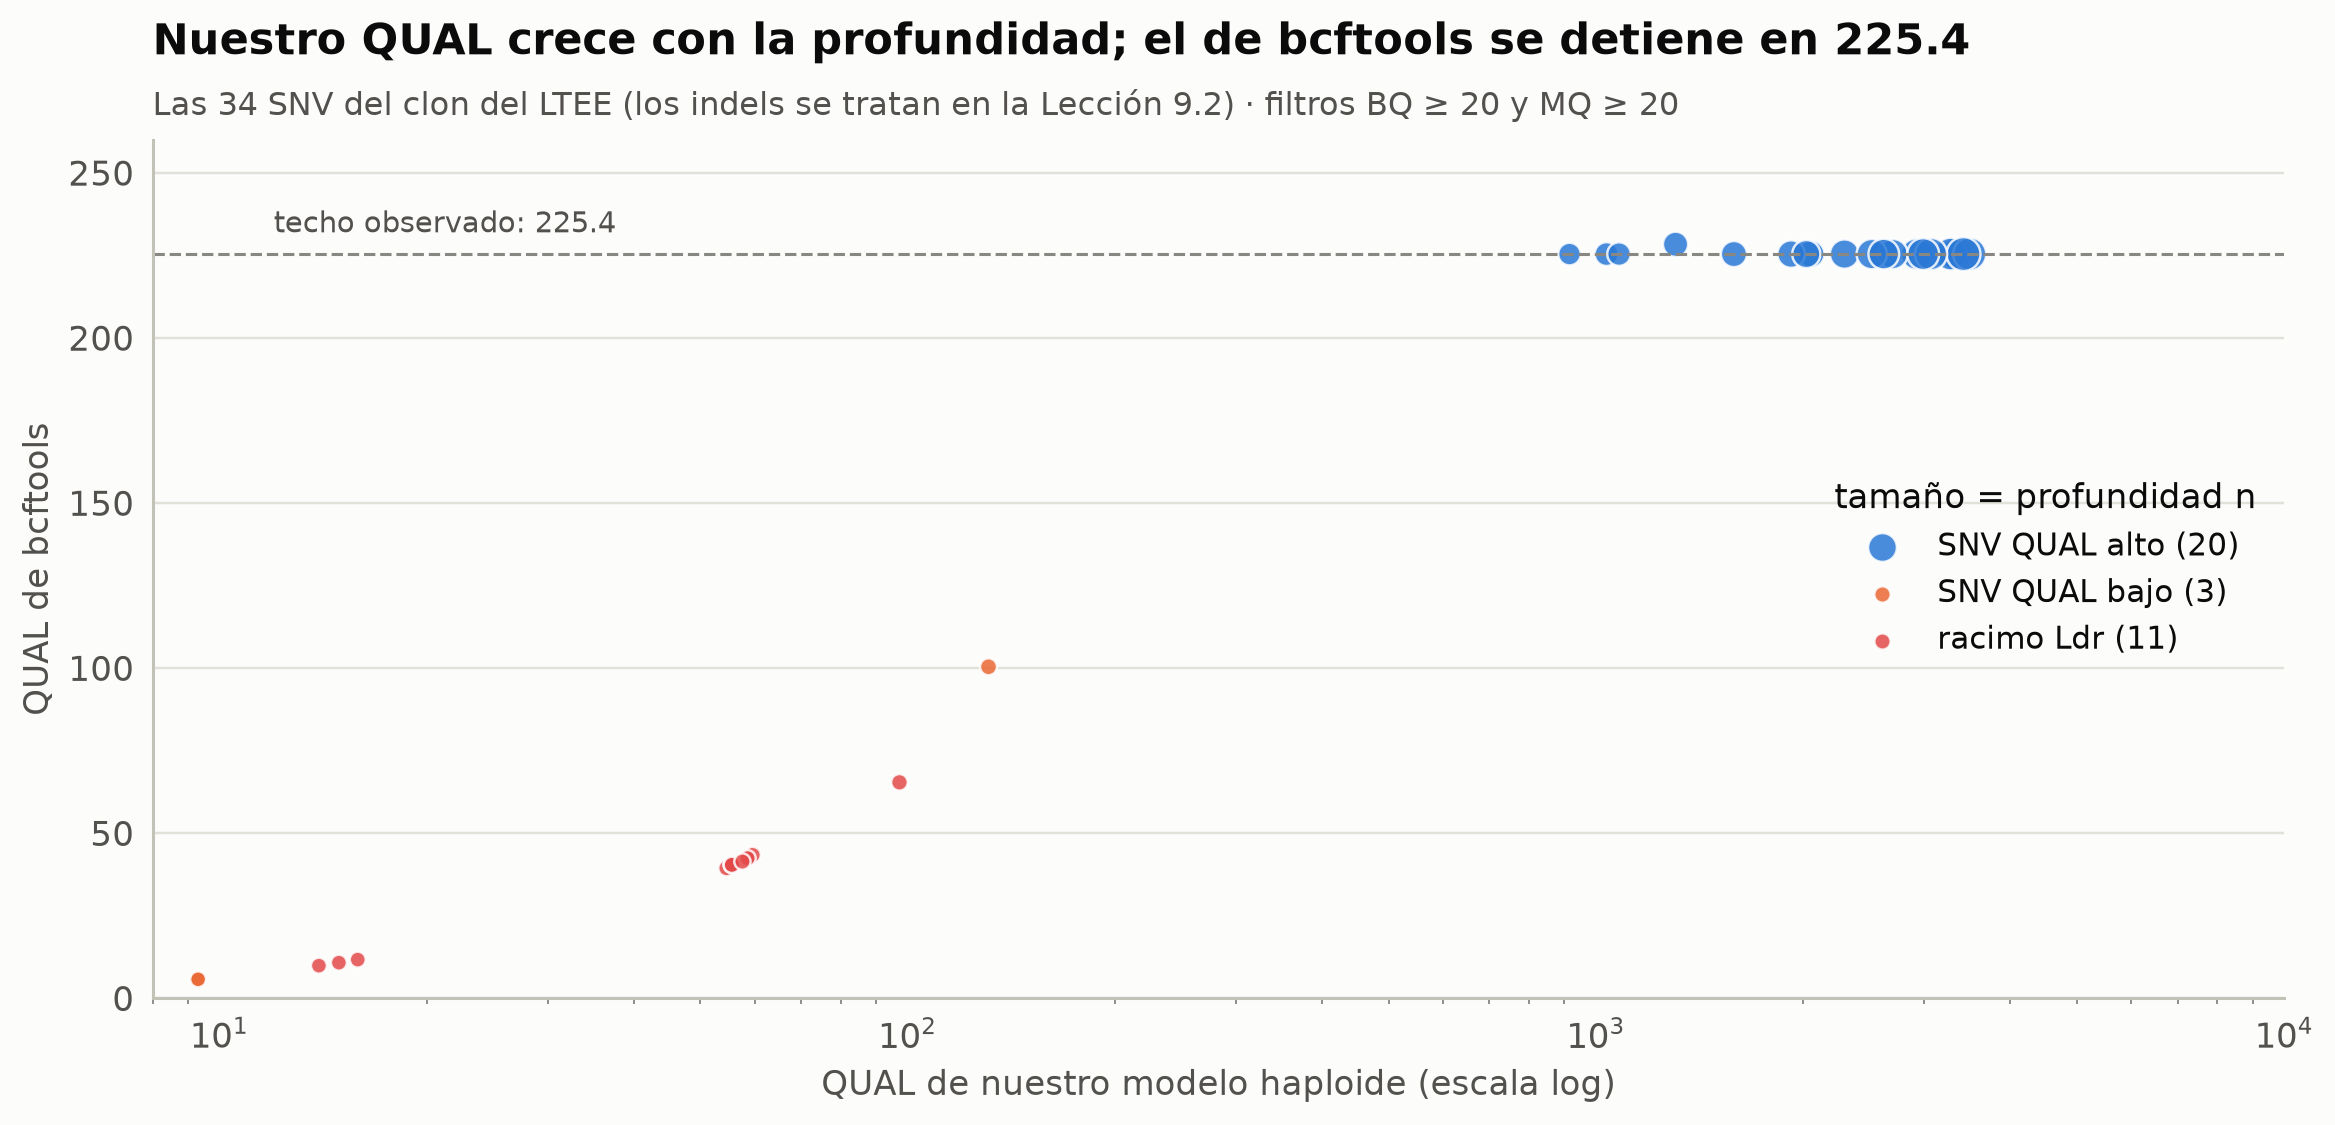

In [28]:
fig, ax = plt.subplots(figsize=(10.5, 5.0))
g_col = {"SNV QUAL alto": ec.BLUE, "racimo Ldr": ec.RED, "SNV QUAL bajo": ec.ORANGE}
for g, d in calls.groupby("grupo"):
    ax.scatter(d["QUAL_hap"], d["QUAL_bcftools"], s=26 + 1.2 * d["n"], color=g_col[g], alpha=0.85,
               edgecolor="white", lw=0.8, label=f"{g} ({len(d)})")
ax.axhline(225.417, color=ec.MUTED, ls="--", lw=1)
ax.text(12, 232, "techo observado: 225.4", fontsize=9.5, color=ec.INK_2)
ax.set_xscale("log"); ax.set_xlim(8, 1e4); ax.set_ylim(0, 260)
ax.set_xlabel("QUAL de nuestro modelo haploide (escala log)"); ax.set_ylabel("QUAL de bcftools")
ax.legend(loc="center right", frameon=False, title="tamaño = profundidad n")
ec.title(ax, "Nuestro QUAL crece con la profundidad; el de bcftools se detiene en 225.4",
         f"Las {len(calls)} SNV del clon del LTEE (los indels se tratan en la Lección 9.2) · filtros BQ ≥ 20 y MQ ≥ 20")
plt.show()

> 🔎 **Qué observamos.** Los dos modelos **ordenan** las variantes de forma parecida: el racimo Ldr y las SNV de una
> sola lectura quedan abajo en ambos. Pero `bcftools` informa **exactamente 225.417** para todas las SNV seguras,
> mientras que nuestro modelo, con 24–81 lecturas de Q30–Q41, da QUAL de ~900 a ~3 500 (cada lectura
> multiplica la evidencia por un factor de miles). Es un **techo** empírico del programa en estos datos; en la Lección 9.2 veremos de dónde sale. La moraleja
> práctica: un QUAL de 225 en `bcftools` no es "peor" que uno de 4 000; ambos dicen "certeza a efectos prácticos", y
> **los filtros deben fijarse en la escala del programa que se usa**.

### El racimo Ldr, visto de cerca

Ocho SNV en unos 100 pb (1 270 133–1 270 235), cada una sostenida por dos o tres lecturas, y tres más de una sola
lectura hasta 1 270 567, sobre una región con **tres copias casi idénticas** de un gen de toxina-antitoxina de tipo I de la familia **Ldr**. Miremos la profundidad a lo largo de la
región y las lecturas que sostienen el racimo.

Profundidad < 15× entre 1,270,129 y 1,270,657 (529 pb); mediana fuera de ese tramo: 97×
Separación entre copias Ldr consecutivas: [535, 535] pb


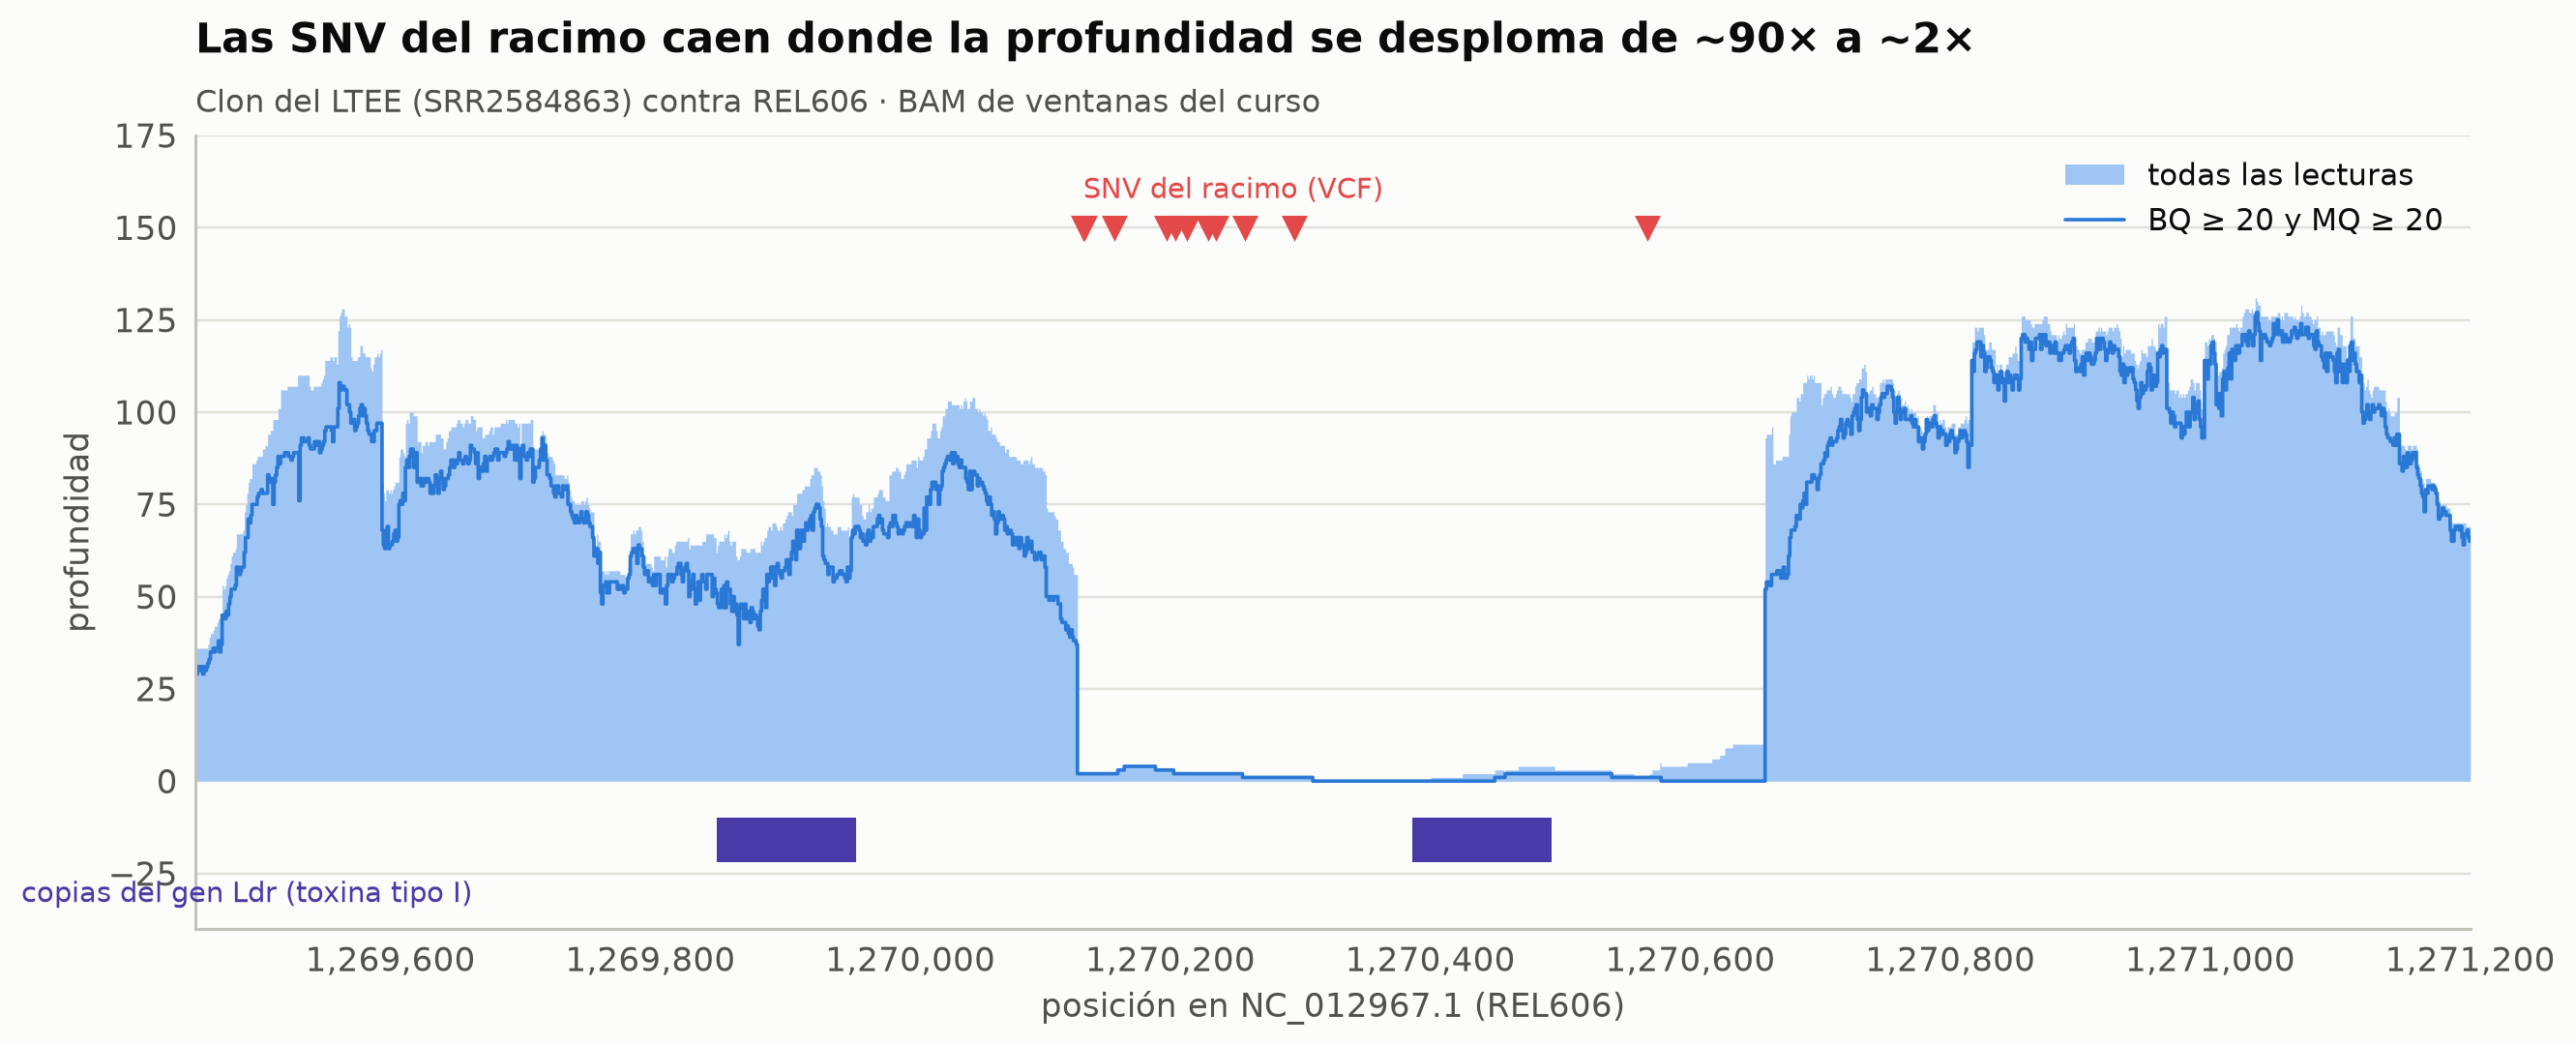

In [29]:
A0, A1 = 1_269_450, 1_271_200
if pysam is not None:
    ok_read = lambda r: r.mapping_quality >= 20 and not (r.flag & 0xF04)
    depth_all = np.array(bam.count_coverage(CHROM, A0, A1, quality_threshold=0, read_callback="nofilter")).sum(0)
    depth_f = np.array(bam.count_coverage(CHROM, A0, A1, quality_threshold=20, read_callback=ok_read)).sum(0)
    cov = pd.DataFrame({"pos": np.arange(A0 + 1, A1 + 1), "depth_all": depth_all, "depth_q20": depth_f})
else:
    cov = pd.read_csv(course_file("91_ltee_cobertura_ldr.tsv.gz"), sep="\t")
low = cov[(cov["depth_all"] < 15) & cov["pos"].between(1_270_000, 1_270_800)]
DROP = (int(low["pos"].min()), int(low["pos"].max()))
print(f"Profundidad < 15× entre {DROP[0]:,} y {DROP[1]:,} ({DROP[1] - DROP[0] + 1} pb); "
      f"mediana fuera de ese tramo: {cov.loc[~cov['pos'].between(*DROP), 'depth_all'].median():.0f}×")
print("Separación entre copias Ldr consecutivas:", np.diff(ldr["start"].values).tolist(), "pb")

fig, ax = plt.subplots(figsize=(12, 4.8))
ax.fill_between(cov["pos"], cov["depth_all"], step="mid", color=ec.SEQ_BLUE[2], lw=0, label="todas las lecturas")
ax.plot(cov["pos"], cov["depth_q20"], color=ec.BLUE, lw=1.2, drawstyle="steps-mid", label="BQ ≥ 20 y MQ ≥ 20")
for _, g in ldr.iterrows():
    ax.add_patch(Rectangle((g["start"], -22), g["end"] - g["start"], 12, color=ec.VIOLET, lw=0))
ax.text(ldr["start"].min(), -27, "copias del gen Ldr (toxina tipo I)", va="top", fontsize=9.5, color=ec.VIOLET)
clu = vcf[vcf["grupo"] == "racimo Ldr"]["pos"]
ax.plot(clu, np.full(len(clu), 150), "v", color=ec.RED, ms=7)
ax.text(clu.min(), 158, "SNV del racimo (VCF)", fontsize=9.5, color=ec.RED)
ax.set_xlim(A0, A1); ax.set_ylim(-40, 175)
ax.set_xlabel(f"posición en {CHROM} (REL606)"); ax.set_ylabel("profundidad")
ax.legend(loc="upper right", frameon=False)
ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f"{x:,.0f}"))
ec.title(ax, "Las SNV del racimo caen donde la profundidad se desploma de ~90× a ~2×",
         "Clon del LTEE (SRR2584863) contra REL606 · BAM de ventanas del curso")
plt.show()

In [30]:
if pysam is not None:
    clu_reads = []
    for r in bam.fetch(CHROM, 1_270_130, 1_270_240):
        clu_reads.append({"lectura": r.query_name, "inicio": r.reference_start + 1, "CIGAR": r.cigarstring,
                          "MAPQ": r.mapping_quality, "NM": r.get_tag("NM"), "hebra": "−" if r.is_reverse else "+"})
    display(pd.DataFrame(clu_reads))
    nm_all = [r.get_tag("NM") for r in bam.fetch(CHROM, 9_372, 10_572) if not r.is_unmapped]
    print(f"Como referencia, en la ventana de una SNV verdadera (9 972) el {np.mean(np.array(nm_all) <= 1):.0%} de las "
          f"lecturas tiene NM ≤ 1.")

,lectura,inicio,CIGAR,MAPQ,NM,hebra
0,SRR2584863.117518,1270039,150M,60,5,−
1,SRR2584863.513729,1270053,150M,60,5,−
2,SRR2584863.742064,1270160,150M,57,7,−
3,SRR2584863.494074,1270165,59S91M,50,5,−


Como referencia, en la ventana de una SNV verdadera (9 972) el 91% de las lecturas tiene NM ≤ 1.


> 🔎 **Qué observamos.** La profundidad cae de una mediana de ~97× a casi cero en un tramo de ~529 pb que contiene la tercera copia
> Ldr, y ese tramo mide casi lo mismo que la separación entre copias consecutivas (~535 pb). Lo más probable, y lo
> decimos como **hipótesis**, es que el clon haya **perdido una unidad de la repetición** (una deleción por
> recombinación entre copias directas) y que las poquísimas lecturas que aún caen ahí vengan de las **otras** copias
> Ldr: por eso cada una arrastra 5–7 desapareamientos (una lectura típica del clon tiene 0 o 1) y "fabrica" el racimo
> entero: 11 registros (8 SNV en ~100 pb con DP 2–3 + 3 de una sola lectura en el mismo hueco). Observe lo
> inquietante: su **MAPQ es 46–60**. La calidad de mapeo no las delata, porque en el genoma de
> referencia no encuentran una ubicación alternativa mejor.

**Lección para el modelo.** La ecuación 09-lik supone lecturas **independientes** y **bien colocadas**. Aquí ambas
cosas fallan: las lecturas no son testigos independientes de esa posición, sino testigos de **otra** copia. Ningún
ajuste de $\theta$ o de las calidades lo arregla; lo detectan señales que el modelo de la columna no mira:
profundidad anómala respecto de los vecinos, muchos desapareamientos agrupados en las mismas lecturas y sesgo de
hebra. Son los filtros de la Lección 9.2.

### Dos columnas reales, lectura a lectura

Dibujemos, al estilo IGV, las lecturas alrededor de una mutación verdadera y de una SNV del racimo. Sólo se colorean
las bases que difieren de REL606.

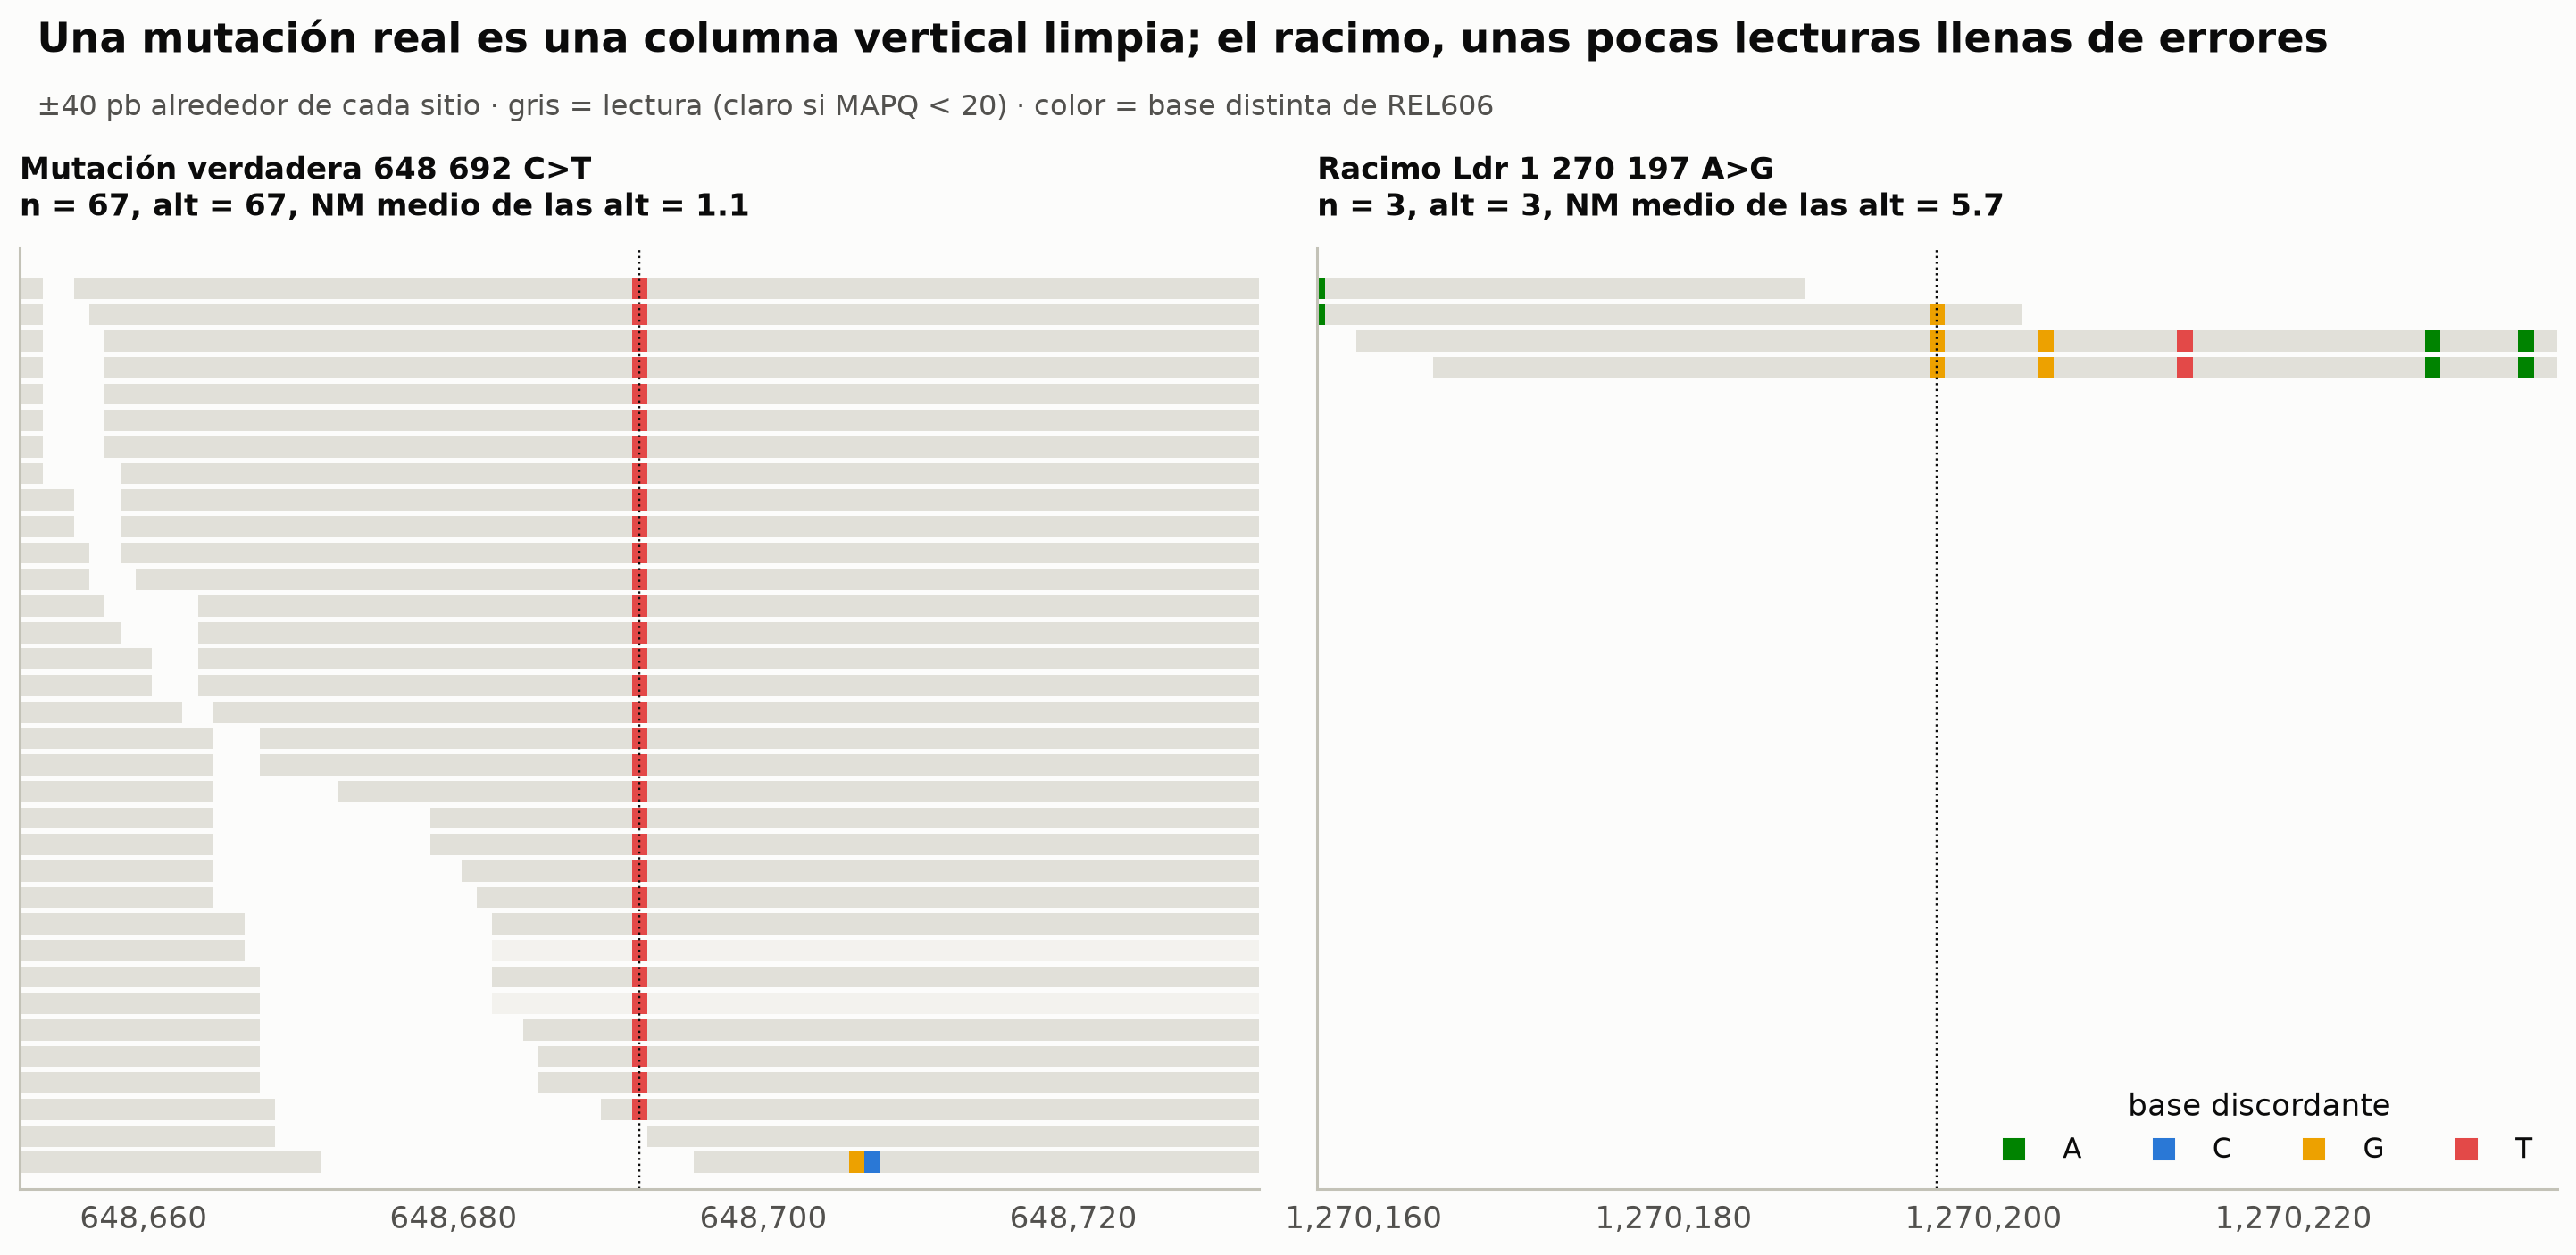

In [31]:
genome = "".join(l.strip() for l in gzip.open(course_file("NC_012967.1.fasta.gz"), "rt") if not l.startswith(">")).upper()

def draw_igv(ax, pos, half=40, max_rows=34):
    """Lecturas alrededor de pos (1-based): barras grises (más claras si MAPQ < 20) y bases discordantes coloreadas."""
    lo, hi = pos - half, pos + half
    reads = sorted((r for r in bam.fetch(CHROM, lo - 1, hi) if not (r.flag & 0xF04)), key=lambda r: r.reference_start)
    row_end, placed = [], []
    for r in reads:                                           # empaquetado voraz en filas (Lección 7.3)
        for i, e in enumerate(row_end):
            if r.reference_start > e + 1:
                row_end[i] = r.reference_end; placed.append((i, r)); break
        else:
            if len(row_end) < max_rows:
                row_end.append(r.reference_end); placed.append((len(row_end) - 1, r))
    for y, r in placed:
        s, e = max(r.reference_start, lo - 1), min(r.reference_end, hi)
        ax.add_patch(Rectangle((s + 0.5, -y - 0.4), e - s, 0.8, color=ec.GRID if r.mapping_quality >= 20 else "#f3f2ee", lw=0))
        for qp, rp in r.get_aligned_pairs(matches_only=True):
            if lo - 1 <= rp < hi:
                b = r.query_sequence[qp]
                if b != genome[rp]:
                    ax.add_patch(Rectangle((rp + 0.5, -y - 0.4), 1, 0.8, color=ec.NUC_COLORS.get(b, ec.MUTED), lw=0))
    ax.axvline(pos, color=ec.INK, lw=0.8, ls=":")
    ax.set_xlim(lo, hi); ax.set_ylim(-max_rows, 1.5); ax.set_yticks([])
    ax.xaxis.set_major_locator(plt.MaxNLocator(4))
    ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f"{x:,.0f}"))

if pysam is not None:
    fig, axs = plt.subplots(1, 2, figsize=(13, 5.6))
    for ax, (p, lab) in zip(axs, ((648_692, "Mutación verdadera 648 692 C>T"), (1_270_197, "Racimo Ldr 1 270 197 A>G"))):
        draw_igv(ax, p)
        row = calls[calls["pos"] == p].iloc[0]
        ax.set_title(f"{lab}\nn = {row['n']}, alt = {row['k_alt']}, NM medio de las alt = {row['NM_alt']:.1f}",
                     loc="left", fontsize=11)
    for b in "ACGT":
        axs[1].plot([], [], "s", color=ec.NUC_COLORS[b], label=b)
    axs[1].legend(ncol=4, loc="lower right", frameon=False, title="base discordante")
    ec.fig_title(fig, "Una mutación real es una columna vertical limpia; el racimo, unas pocas lecturas llenas de errores",
                 "±40 pb alrededor de cada sitio · gris = lectura (claro si MAPQ < 20) · color = base distinta de REL606")
    plt.show()

> 🔎 **Qué observamos.** A la izquierda, decenas de lecturas y una sola columna coloreada: la mutación está en todas
> las moléculas del clon, y el resto de la ventana es limpio. A la derecha, dos o tres lecturas solitarias salpicadas
> de desapareamientos en varias posiciones: el patrón típico de lecturas que provienen de una copia parálogo
> ligeramente distinta.

### ¿Hay "heterocigotos" en un clon haploide?

Si el clon es haploide y clonal, ninguna columna bien mapeada debería mostrar una mezcla sustancial de dos bases.
Comprobémoslo en **todas** las posiciones de las ventanas con al menos 10 lecturas: calculamos la fracción de la base
minoritaria.

33,529 columnas con ≥ 10 lecturas · fracción minoritaria > 0.2 en 0 · > 0.05 en 7 · máxima 0.077


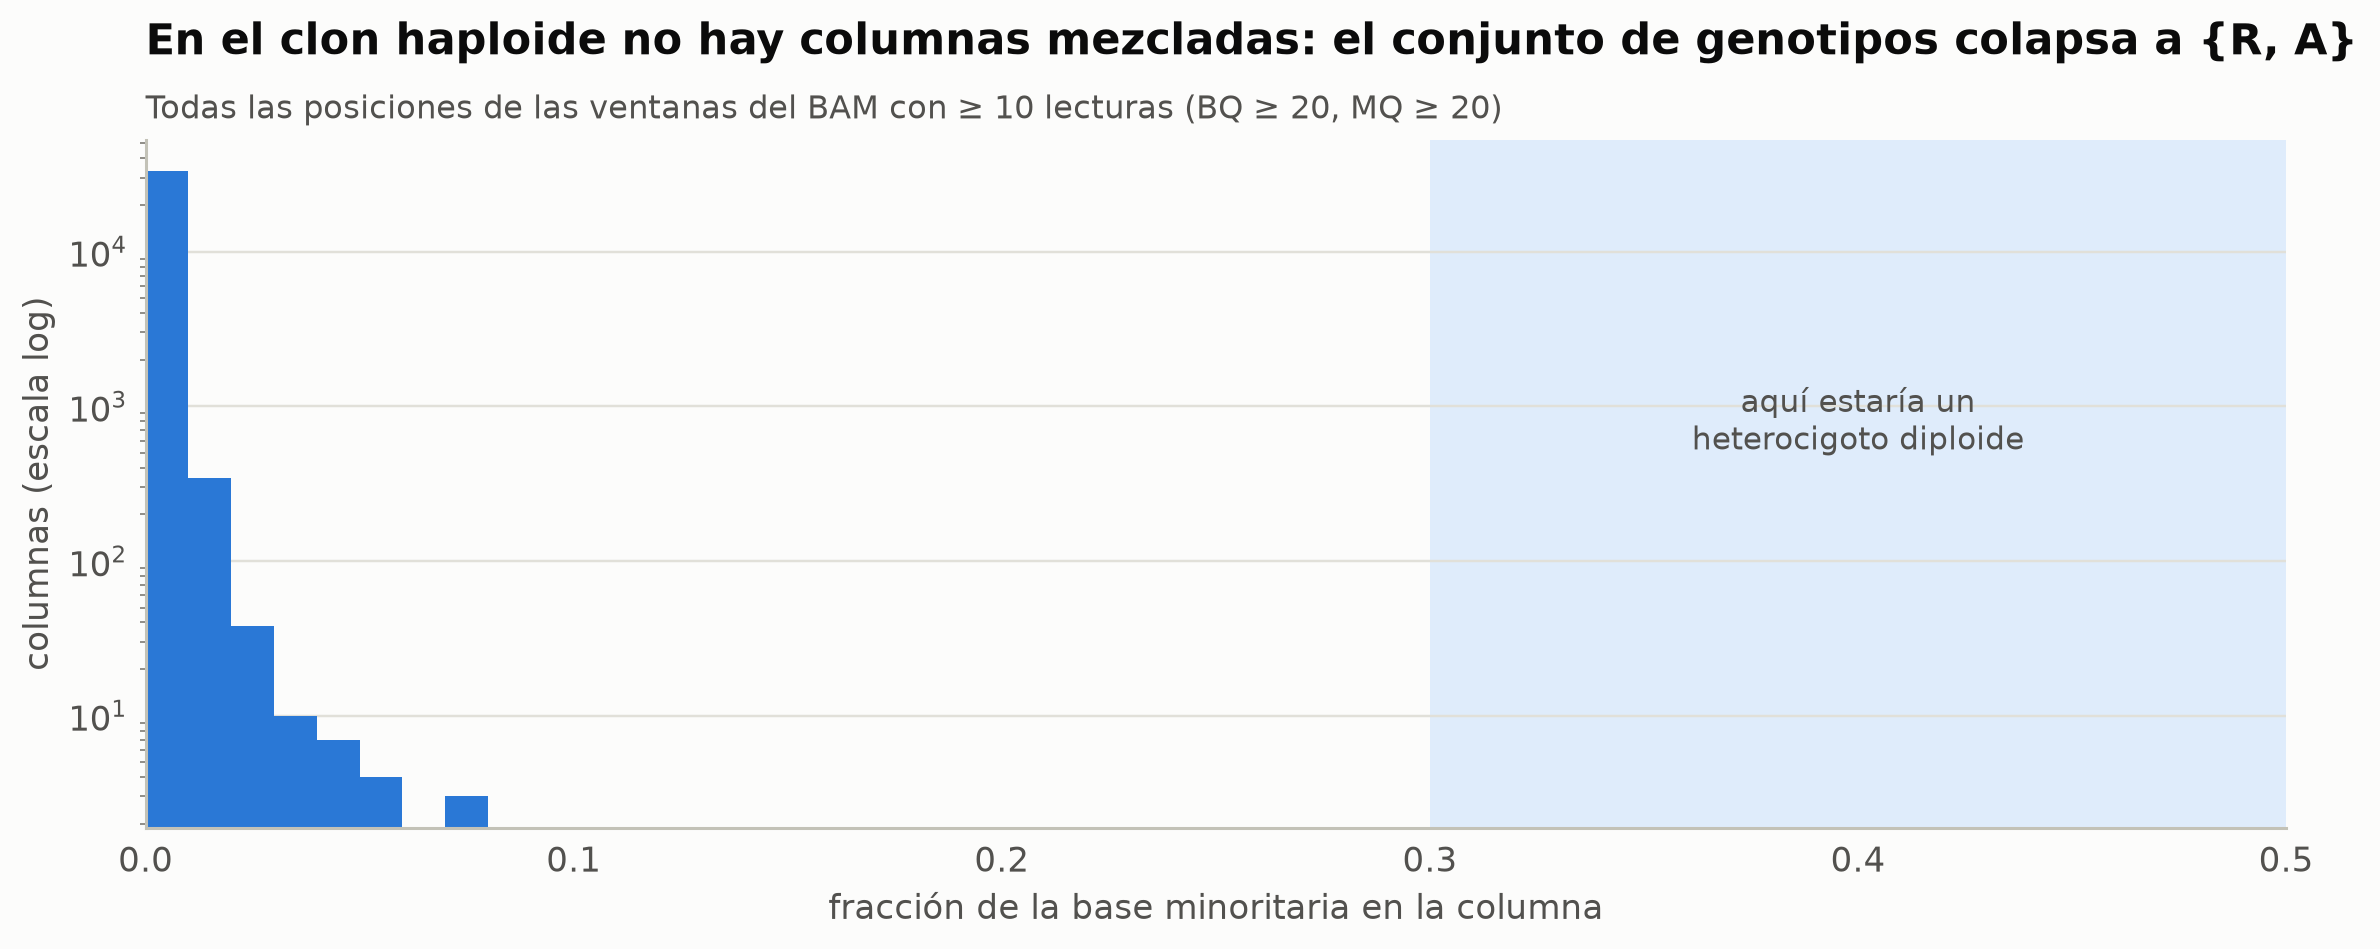

In [32]:
if pysam is not None:
    wins = []
    for p in vcf["pos"]:
        a, b = p - 600, p + 600
        if wins and a <= wins[-1][1]:
            wins[-1][1] = max(wins[-1][1], b)
        else:
            wins.append([a, b])
    minor = []
    for a, b in wins:
        cc = np.array(bam.count_coverage(CHROM, a, b, quality_threshold=20, read_callback=ok_read))
        t = cc.sum(0); ok = t >= 10
        minor.append(1 - cc.max(0)[ok] / t[ok])
    minor = np.concatenate(minor)
    print(f"{len(minor):,} columnas con ≥ 10 lecturas · fracción minoritaria > 0.2 en {np.sum(minor > 0.2)} · "
          f"> 0.05 en {np.sum(minor > 0.05)} · máxima {minor.max():.3f}")
    fig, ax = plt.subplots(figsize=(10.5, 4.2))
    ax.hist(minor, bins=np.linspace(0, 0.5, 51), color=ec.BLUE)
    ax.axvspan(0.3, 0.5, color=ec.SEQ_BLUE[0], alpha=0.6, lw=0, zorder=0)
    ax.set_yscale("log"); ax.set_xlim(0, 0.5)
    ax.text(0.4, 0.55, "aquí estaría un\nheterocigoto diploide", transform=ax.get_xaxis_transform(),
            ha="center", fontsize=10, color=ec.INK_2)
    ax.set_xlabel("fracción de la base minoritaria en la columna"); ax.set_ylabel("columnas (escala log)")
    ec.title(ax, "En el clon haploide no hay columnas mezcladas: el conjunto de genotipos colapsa a {R, A}",
             "Todas las posiciones de las ventanas del BAM con ≥ 10 lecturas (BQ ≥ 20, MQ ≥ 20)")
    plt.show()

> 🔎 **Qué observamos.** Decenas de miles de columnas, y casi todas tienen fracción minoritaria 0 o de unas pocas
> centésimas (errores de secuenciación sueltos). La zona de 0.3–0.5, donde vivirían los heterocigotos de un diploide,
> está vacía. Por eso `bcftools call --ploidy 1` es el modelo correcto aquí; en un tumor (mezcla de clones) o en una
> población bacteriana (mezcla de linajes) volverían a aparecer fracciones intermedias, y harían falta modelos de
> frecuencia alélica en vez de genotipos.

### 🎛️ Las 34 SNV reales, en un solo gráfico

Pase el ratón por cada punto: verá la columna completa (lecturas de referencia, alternativas y otras), la hebra, la
MAPQ media, los desapareamientos medios de las lecturas alternativas y los llamados haploide y diploide.

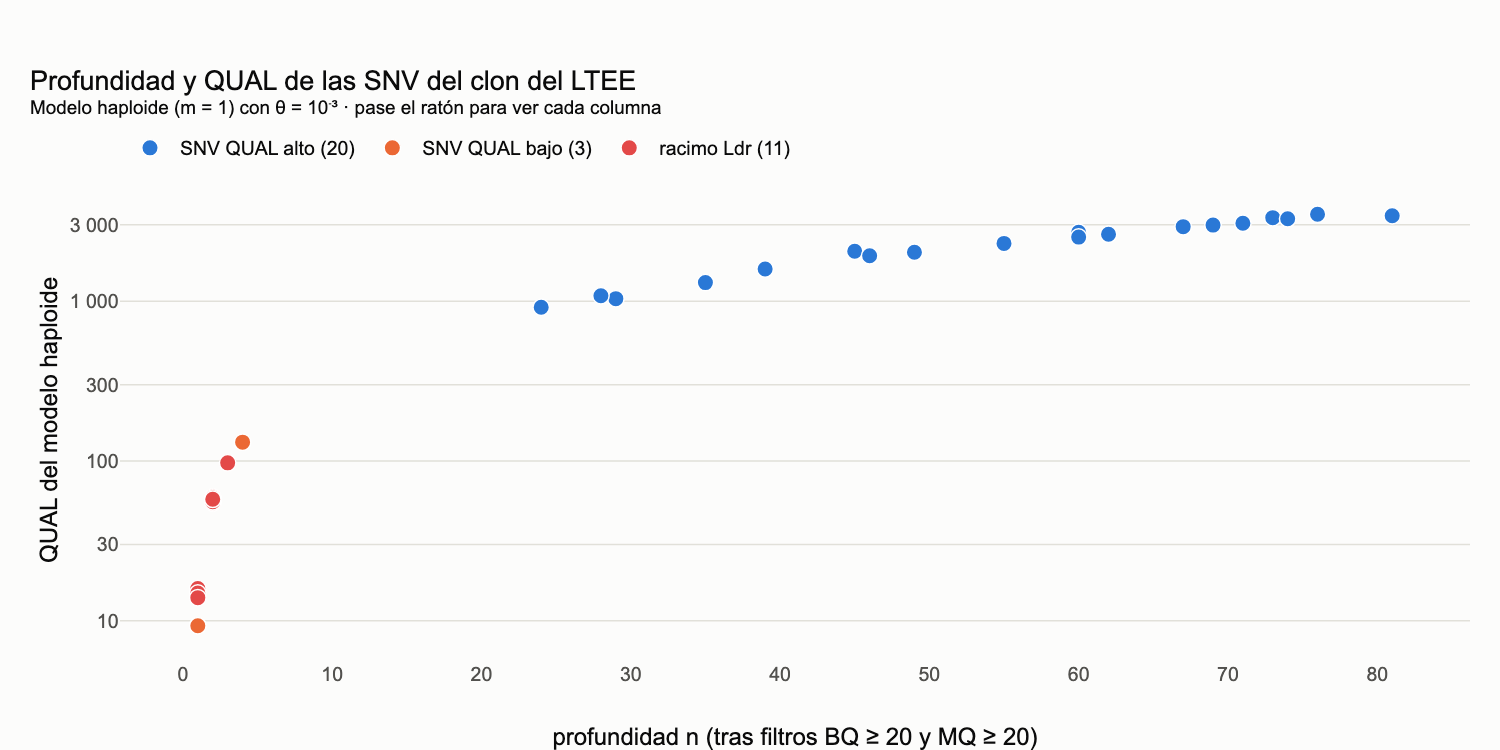

In [33]:
fig = go.Figure()
for g, d in calls.groupby("grupo"):
    hover = [f"<b>{r.pos:,} {r.cambio}</b> · {g}<br>n = {r.n} · alt = {r.k_alt} ({r.alt_rev} en hebra −) · otras = {r.otras}"
             f"<br>MAPQ medio = {r.MQ_medio:.0f} · NM medio de las alt = {r.NM_alt:.1f}"
             f"<br>haploide: <b>{r.haploide}</b>, QUAL = {r.QUAL_hap:.0f}<br>diploide: {r.diploide}, PL = {r.PL_dip}"
             f"<br>QUAL de bcftools = {r.QUAL_bcftools:.1f}" for r in d.itertuples()]
    fig.add_trace(go.Scatter(x=d["n"], y=d["QUAL_hap"], mode="markers", name=f"{g} ({len(d)})",
                             marker=dict(size=11, color=g_col[g], line=dict(width=1, color="white")),
                             hovertext=hover, hoverinfo="text"))
fig.update_layout(height=500, xaxis_title="profundidad n (tras filtros BQ ≥ 20 y MQ ≥ 20)",
                  yaxis_title="QUAL del modelo haploide", yaxis_type="log",
                  yaxis_tickvals=[10, 30, 100, 300, 1000, 3000], yaxis_ticktext=["10", "30", "100", "300", "1 000", "3 000"],
                  title="Profundidad y QUAL de las SNV del clon del LTEE<br><sup>Modelo haploide (m = 1) con θ = 10⁻³ · "
                        "pase el ratón para ver cada columna</sup>",
                  legend=dict(orientation="h", yanchor="bottom", y=1.02, x=0), margin=dict(t=120, l=80, r=20, b=60))
fig.show()

> 🔎 **Qué observamos.** En las SNV verdaderas QUAL crece en proporción a $n$: cada lectura de buena calidad suma
> unas 40–45 unidades (QUAL/n ≈ 42 en 9 972 y ≈ 46 en 2 999 330), porque todas las lecturas están de acuerdo. El
> racimo Ldr y las SNV de una lectura se quedan en la esquina inferior izquierda. En la práctica, la **profundidad
> anómala** (muy por debajo de la media del genoma) es el primer filtro que las separaría, y así lo haremos en la
> Lección 9.2.

## 12. Más allá de la columna: HaplotypeCaller y DeepVariant

El modelo de la ecuación 09-lik mira **cada posición por separado**. El racimo Ldr acaba de mostrar su límite: una
columna no sabe nada de sus vecinas ni de dónde vino cada lectura. Los llamadores de última generación han ido más
allá en dos direcciones.

**Reensamblaje local (GATK HaplotypeCaller).** El *Genome Analysis Toolkit* nació como un marco de programación para
procesar datos de secuenciación a escala (McKenna et al., 2010), y DePristo et al. (2011) lo convirtieron en un flujo
completo de descubrimiento de variantes con recalibración de calidades de base (BQSR), realineamiento local y una
recalibración de la calidad de las variantes (VQSR) basada en un modelo de mezcla gaussiana entrenado con sitios
conocidos. Su sucesor, `HaplotypeCaller`, cambia el paradigma:

1. detecta **regiones activas** con indicios de variación;
2. **reensambla** localmente las lecturas de cada región con un **grafo de De Bruijn** (Módulo 8) para proponer
   **haplotipos** candidatos;
3. calcula con un **HMM de pares** la verosimilitud $P(\text{lectura}\mid\text{haplotipo})$;
4. sólo entonces obtiene las verosimilitudes de los genotipos, marginalizando sobre los haplotipos.

Así, SNV e *indels* cercanos se evalúan **juntos** y los errores del alineador pesan mucho menos (el problema que
BAQ sólo mitigaba). Para cohortes enormes, Poplin et al. (2017) combinaron HaplotypeCaller con un **modelo de
confianza de referencia**: las verosimilitudes se calculan por muestra, también en los sitios donde la muestra parece
idéntica a la referencia, y se guardan en un **GVCF** con bloques de referencia y un alelo genérico `<NON_REF>`; el
genotipado conjunto se hace después sin volver a leer los BAM. Así llamaron más de 90 000 exomas del consorcio ExAC.
Esto evita el llamado "problema $N+1$": añadir una muestra no obliga a repetir todo el análisis.

**Aprendizaje profundo (DeepVariant).** Poplin et al. (2018) dieron un paso más radical: en lugar de **escribir** el
modelo de error, lo **aprenden**. DeepVariant convierte el *pileup* alrededor de cada candidato en una **imagen** de
varios canales (base, calidad, hebra, MAPQ, soporte del alelo), muy parecida a la vista estilo IGV que dibujamos en la
sección 11, y una red neuronal convolucional devuelve directamente las probabilidades de los tres genotipos.
Entrenado con genomas cuyo genotipo verdadero es conocido, supera a los métodos estadísticos clásicos y se adapta a
otras tecnologías de secuenciación con sólo reentrenarlo. Fíjese en que la **salida** sigue siendo la misma que la de
esta lección: tres probabilidades, PL, GQ.

| | Modelo de columna (bcftools) | HaplotypeCaller | DeepVariant |
|---|---|---|---|
| Unidad de análisis | una posición | una región activa (haplotipos) | una ventana del *pileup* como imagen |
| Modelo de error | explícito (Phred, BAQ, MAPQ) | explícito (HMM de pares) | aprendido de datos de verdad |
| Fortaleza | rápido, transparente | *indels* y variantes agrupadas | precisión, adaptable |
| Debilidad | errores del alineador, repeticiones | coste computacional | depende del entrenamiento; caja negra |

> 📜 **Un poco de historia: de contar alelos a modelar la incertidumbre.** Los primeros estudios con NGS llamaban
> variantes con reglas simples, del tipo "al menos tres lecturas alternativas y un 20 % de fracción alélica".
> Nielsen et al. (2011) mostraron que esas reglas desperdician información y no dan ninguna medida de incertidumbre,
> sobre todo a cobertura baja o media, y abogaron por calcular verosimilitudes de genotipos y propagarlas a los
> análisis posteriores. Ese mismo año se publicaron los marcos estadísticos de SAMtools/BCFtools (Li, 2011) y de GATK
> (DePristo et al., 2011).

## 13. 🏋️ Ejercicios

**Ejercicio 1 (a mano y con código).** Una columna muestra `G`(Q20), `G`(Q20) y `A`(Q30), con $R=$`A`, $A=$`G`.
(a) Calcule a mano $P(b\mid G)$ de cada lectura para $RR$, $RA$ y $AA$. (b) Obtenga $L(G)$, el vector PL y, con
$\theta=10^{-3}$, la posterior, QUAL y GQ. (c) Compruebe con `llamar` del libro.

**Ejercicio 2 (la *a priori* como perilla).** Para la columna 8, ¿a partir de qué valor de $\theta$ el genotipo de
máxima posterior deja de ser $RA$? Grafique $P(RA\mid D)$ frente a $\theta\in[10^{-12}, 10^{-1}]$.

**Ejercicio 3 (haploide).** En un clon bacteriano, $n$ lecturas Q30 muestran todas el alelo alternativo. Con
$P(A)=\theta=10^{-3}$, derive la fórmula de QUAL en función de $n$ y diga cuántas lecturas hacen falta para
$\mathrm{QUAL}\ge 30$ y $\mathrm{QUAL}\ge 100$.

**Ejercicio 4 (llamada conjunta con un artefacto).** Añada a las ocho muestras de la sección 10 otras cuatro, M9–M12,
cada una con 0 lecturas alternativas de 10. ¿Cómo cambian $\hat\psi$ y la posterior de M1? Después, en lugar de
eso, suponga que un artefacto sistemático añade **una** lectura alternativa Q20 a las ocho muestras originales:
¿qué frecuencia estima el EM? ¿Por qué esto ilustra la advertencia de la sección 10?

**Ejercicio 5 (datos reales).** La SNV `4 017 756 C>T` del clon tiene QUAL 100 en `bcftools`. Use `site_reads`, la
profundidad de los alrededores (`bam.count_coverage`) y la tabla de genes (`feat`) para decidir si parece una
mutación verdadera o un artefacto. Justifique con al menos tres señales.

In [34]:
#@title 🔑 Solución — Ejercicio 1 { display-mode: "form" }
col = [("G", 20), ("G", 20), ("A", 30)]
for b, q in col:
    print(f"{b} Q{q}: " + "  ".join(f"P|{g} = {p_base_geno(b, GENO[g], q):.5f}" for g in GENO))
c = call_site(col)
print("L =", {g: f"{lik(col, GENO[g]):.3e}" for g in GENO})
print("PL =", c["pl"], "· posterior =", {g: f"{v:.4f}" for g, v in c["post"].items()},
      f"· QUAL = {c['qual']:.1f} · GQ = {c['gq']:.1f}")
print("llamar():", llamar("GGA", [20, 20, 30], "A", "G"))
# Las dos G de Q20 aportan un factor ≈ (0.5/0.0033)² ≈ 2.3·10⁴ a favor de RA frente a RR, suficiente para
# vencer la a priori (≈ 1000); la A de Q30 descarta AA (factor 0.00033).

G Q20: P|RR = 0.00333  P|RA = 0.49667  P|AA = 0.99000
G Q20: P|RR = 0.00333  P|RA = 0.49667  P|AA = 0.99000
A Q30: P|RR = 0.99900  P|RA = 0.49967  P|AA = 0.00033
L = {'RR': '1.110e-05', 'RA': '1.233e-01', 'AA': '3.267e-04'}
PL = {'RR': 40, 'RA': 0, 'AA': 26} · posterior = {'RR': '0.0824', 'RA': '0.9164', 'AA': '0.0012'} · QUAL = 10.8 · GQ = 10.8
llamar(): ('0/1', {'0/0': 40, '0/1': 0, '1/1': 26}, 10.8, 10.8)


P(RA|D) ≥ 0.5 a partir de θ ≈ 2.6e-07


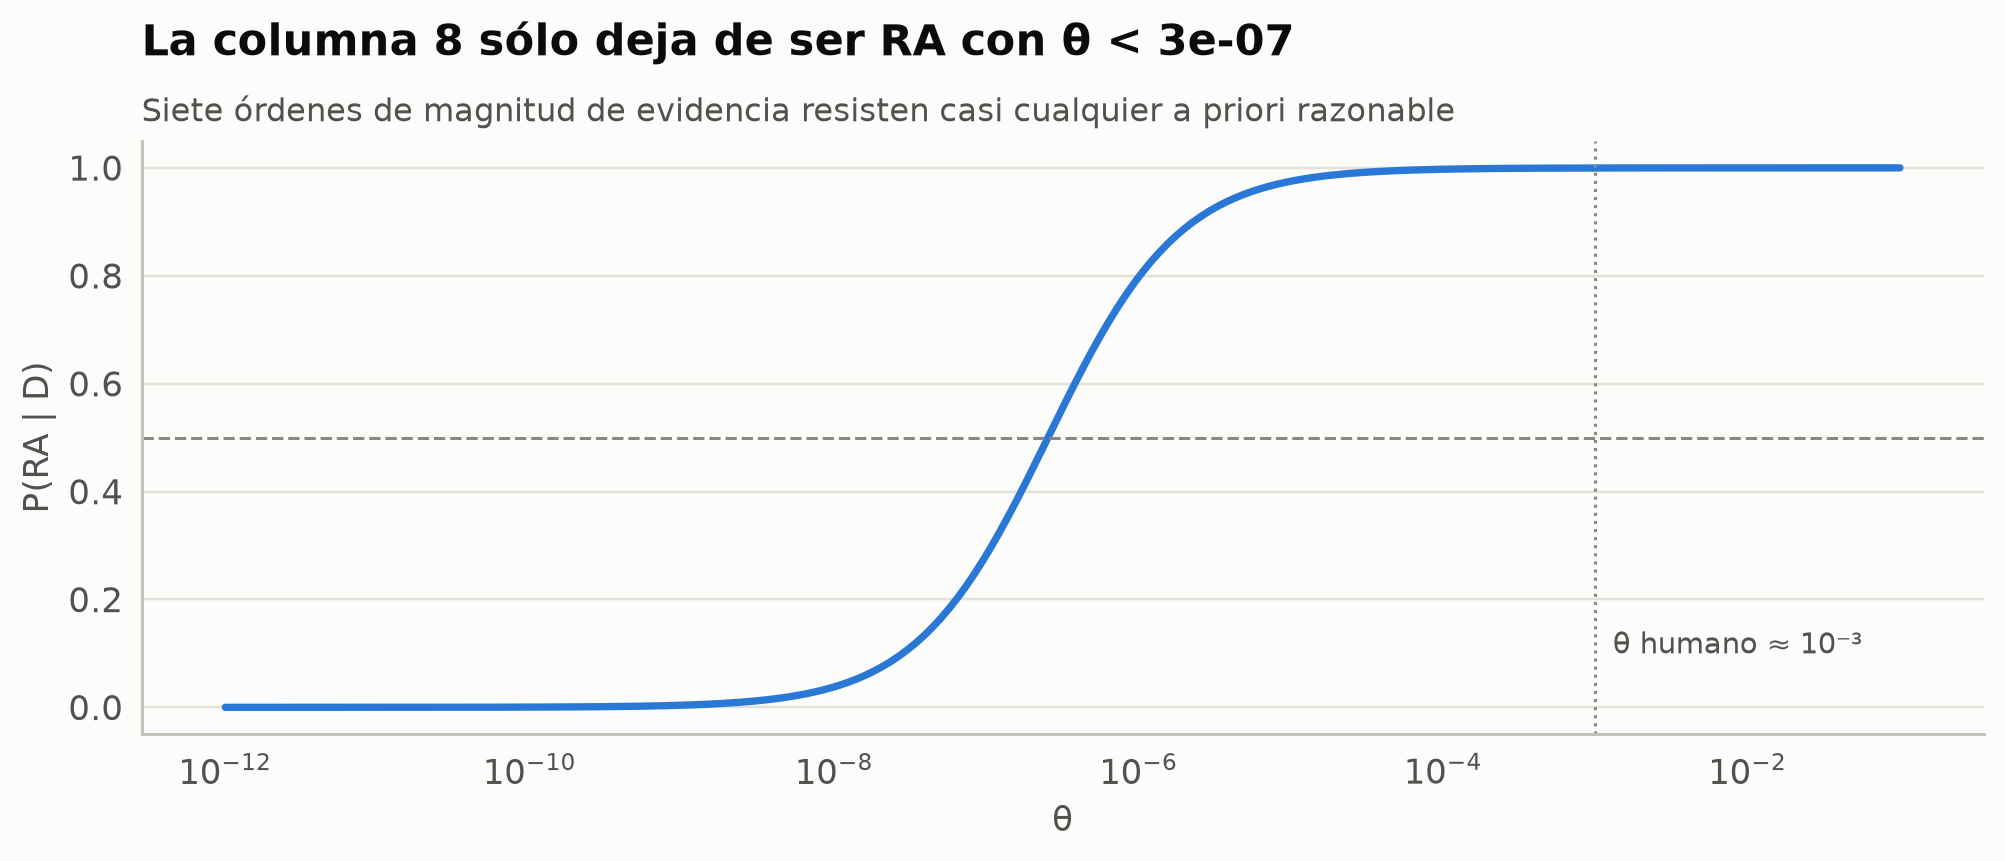

In [35]:
#@title 🔑 Solución — Ejercicio 2 { display-mode: "form" }
thetas = np.logspace(-12, -1, 200)
p_ra = [call_site(D8, theta=t)["post"]["RA"] for t in thetas]
flip = thetas[np.argmax(np.array(p_ra) >= 0.5)]
print(f"P(RA|D) ≥ 0.5 a partir de θ ≈ {flip:.1e}")
fig, ax = plt.subplots(figsize=(9, 3.8))
ax.semilogx(thetas, p_ra, color=ec.BLUE, lw=2.4)
ax.axhline(0.5, color=ec.MUTED, ls="--", lw=1); ax.axvline(1e-3, color=ec.MUTED, ls=":", lw=1)
ax.text(1.3e-3, 0.1, "θ humano ≈ 10⁻³", fontsize=9.5, color=ec.INK_2)
ax.set_xlabel("θ"); ax.set_ylabel("P(RA | D)")
ec.title(ax, f"La columna 8 sólo deja de ser RA con θ < {flip:.0e}",
         "Siete órdenes de magnitud de evidencia resisten casi cualquier a priori razonable")
plt.show()
# L(RA)/L(RR) ≈ 4·10⁶, así que hace falta θ ≈ 1/(4·10⁶) ≈ 2.5·10⁻⁷ para empatar.

In [36]:
#@title 🔑 Solución — Ejercicio 3 { display-mode: "form" }
# P(R|D) = (1−θ)(ε/3)^n / [(1−θ)(ε/3)^n + θ(1−ε)^n]  ⇒  QUAL ≈ 10·n·log10((1−ε)/(ε/3)) + 10·log10(θ/(1−θ))
e = 1e-3
per_read = 10 * math.log10((1 - e) / (e / 3))
offset = 10 * math.log10(1e-3 / (1 - 1e-3))
print(f"cada lectura Q30 suma {per_read:.1f} unidades; la a priori resta {-offset:.1f}")
for target in (30, 100):
    n = math.ceil((target - offset) / per_read)
    c = call_site([("G", 30)] * n, genos={"R": ("A", "A"), "A": ("G", "G")}, prior={"R": 1 - 1e-3, "A": 1e-3})
    print(f"QUAL ≥ {target}: n = {n} lecturas (QUAL = {c['qual']:.1f})")

cada lectura Q30 suma 34.8 unidades; la a priori resta 30.0
QUAL ≥ 30: n = 2 lecturas (QUAL = 39.5)
QUAL ≥ 100: n = 4 lecturas (QUAL = 109.1)


In [37]:
#@title 🔑 Solución — Ejercicio 4 { display-mode: "form" }
def em_generic(samples, psi0=0.5, q=20, tol=1e-10):
    e = 10 ** (-q / 10)
    L = {s: np.array([lik_bial(k, n, h, e) for h in (0, 1, 2)]) for s, (k, n) in samples.items()}
    psi = psi0
    for it in range(500):
        post = {s: L[s] * hw(psi) / (L[s] * hw(psi)).sum() for s in samples}
        new = sum((post[s] * H).sum() for s in samples) / (2 * len(samples))
        if abs(new - psi) < tol:
            return new, post
        psi = new
    return psi, post

more = {**SAMPLES, **{f"M{i}": (0, 10) for i in range(9, 13)}}
psi_m, post_m = em_generic(more)
print(f"Con M9–M12 (0/10): ψ̂ = {psi_m:.3f} · M1: P(RA) = {post_m['M1'][1]:.3f}")
art = {s: (k + 1, n + 1) for s, (k, n) in SAMPLES.items()}
psi_a, post_a = em_generic(art)
print(f"Con una lectura artefactual por muestra: ψ̂ = {psi_a:.3f} (antes {psi_hat:.3f})")
# Cuatro muestras bien cubiertas sin el alelo bajan la frecuencia y, con ella, la confianza en M1.
# El artefacto, en cambio, empuja ψ̂ hacia arriba: el EM no distingue un error sistemático compartido de una
# variante común; lo "refuerza". Por eso se filtra por sesgo de hebra, posición en la lectura, MQ, etc. (Lección 9.2).

Con M9–M12 (0/10): ψ̂ = 0.210 · M1: P(RA) = 0.871
Con una lectura artefactual por muestra: ψ̂ = 0.491 (antes 0.331)


In [38]:
#@title 🔑 Solución — Ejercicio 5 { display-mode: "form" }
P5 = 4_017_756
if pysam is not None:
    r5 = pd.DataFrame(site_reads(bam, P5, min_bq=0, min_mq=0))
    print(r5[["base", "bq", "mq", "reverse", "nm"]].to_string(index=False))
    d5 = np.array(bam.count_coverage(CHROM, P5 - 600, P5 + 600, quality_threshold=0, read_callback="nofilter")).sum(0)
    print(f"profundidad en el sitio: {d5[600]} · mediana de la ventana ±600 pb: {np.median(d5):.0f}")
over = feat[(feat["start"] <= P5) & (feat["end"] >= P5)]
print("gen que contiene el sitio:", over[["type", "locus_tag", "product", "start", "end"]].values.tolist())
print("copias anotadas de ARNr 23S en REL606:", int(((feat["type"] == "rRNA") & (feat["product"] == "23S ribosomal RNA")).sum()))
# Señales: (1) la profundidad cae de ~100× a unas pocas lecturas justo en el sitio; (2) cae dentro de un gen de
# ARNr 23S, repetido en varios operones del genoma (mapeo ambiguo); (3) MAPQ irregulares (38–60, cuando lo típico
# en el clon es 60); (4) hay otra "SNV" de una sola lectura a 5 pb (4 017 761). Conclusión prudente: sospechosa de
# artefacto de mapeo entre copias del operón ribosómico, no una mutación confirmada; se verificaría con lecturas
# largas o con PCR y Sanger.

base  bq  mq  reverse  nm
   T  35  60    False   1
   T  33  56    False   1
   T  37  38     True   1
   T  37  53     True   2
profundidad en el sitio: 6 · mediana de la ventana ±600 pb: 100
gen que contiene el sitio: [['rRNA', 'ECB_RS19815', '23S ribosomal RNA', 4015892, 4018795]]
copias anotadas de ARNr 23S en REL606: 7


## 📌 Resumen

* Una **variante** es una diferencia respecto de un sistema de coordenadas (la referencia). SNV e *indels* se ven en
  la **columna de bases**; las variantes estructurales, en la geometría de los alineamientos.
* Cada base aporta $P(b\mid a)=1-\varepsilon$ o $\varepsilon/3$ (09-pbase); en un diploide se promedian los dos
  cromosomas (09-pbaseG). La **asimetría** $\tfrac12$ frente a $\varepsilon/3$ es la fuente de toda la evidencia.
* La **verosimilitud** $L(G)=\prod_i P(b_i\mid G)$ (09-lik) no es la probabilidad del genotipo. Para la columna 8:
  $L=(3.66\times10^{-9},\ 1.44\times10^{-2},\ 3.33\times10^{-10})$ y **PL = (66, 0, 76)** (09-pl).
* La forma de **Li** (09-li) vale para cualquier ploidía $m$; con $m=1$ (bacterias) los genotipos colapsan a $\{R, A\}$.
* La ***a priori*** $P(RA)=\theta$, $P(AA)=\theta/2$ (09-prior) y **Bayes** (09-post) dan la posterior;
  **QUAL** $=-10\log_{10}P(RR\mid D)$ mide si hay variante y **GQ** si el genotipo es el correcto (09-qual). Columna 8:
  $P(RA\mid D)=0.99975$, QUAL ≈ GQ ≈ 36, frente a 66 de la GQ "sin *a priori*".
* A baja profundidad la *a priori* manda: con 2 lecturas (A, G) se llama $RR$; para genotipar bien un heterocigoto
  hacen falta ~15–20× (0.62 con 4 lecturas, 0.988 con 10, 0.9998 con 20).
* **BAQ** (09-baq) baja la calidad de las bases que podrían estar mal alineadas cerca de *indels*.
* La **llamada conjunta** estima $\psi$ con EM (09-em); en el ejemplo de ocho muestras, $\hat\psi=0.331$ en 12
  iteraciones y M1 pasa de $P(RR)=0.987$ a $P(RA)=0.926$.
* En los **datos reales** del clon del LTEE, las SNV verdaderas son columnas unánimes de ~25–100 lecturas; el
  **racimo Ldr** (11 registros: 8 SNV en ~100 pb con DP 2–3 + 3 de una sola lectura en el mismo hueco) nace de unas
  pocas lecturas con 5–7 desapareamientos y MAPQ alto donde la profundidad se desploma: el modelo de
  columna no lo detecta porque sus supuestos (lecturas independientes y bien colocadas) se rompen.
* HaplotypeCaller (reensamblaje local) y DeepVariant (aprendizaje profundo) superan la mirada columna a columna, pero
  entregan el mismo producto: probabilidades de genotipo, PL y GQ.

## 📚 Lecturas recomendadas

* Li, H. (2011). A statistical framework for SNP calling, mutation discovery, association mapping and population
  genetical parameter estimation from sequencing data. *Bioinformatics*, 27(21), 2987–2993.
  https://doi.org/10.1093/bioinformatics/btr509
* Li, H. (2011b). Improving SNP discovery by base alignment quality. *Bioinformatics*, 27(8), 1157–1158.
  https://doi.org/10.1093/bioinformatics/btr076
* Nielsen, R., Paul, J. S., Albrechtsen, A. y Song, Y. S. (2011). Genotype and SNP calling from next-generation
  sequencing data. *Nature Reviews Genetics*, 12(6), 443–451. https://doi.org/10.1038/nrg2986
* DePristo, M. A. et al. (2011). A framework for variation discovery and genotyping using next-generation DNA
  sequencing data. *Nature Genetics*, 43(5), 491–498. https://doi.org/10.1038/ng.806
* McKenna, A. et al. (2010). The Genome Analysis Toolkit: A MapReduce framework for analyzing next-generation DNA
  sequencing data. *Genome Research*, 20(9), 1297–1303. https://doi.org/10.1101/gr.107524.110
* Poplin, R. et al. (2017). Scaling accurate genetic variant discovery to tens of thousands of samples. *bioRxiv*.
  https://doi.org/10.1101/201178
* Poplin, R. et al. (2018). A universal SNP and small-indel variant caller using deep neural networks. *Nature
  Biotechnology*, 36(10), 983–987. https://doi.org/10.1038/nbt.4235
* Danecek, P. et al. (2011). The variant call format and VCFtools. *Bioinformatics*, 27(15), 2156–2158.
  https://doi.org/10.1093/bioinformatics/btr330
* Danecek, P. et al. (2021). Twelve years of SAMtools and BCFtools. *GigaScience*, 10(2), giab008.
  https://doi.org/10.1093/gigascience/giab008
* Auton, A. et al. (2015). A global reference for human genetic variation. *Nature*, 526(7571), 68–74.
  https://doi.org/10.1038/nature15393
* Tenaillon, O. *et al.* (2016). Tempo and mode of genome evolution in a 50,000-generation experiment. *Nature*,
  536(7615), 165–170 (origen del clon del LTEE que usamos).
* Alkan, C., Coe, B. P. y Eichler, E. E. (2011). Genome structural variation discovery and genotyping. *Nature Reviews
  Genetics*, 12(5), 363–376. https://doi.org/10.1038/nrg2958

---

☕ **¿Le sirvió esta clase?** El curso es gratuito y seguirá siéndolo; puede apoyarlo invitándome un café en [buymeacoffee.com/juvenalyosx](https://buymeacoffee.com/juvenalyosx). ¡Gracias!

<sub>**Bioinformática Práctica** · © 2026 Juvenal Yosa, PhD · [juvenal.yosa@gmail.com](mailto:juvenal.yosa@gmail.com) · Código bajo licencia MIT ·
Desarrollado con **Claude** (Anthropic) como copiloto.</sub>

[![Copiloto: Claude](https://img.shields.io/badge/Copiloto-Claude-D97757?logo=claude&logoColor=white)](https://claude.ai) [![Apoye el proyecto: Buy Me a Coffee](https://img.shields.io/badge/Apoye%20el%20proyecto-Buy%20Me%20a%20Coffee-FFDD00?logo=buymeacoffee&logoColor=black)](https://buymeacoffee.com/juvenalyosx)